In [1]:
# NOTE:
#  - this NB aims to model an observed source with bm
#  - here there is an improved version of the optimiser
#  - this is the same as `demo_sources_ebands_fit_benchmrk`, but in the full eband [2.0, 50.0] keV

# NOTE: this NB TESTS the efficiency of the FLEXIBLE implementations for SOURCE MODEL and IROS

from singleCAM_IROS._pipeline_support import _handle_dirpaths

from pathlib import Path

from tqdm import tqdm
from numpy.typing import NDArray
import numpy as np

from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.mask import count

import darksun as ds

ds.show.set_figures_darkbkg()

In [2]:
def config_psfy_flag(dataset: str) -> bool:
    if dataset not in ['detected', 'reconstructed']:
        raise ValueError('Invalid dataset type.')
    flag: bool = (True if DATASET == 'reconstructed' else False)
    return flag

MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "IROSDummy"
DATA_FITS: str = "iros_benchmark_2-50keV_mask_050_1040x17_infdet_1ks"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "detected"

UPS_X: int = 2
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = config_psfy_flag(DATASET)

In [3]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
)
wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)
filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

E_MIN, E_MAX = None, None

# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET], E_min=E_MIN, E_max=E_MAX)
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])

# data from camera B
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET])
catalogueB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])

In [4]:
from typing import Iterable

from bloodmoon.coords import shift2pos
#from bloodmoon.optim import model_sky

from flexible_source_model import model_shadowgram, model_sky
from flexible_IROS_rec_procedure import Source


def _crop_inoptim(camera: CodedMaskCamera) -> tuple[int, int]:
    slit_fine, slit_coarse = ds.psf_extension(camera)
    crp = (
        slit_coarse + 5 * camera.upscale_f.y,
        slit_fine + 2 + camera.upscale_f.x,
    )
    return crp

PSF_CRP = _crop_inoptim(wfm)


def run(loop: Iterable) -> tuple[Source, ...]:
    """Runs the IROS loop."""
    print("# Running IROS loop...")
    candidates = tuple(cand for cand, _ in tqdm(loop))
    print("# End IROS loop...\n")
    return candidates

def plot_results(
    true_sky: NDArray,
    candidates: tuple[Source, ...],
    camera: CodedMaskCamera,
    varmap: NDArray | None = None,
    save_to: str | Path | None = None,
) -> None:
    """Plots energy band IROS results."""
    true_sky_ = true_sky.copy()
    std = np.sqrt(varmap)
    res_ground = np.zeros_like(true_sky_)
    for idx, cand in enumerate(candidates):
        pos: tuple[int, int] = shift2pos(camera, cand.shift_x, cand.shift_y)
        modeled: NDArray = model_sky(
            camera, cand.shift_x, cand.shift_y, cand.cts, VIGNETTING, PSFY,
        )
        sourceID: str = f'run_s{idx}'
        ds.slices_plot(
            sky=(true_sky_, modeled),
            pos=pos,
            crp=PSF_CRP,
            ylabel='counts [ph]',
            labels=('true', 'IROS'),
            color=('Orange', 'DeepSkyBlue'),
            source=sourceID,
            save_to=(
                ds.savefile_to(save_to, f'{sourceID.upper()}_profile')
                if save_to is not None else None
            ),
        )
        ds.slices_plot(
            sky=(res_ground, true_sky_ - modeled, std),
            pos=pos,
            crp=PSF_CRP,
            ylabel='residues',
            labels=['', 'true - IROS', 'local sigma'],
            color=('Orange', 'DeepSkyBlue', 'm'),
            source=sourceID,
            save_to=(
                ds.savefile_to(save_to, f'{sourceID.upper()}_profile_res')
                if save_to is not None else None
            ),
        )
        true_sky_ -= modeled

    return None

In [5]:
from typing import Callable
from functools import partial

from bloodmoon.optim import _ModelShiftFluence

from flexible_IROS_rec_procedure import config_optimiser, config_IROS_operations
from flexible_IROS_rec_procedure import iros_singleCAM

def comp_fit_weights(obs: NDArray) -> NDArray:
    """Computes the weights for the loss metric in the optimisation procedure."""
    return 1.0 / np.sqrt(np.clip(obs, a_min=1.0, a_max=None))


max_iterations: int = 10
snr_threshold: float = 5.0
fit_weights: NDArray | Callable | None = comp_fit_weights

detector: NDArray = count(wfm, sdlA.DLdata)[0]


src_fit_model = partial(_ModelShiftFluence, wfm, vignetting=VIGNETTING, psfy=PSFY)
optimiser = config_optimiser(wfm, src_fit_model, fit_weights)
src_sg_model = partial(model_shadowgram, vignetting=VIGNETTING, psfy=PSFY)
finder, fitter, subtractor = config_IROS_operations(
    wfm, src_sg_model, optimiser, snr_threshold
)
iros_loop = iros_singleCAM(
    detector=detector,
    camera=wfm,
    max_iterations=max_iterations,
    finder=finder,
    fitter=fitter,
    subtractor=subtractor,
)
candidates: tuple[Source, ...] = run(iros_loop)

## USING BULK MASK with 1.5 mm cover ##
# Running IROS loop...


1it [00:09,  9.91s/it]

## Optimisation Results:
  * p[0]:
      - START.: -108.3750000
      - OPTIM.: -108.4134495 +/- 0.0000301
      - GAIN.: -0.035 %
  * p[1]:
      - START.: 62.5000000
      - OPTIM.: 62.6671295 +/- 0.0015079
      - GAIN.: 0.267 %
  * p[2]:
      - START.: 1074670.6457280
      - OPTIM.: 909118.3448713 +/- 121.5668345
      - GAIN.: -15.405 %

## Fit Report:
  - func calls (also # of iters): 8
  - procedure msg: Both `ftol` and `xtol` termination conditions are satisfied.
  - success status 4: Convergence in orthogonality



2it [00:16,  8.06s/it]

## Optimisation Results:
  * p[0]:
      - START.: 94.8750000
      - OPTIM.: 94.9334026 +/- 0.0002017
      - GAIN.: 0.062 %
  * p[1]:
      - START.: -56.0000000
      - OPTIM.: -55.8688526 +/- 0.0069717
      - GAIN.: 0.234 %
  * p[2]:
      - START.: 291793.9644367
      - OPTIM.: 247504.5524551 +/- 215.4648004
      - GAIN.: -15.178 %

## Fit Report:
  - func calls (also # of iters): 7
  - procedure msg: `ftol` termination condition is satisfied.
  - success status 2: Convergence in parameter values



...

## Optimisation Results:
  * p[0]:
      - START.: -73.7500000
      - OPTIM.: -73.7379604 +/- 0.0002097
      - GAIN.: 0.016 %
  * p[1]:
      - START.: -46.5000000
      - OPTIM.: -46.8643145 +/- 0.0104451
      - GAIN.: -0.783 %
  * p[2]:
      - START.: 117652.1615125
      - OPTIM.: 106147.0065475 +/- 147.0443291
      - GAIN.: -9.779 %

## Fit Report:
  - func calls (also # of iters): 7
  - procedure msg: `ftol` termination condition is satisfied.
  - success status 2: Convergence in parameter values



9it [01:11,  8.76s/it]

## Optimisation Results:
  * p[0]:
      - START.: -120.1250000
      - OPTIM.: -120.1532852 +/- 0.0006437
      - GAIN.: -0.024 %
  * p[1]:
      - START.: 9.0000000
      - OPTIM.: 8.6730580 +/- 0.0368967
      - GAIN.: -3.633 %
  * p[2]:
      - START.: 98617.8626347
      - OPTIM.: 86196.4334162 +/- 268.1682457
      - GAIN.: -12.596 %

## Fit Report:
  - func calls (also # of iters): 13
  - procedure msg: `ftol` termination condition is satisfied.
  - success status 2: Convergence in parameter values



10it [01:19,  7.95s/it]

## Optimisation Results:
  * p[0]:
      - START.: 55.7500000
      - OPTIM.: 55.8205328 +/- 0.0006499
      - GAIN.: 0.127 %
  * p[1]:
      - START.: 22.0000000
      - OPTIM.: 21.8809302 +/- 0.0256855
      - GAIN.: -0.541 %
  * p[2]:
      - START.: 93887.4702380
      - OPTIM.: 90197.6348379 +/- 311.4812526
      - GAIN.: -3.930 %

## Fit Report:
  - func calls (also # of iters): 8
  - procedure msg: `ftol` termination condition is satisfied.
  - success status 2: Convergence in parameter values

# End IROS loop...



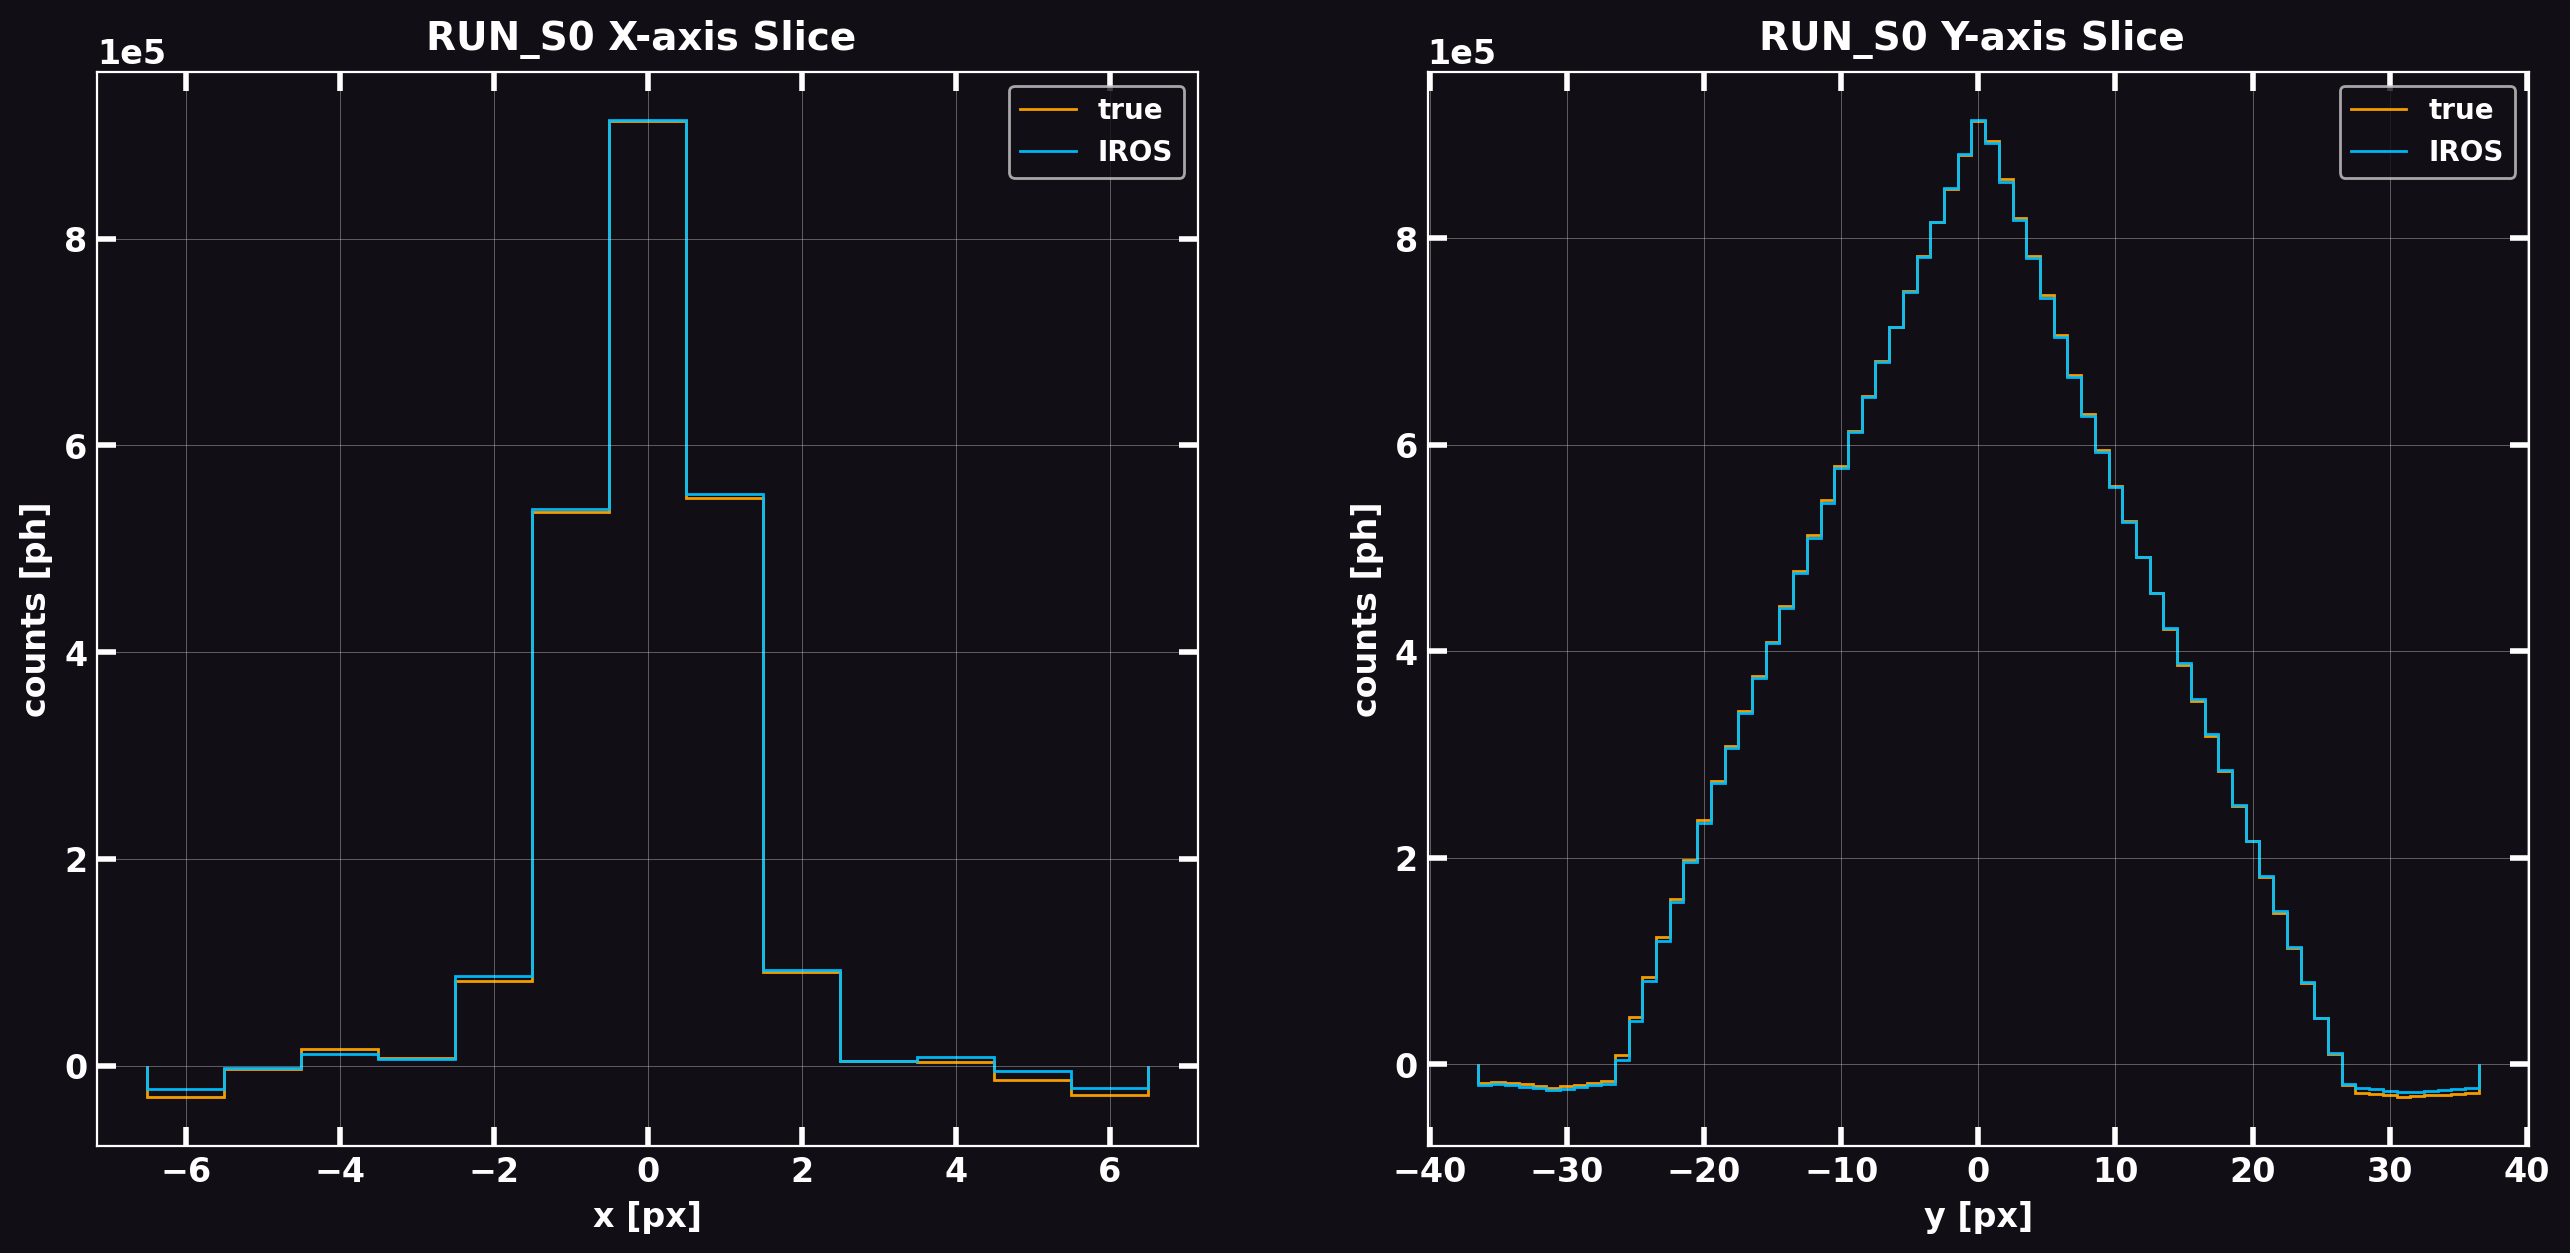

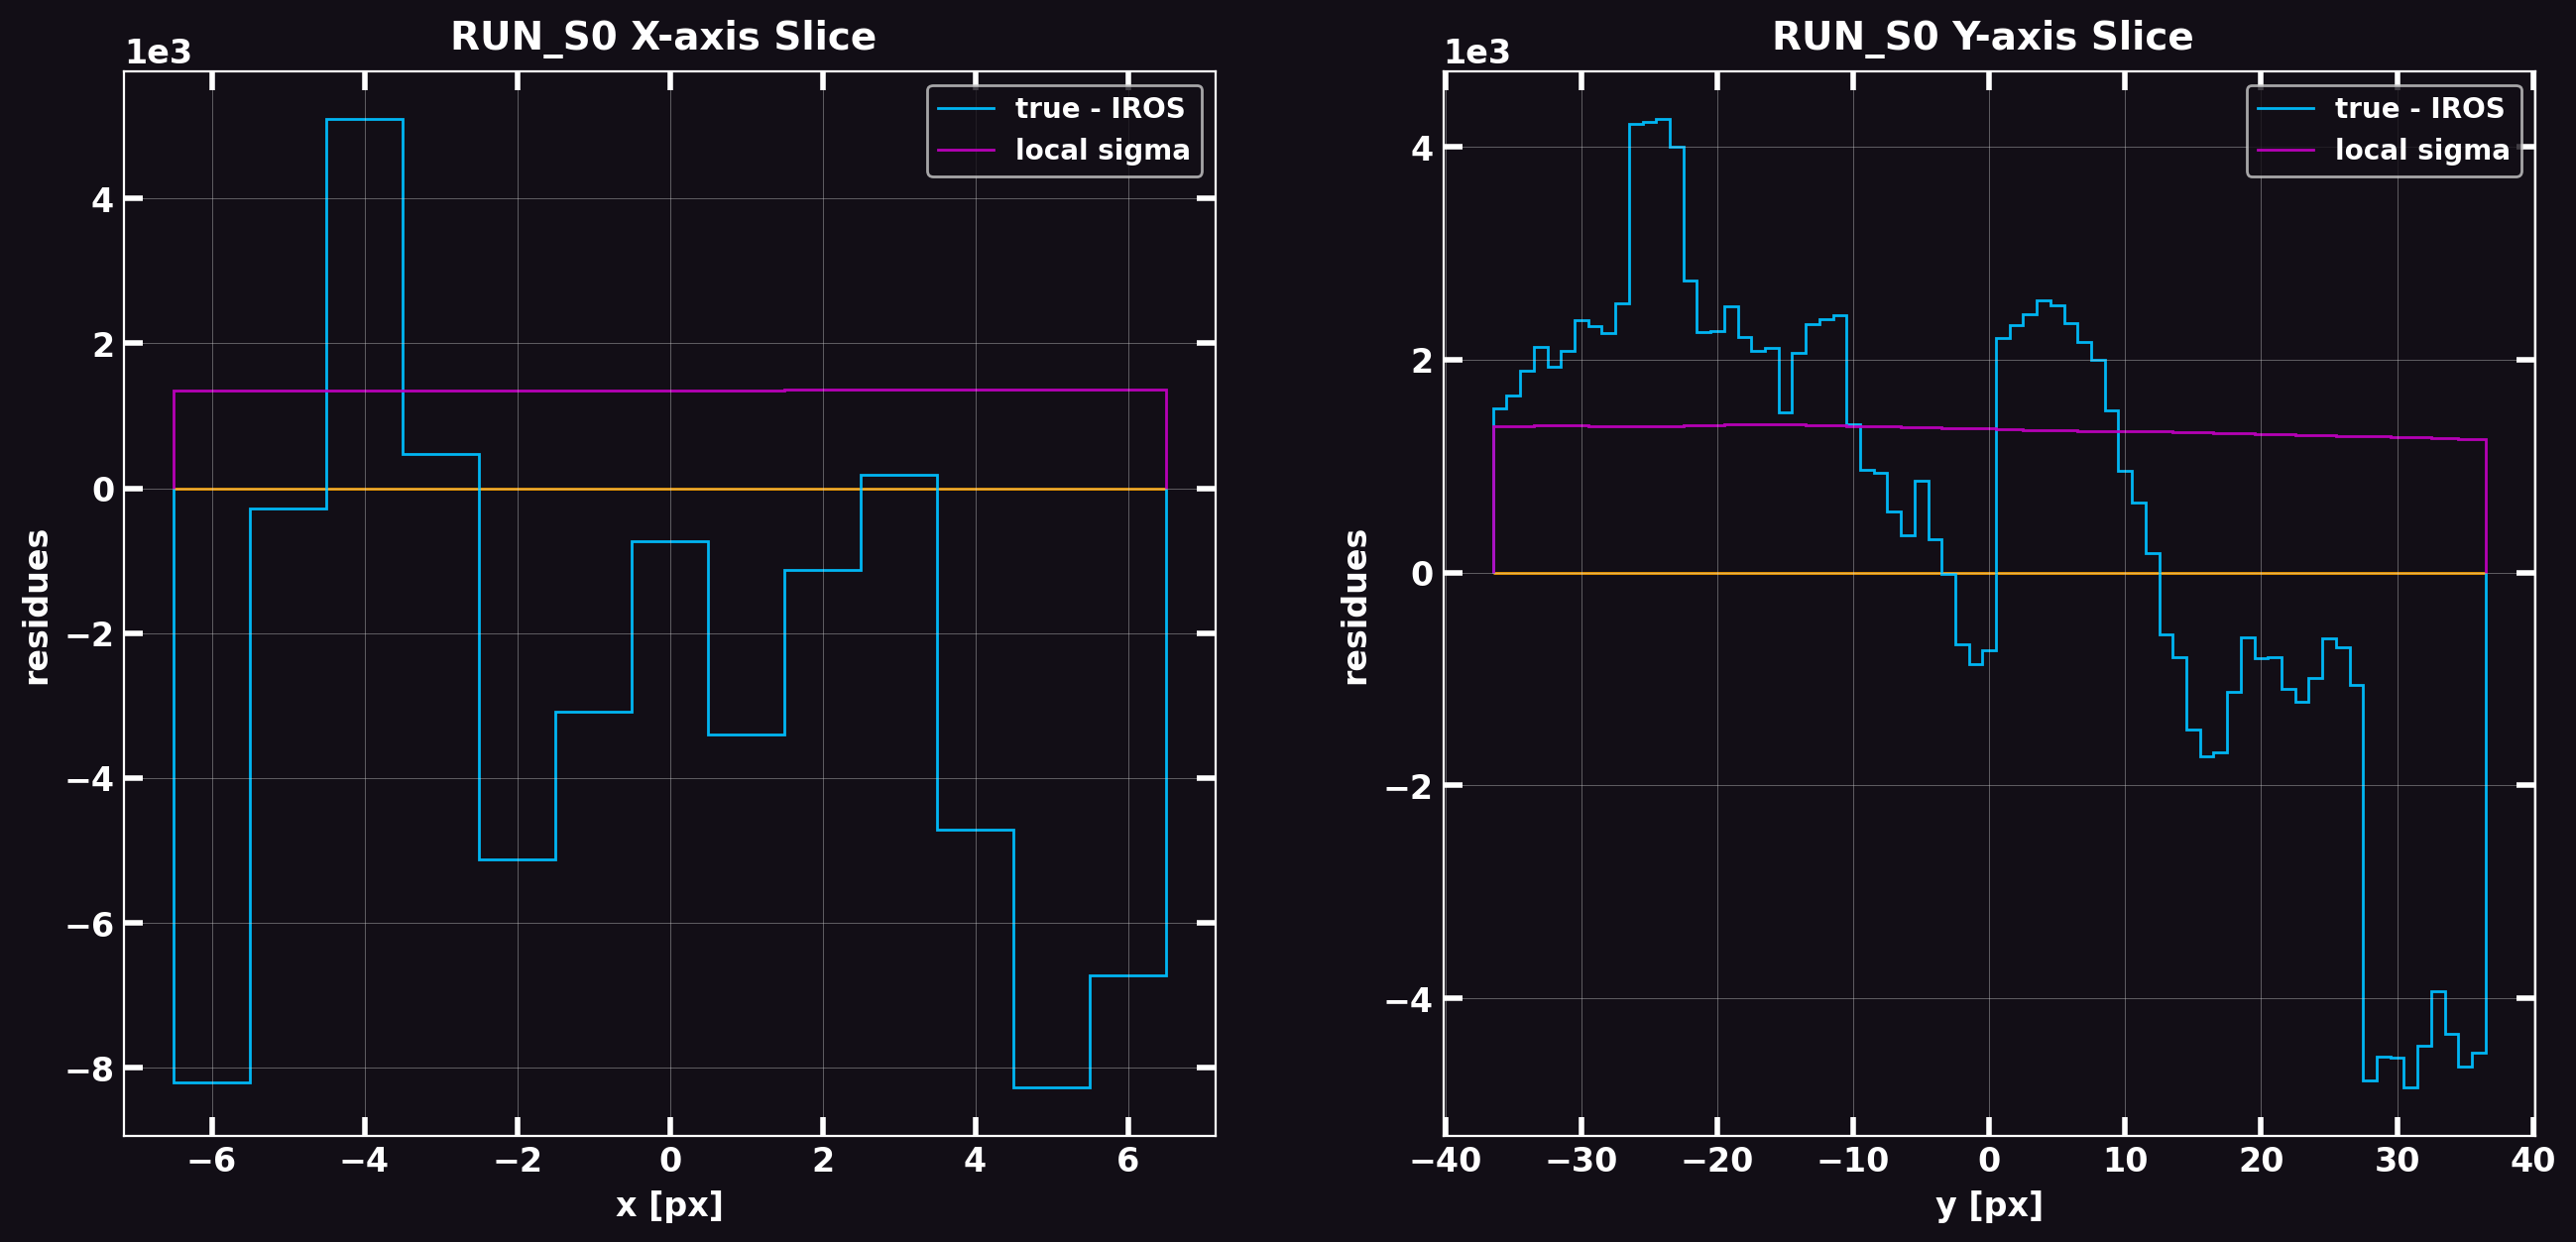

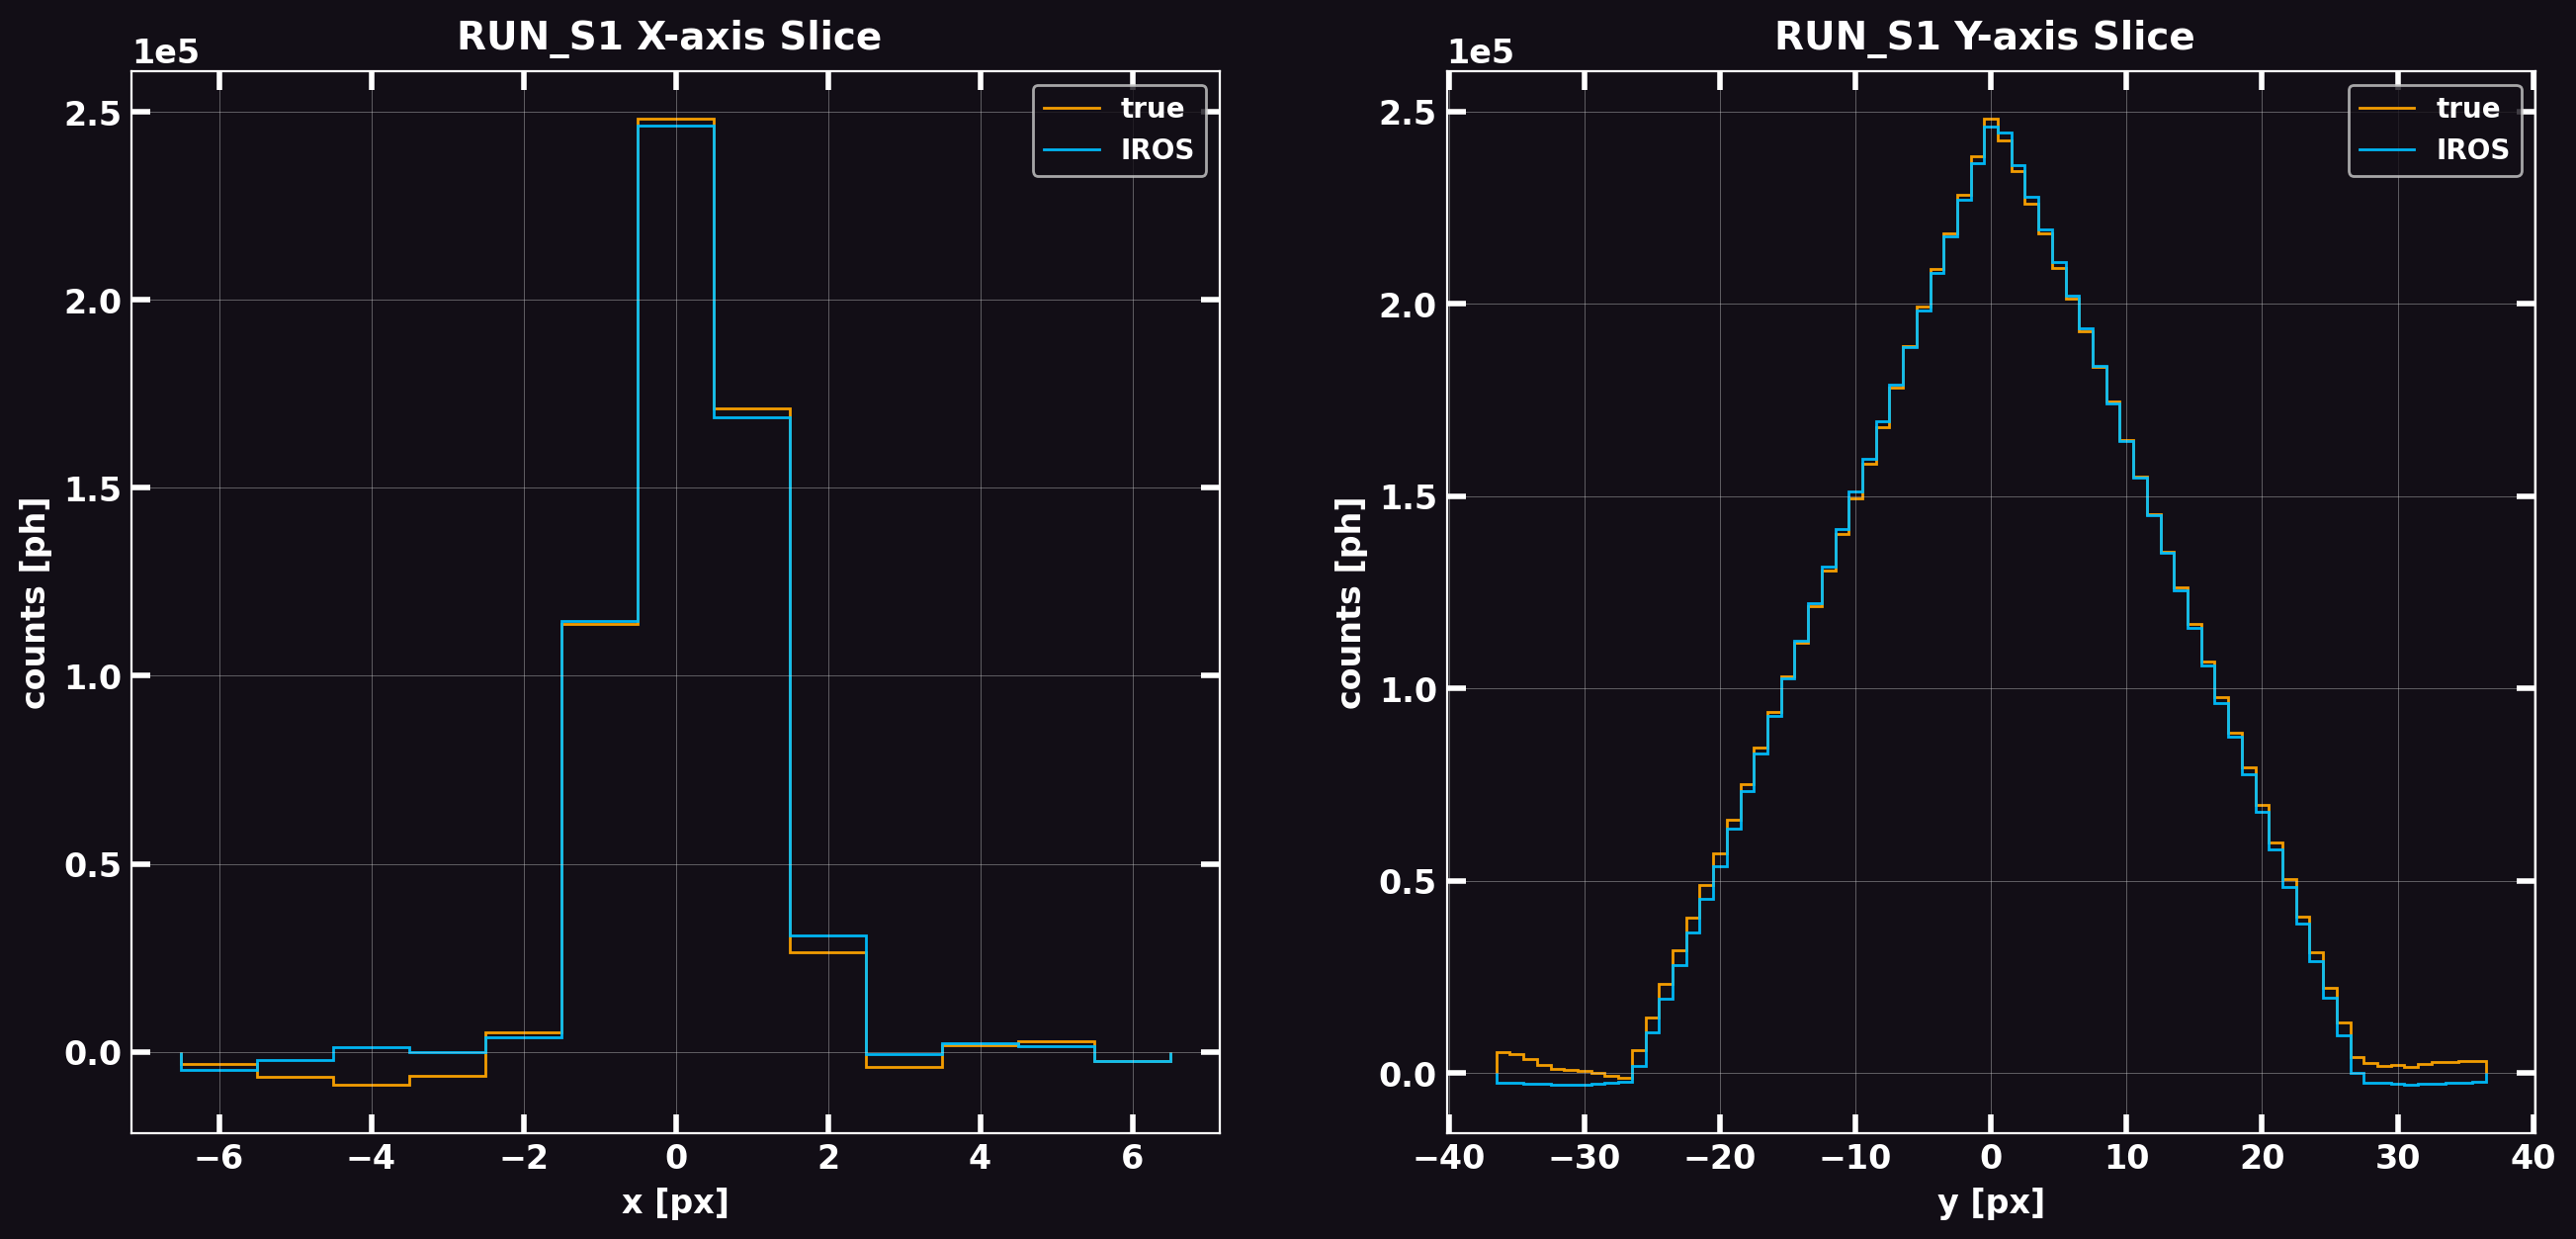

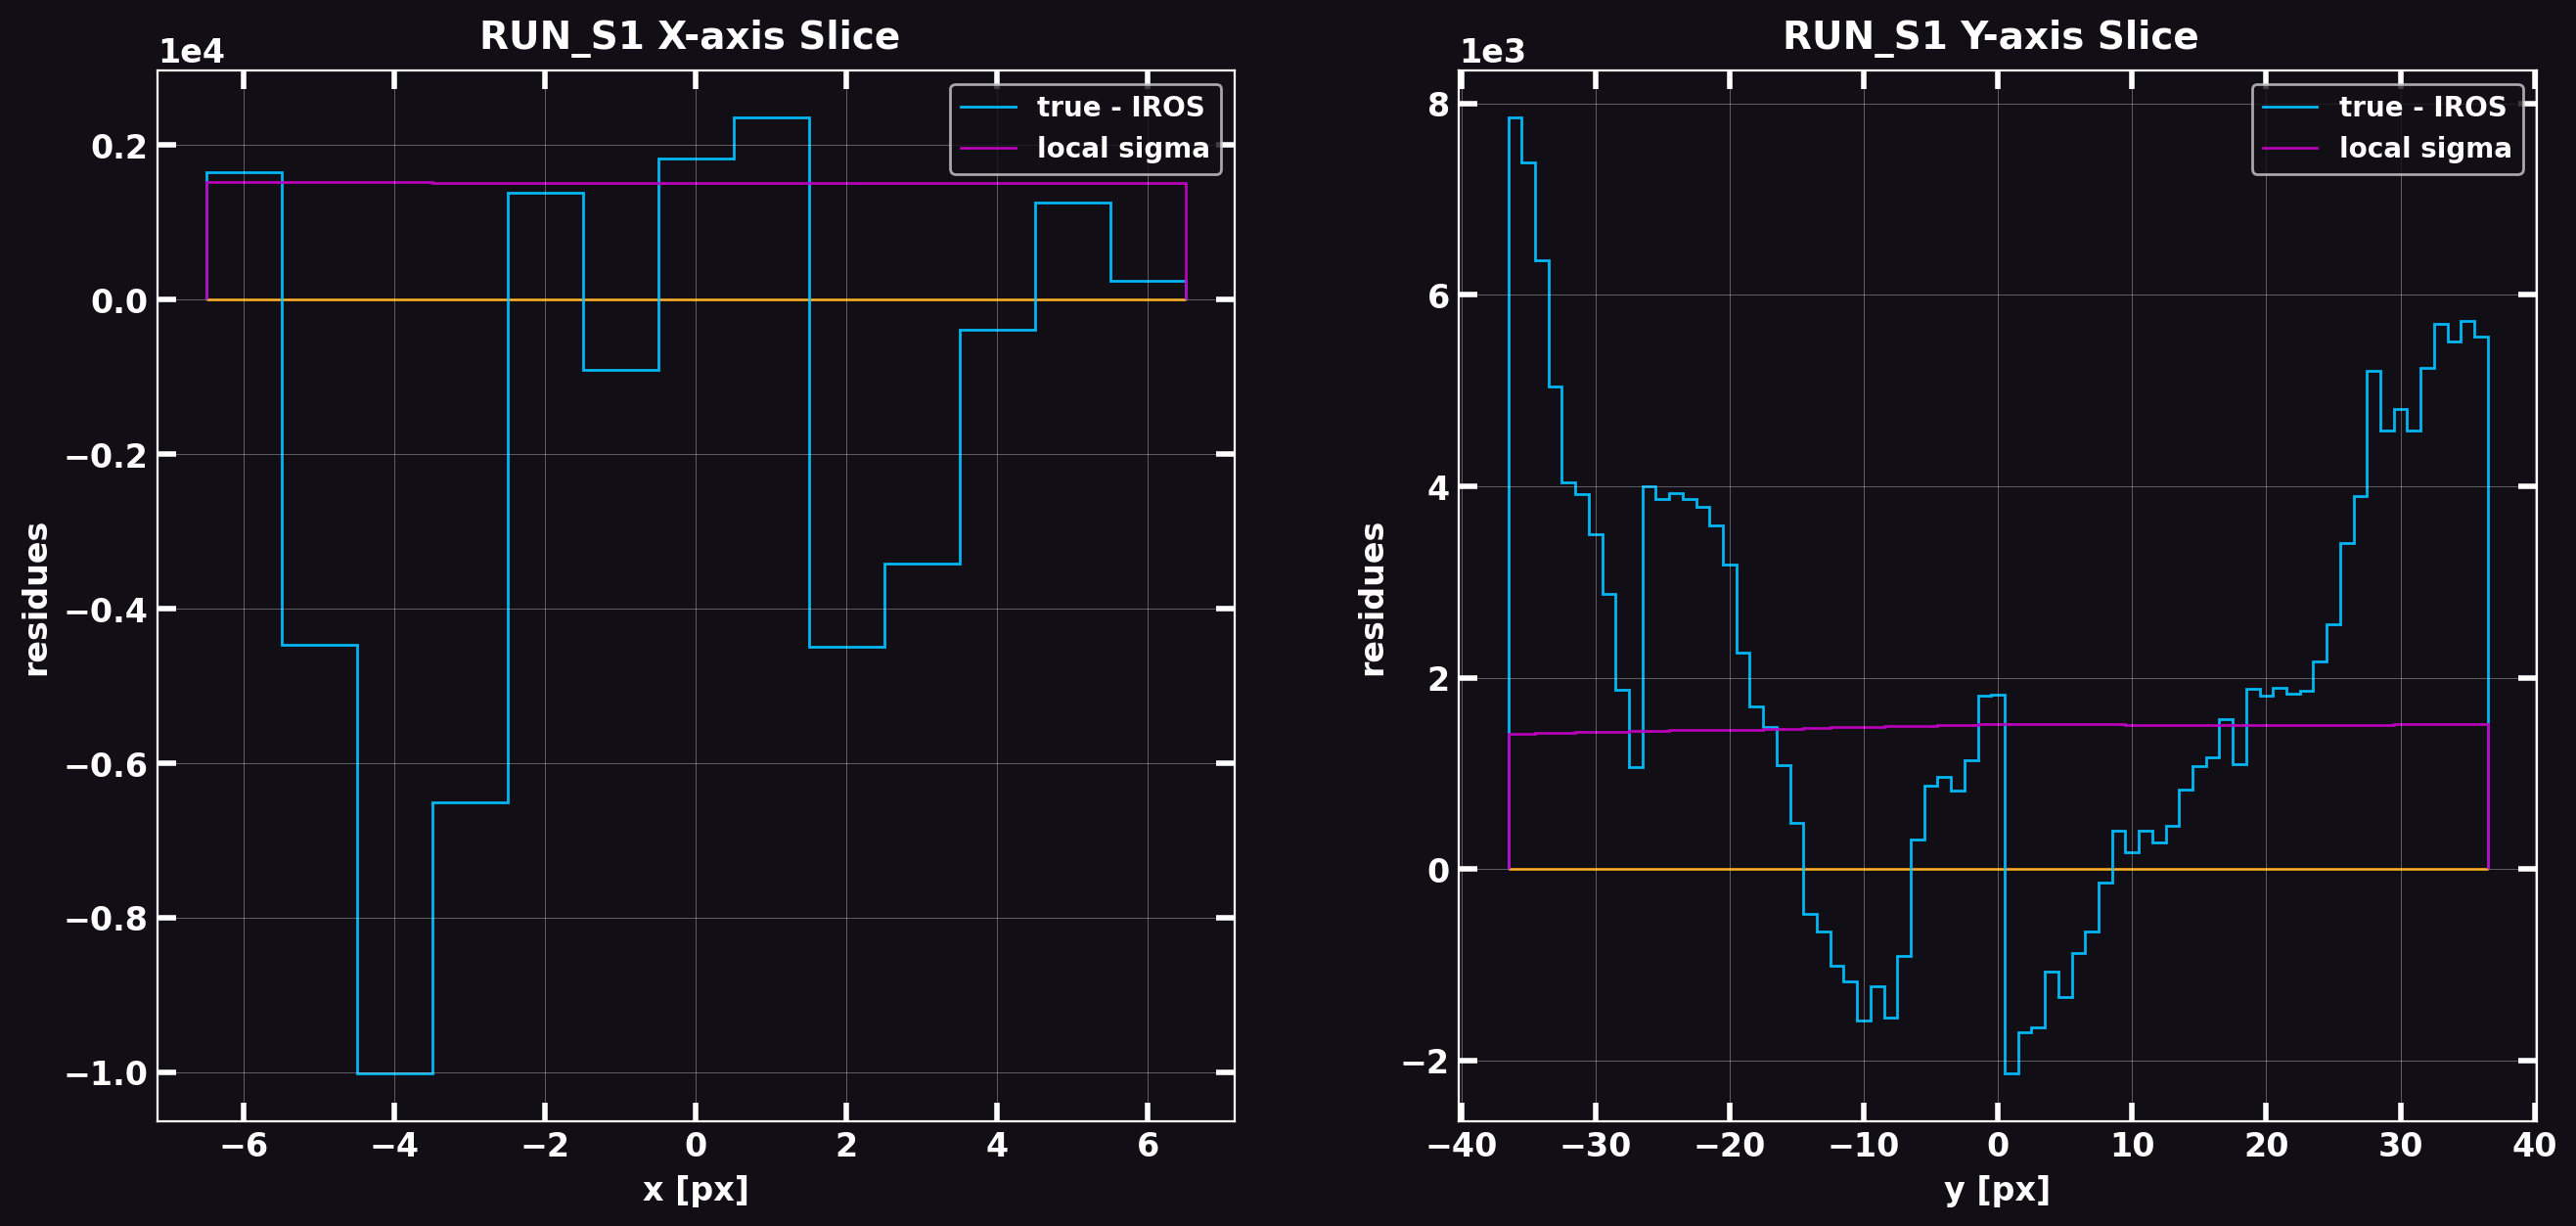

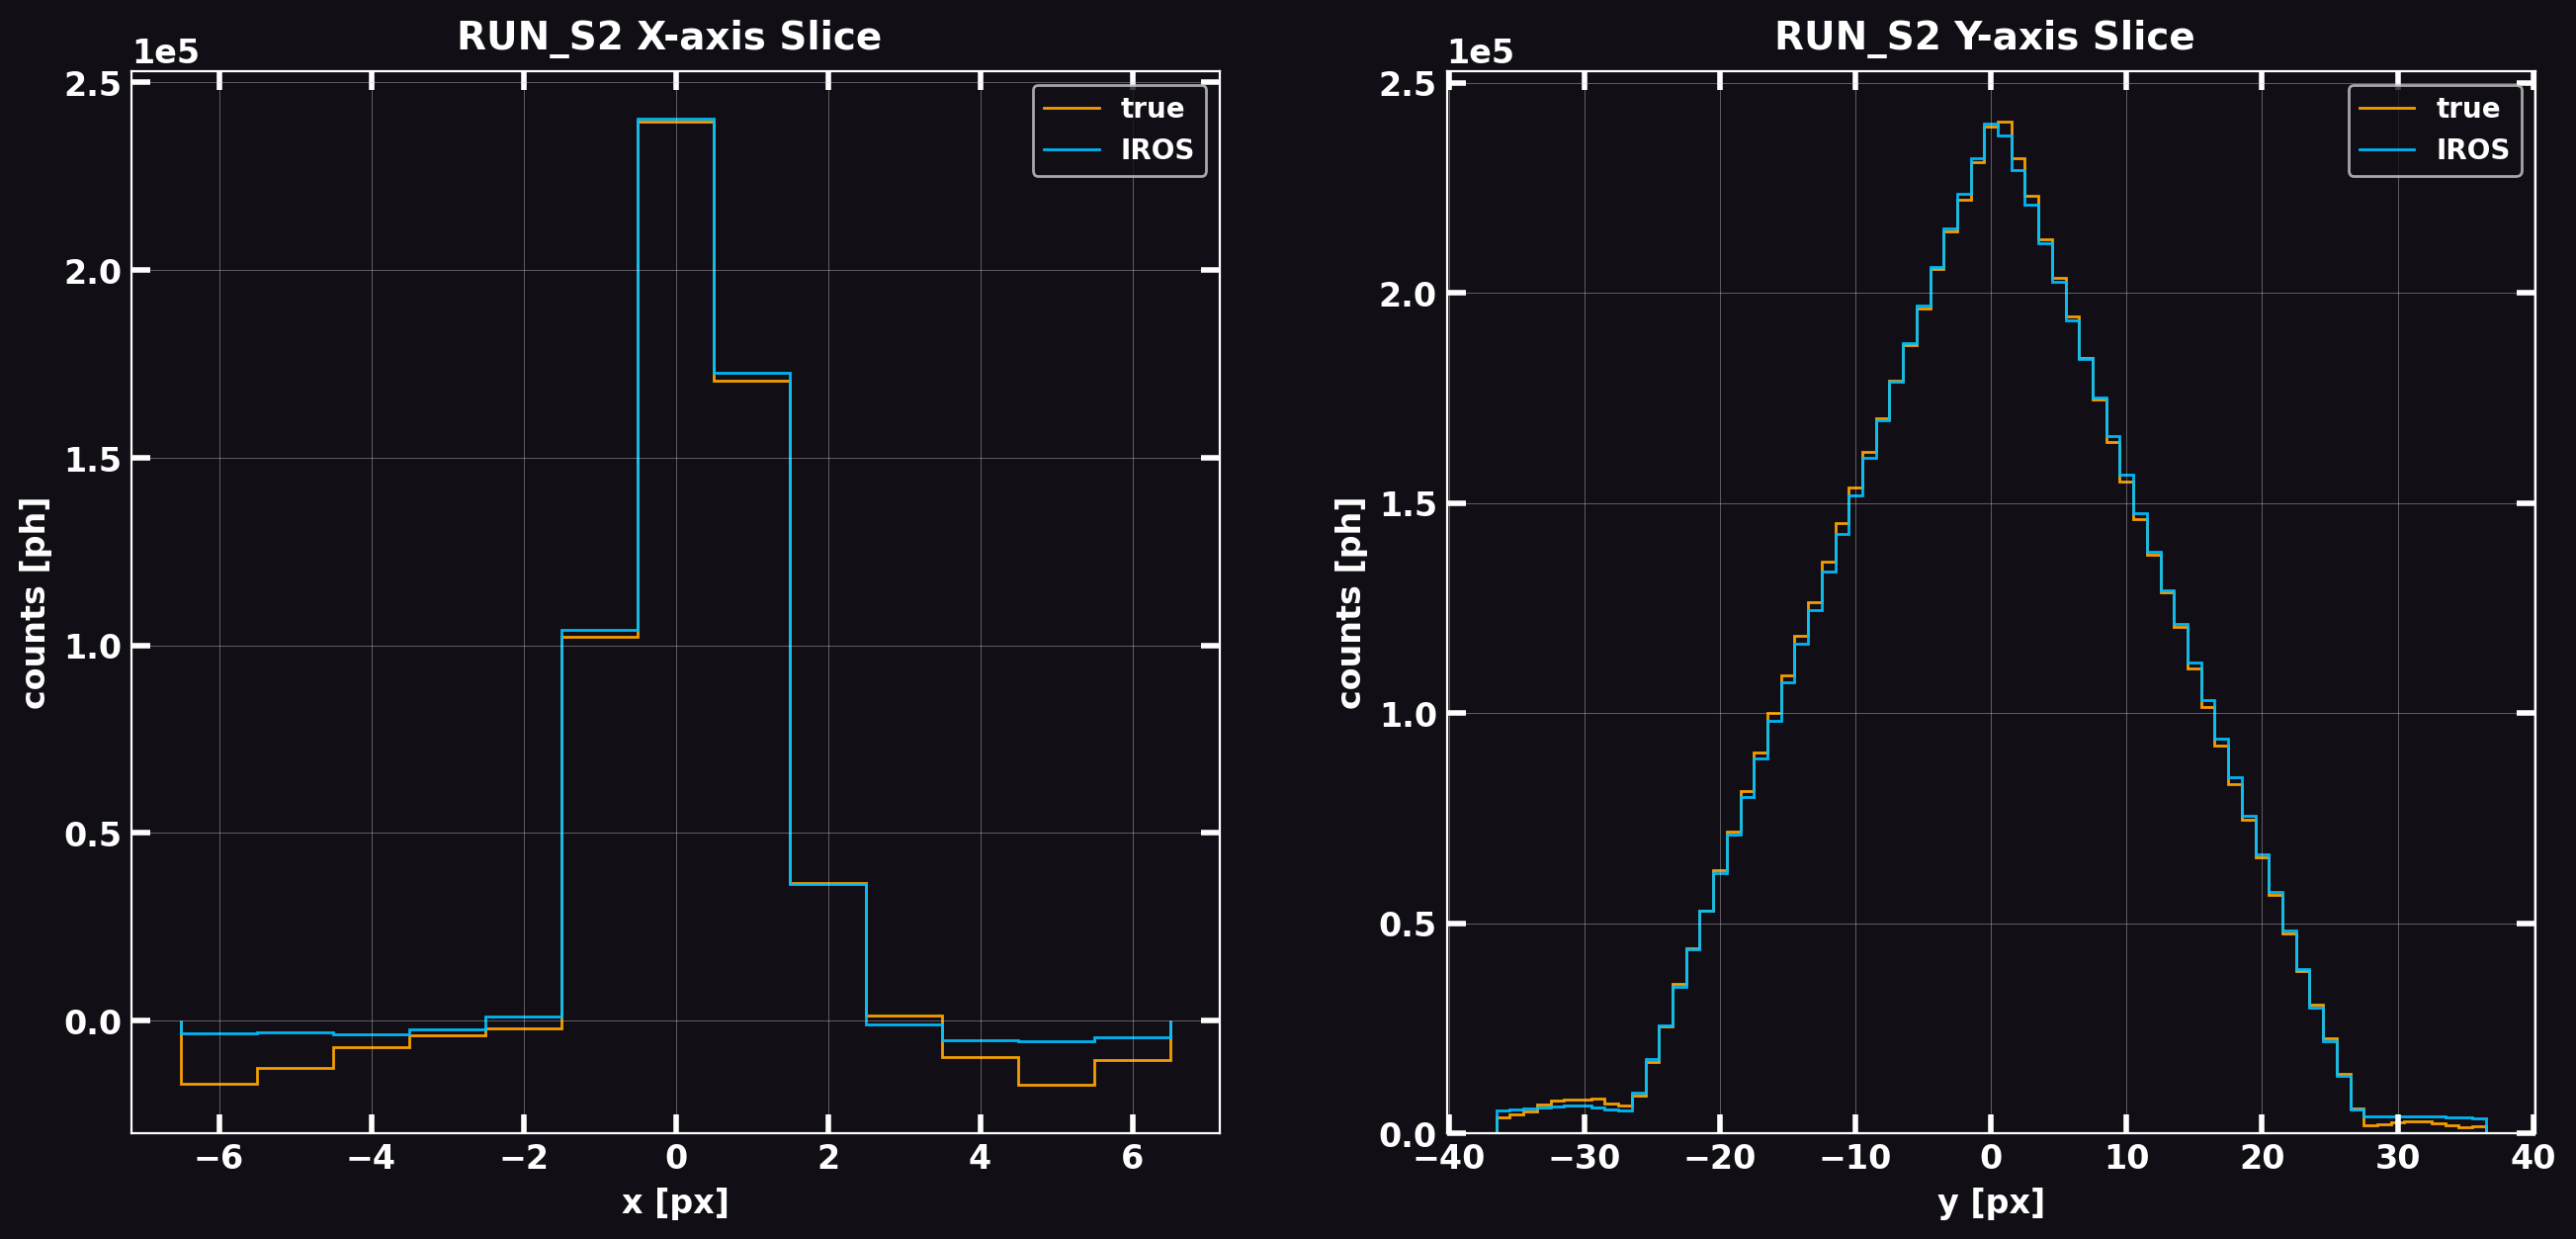

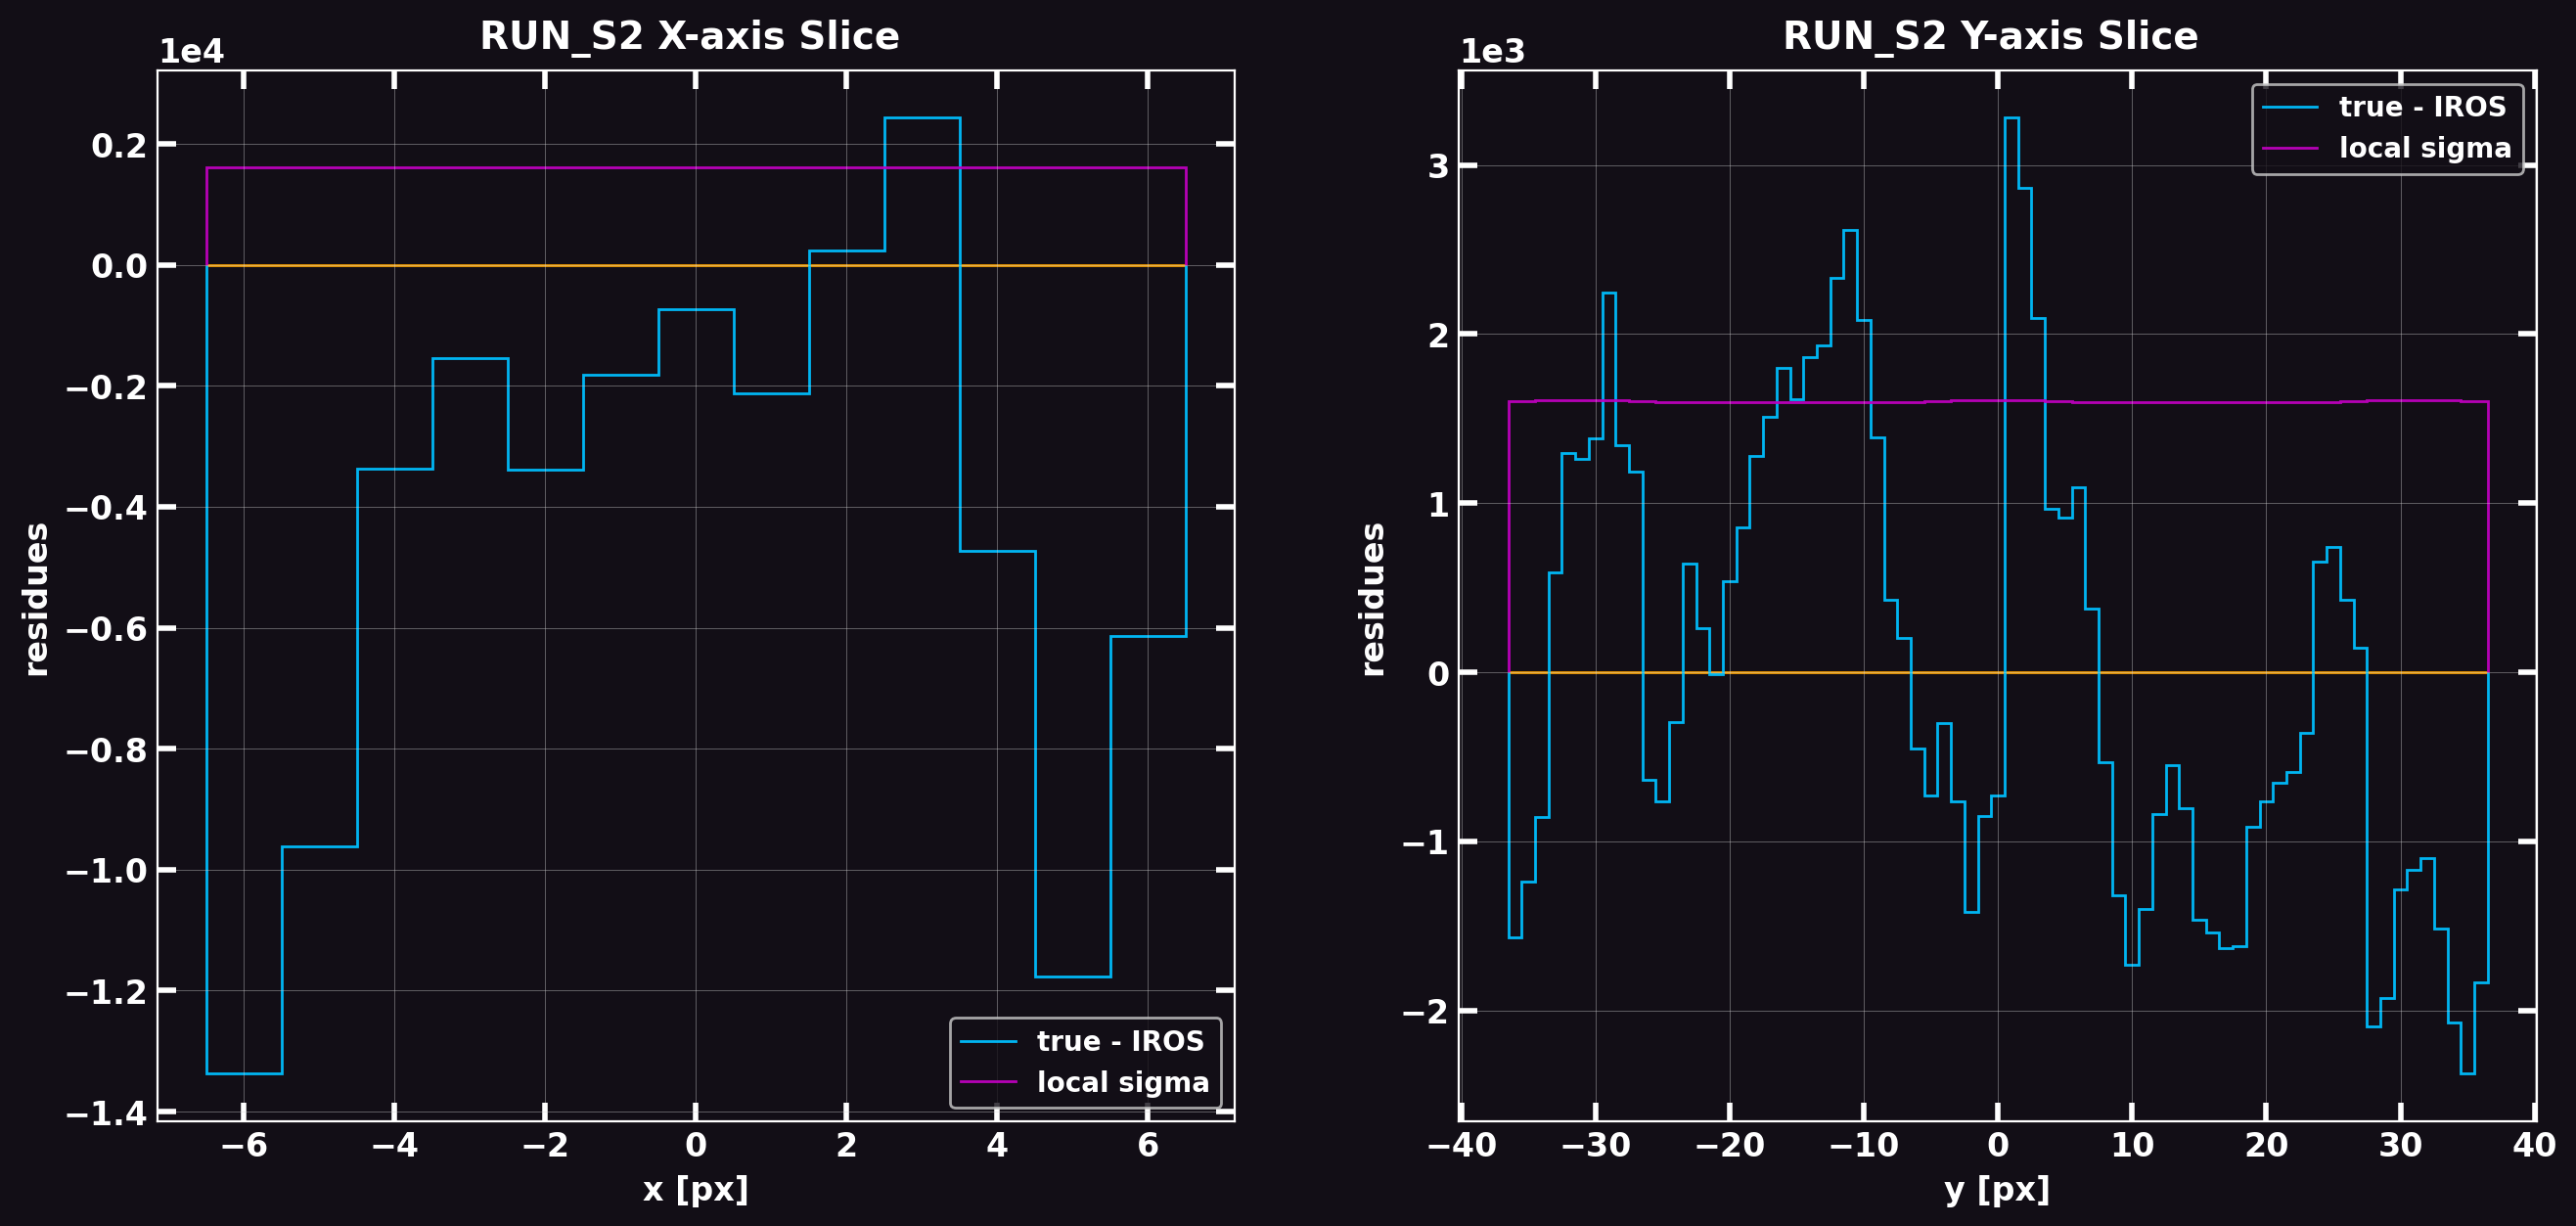

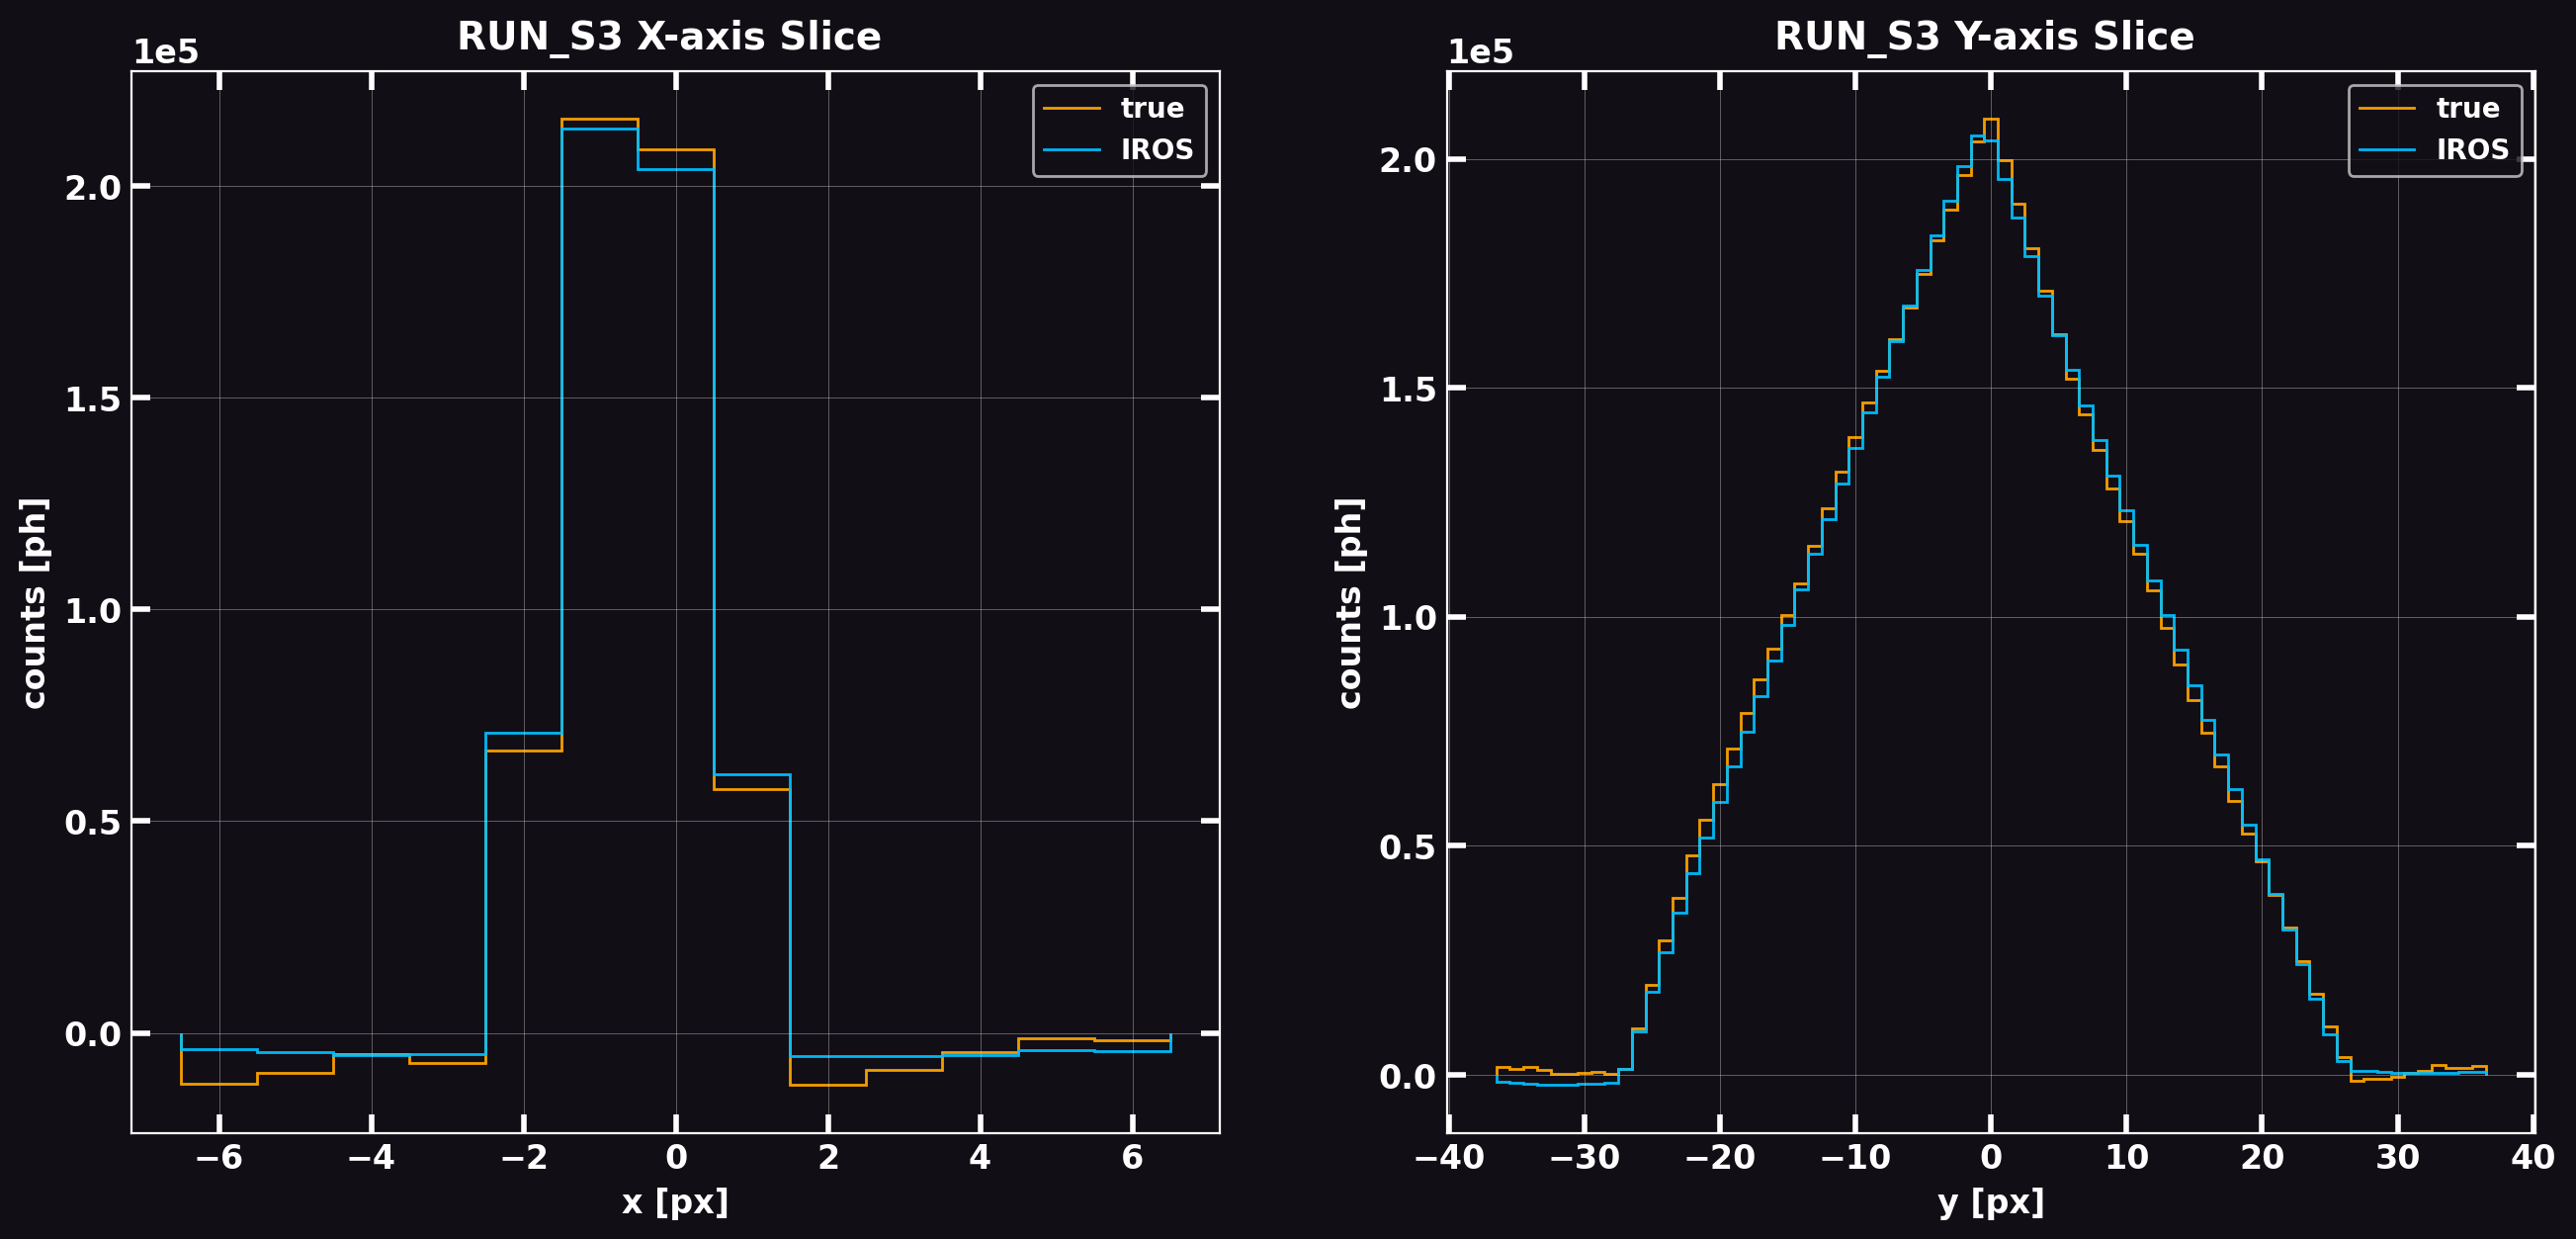

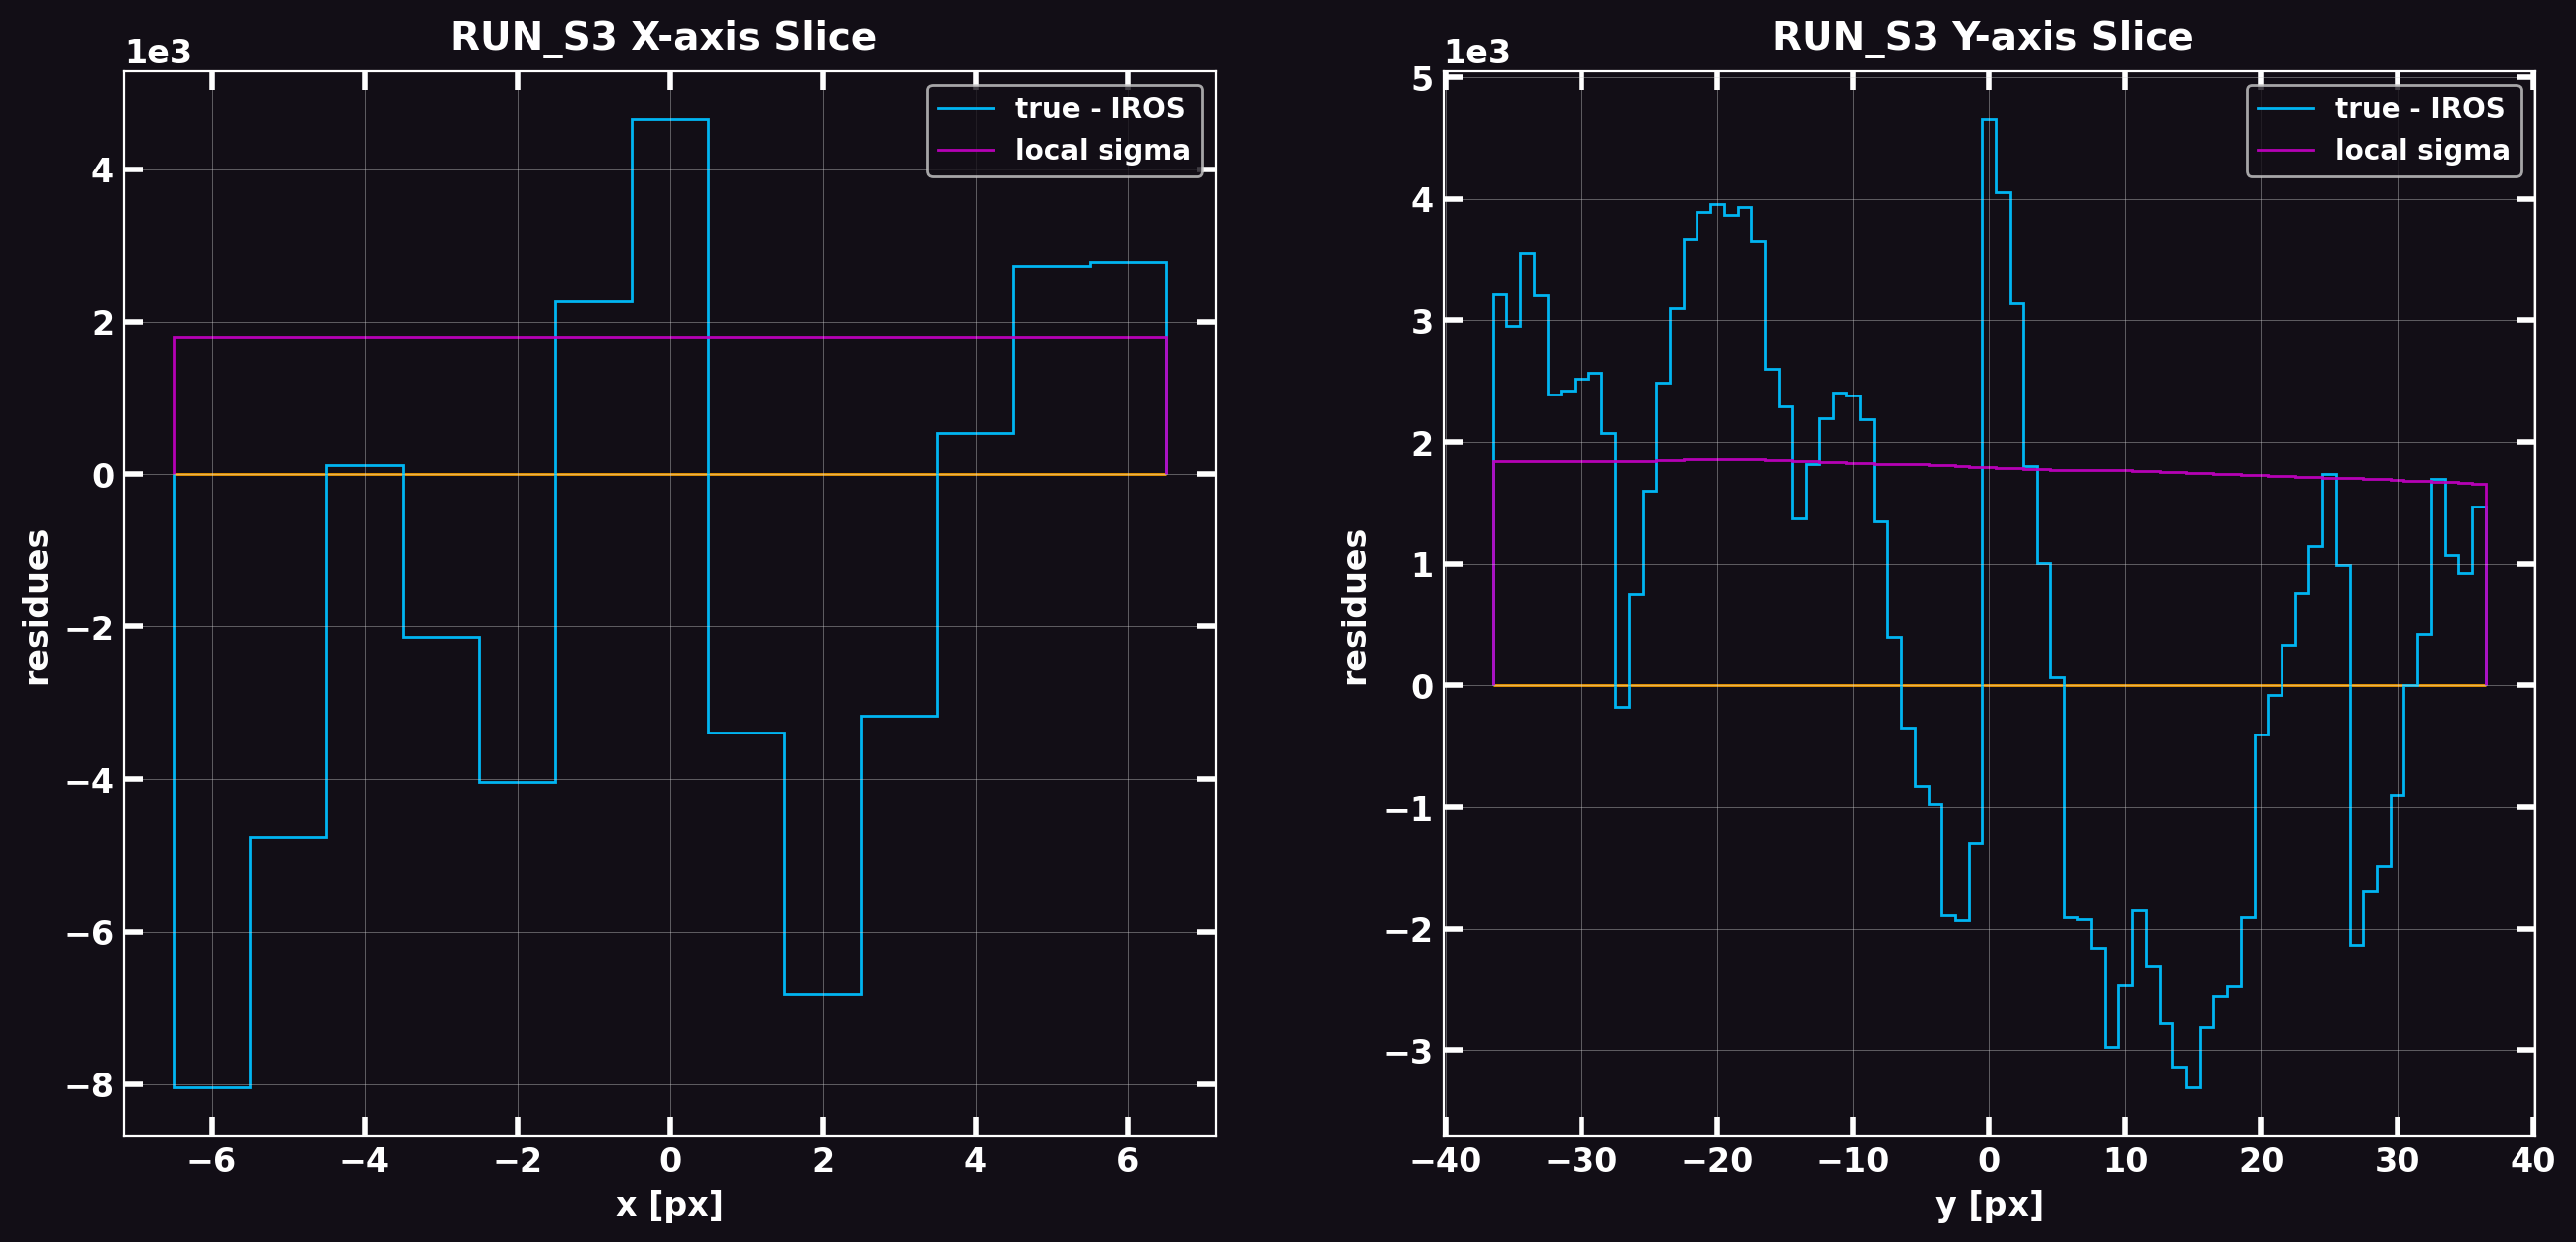

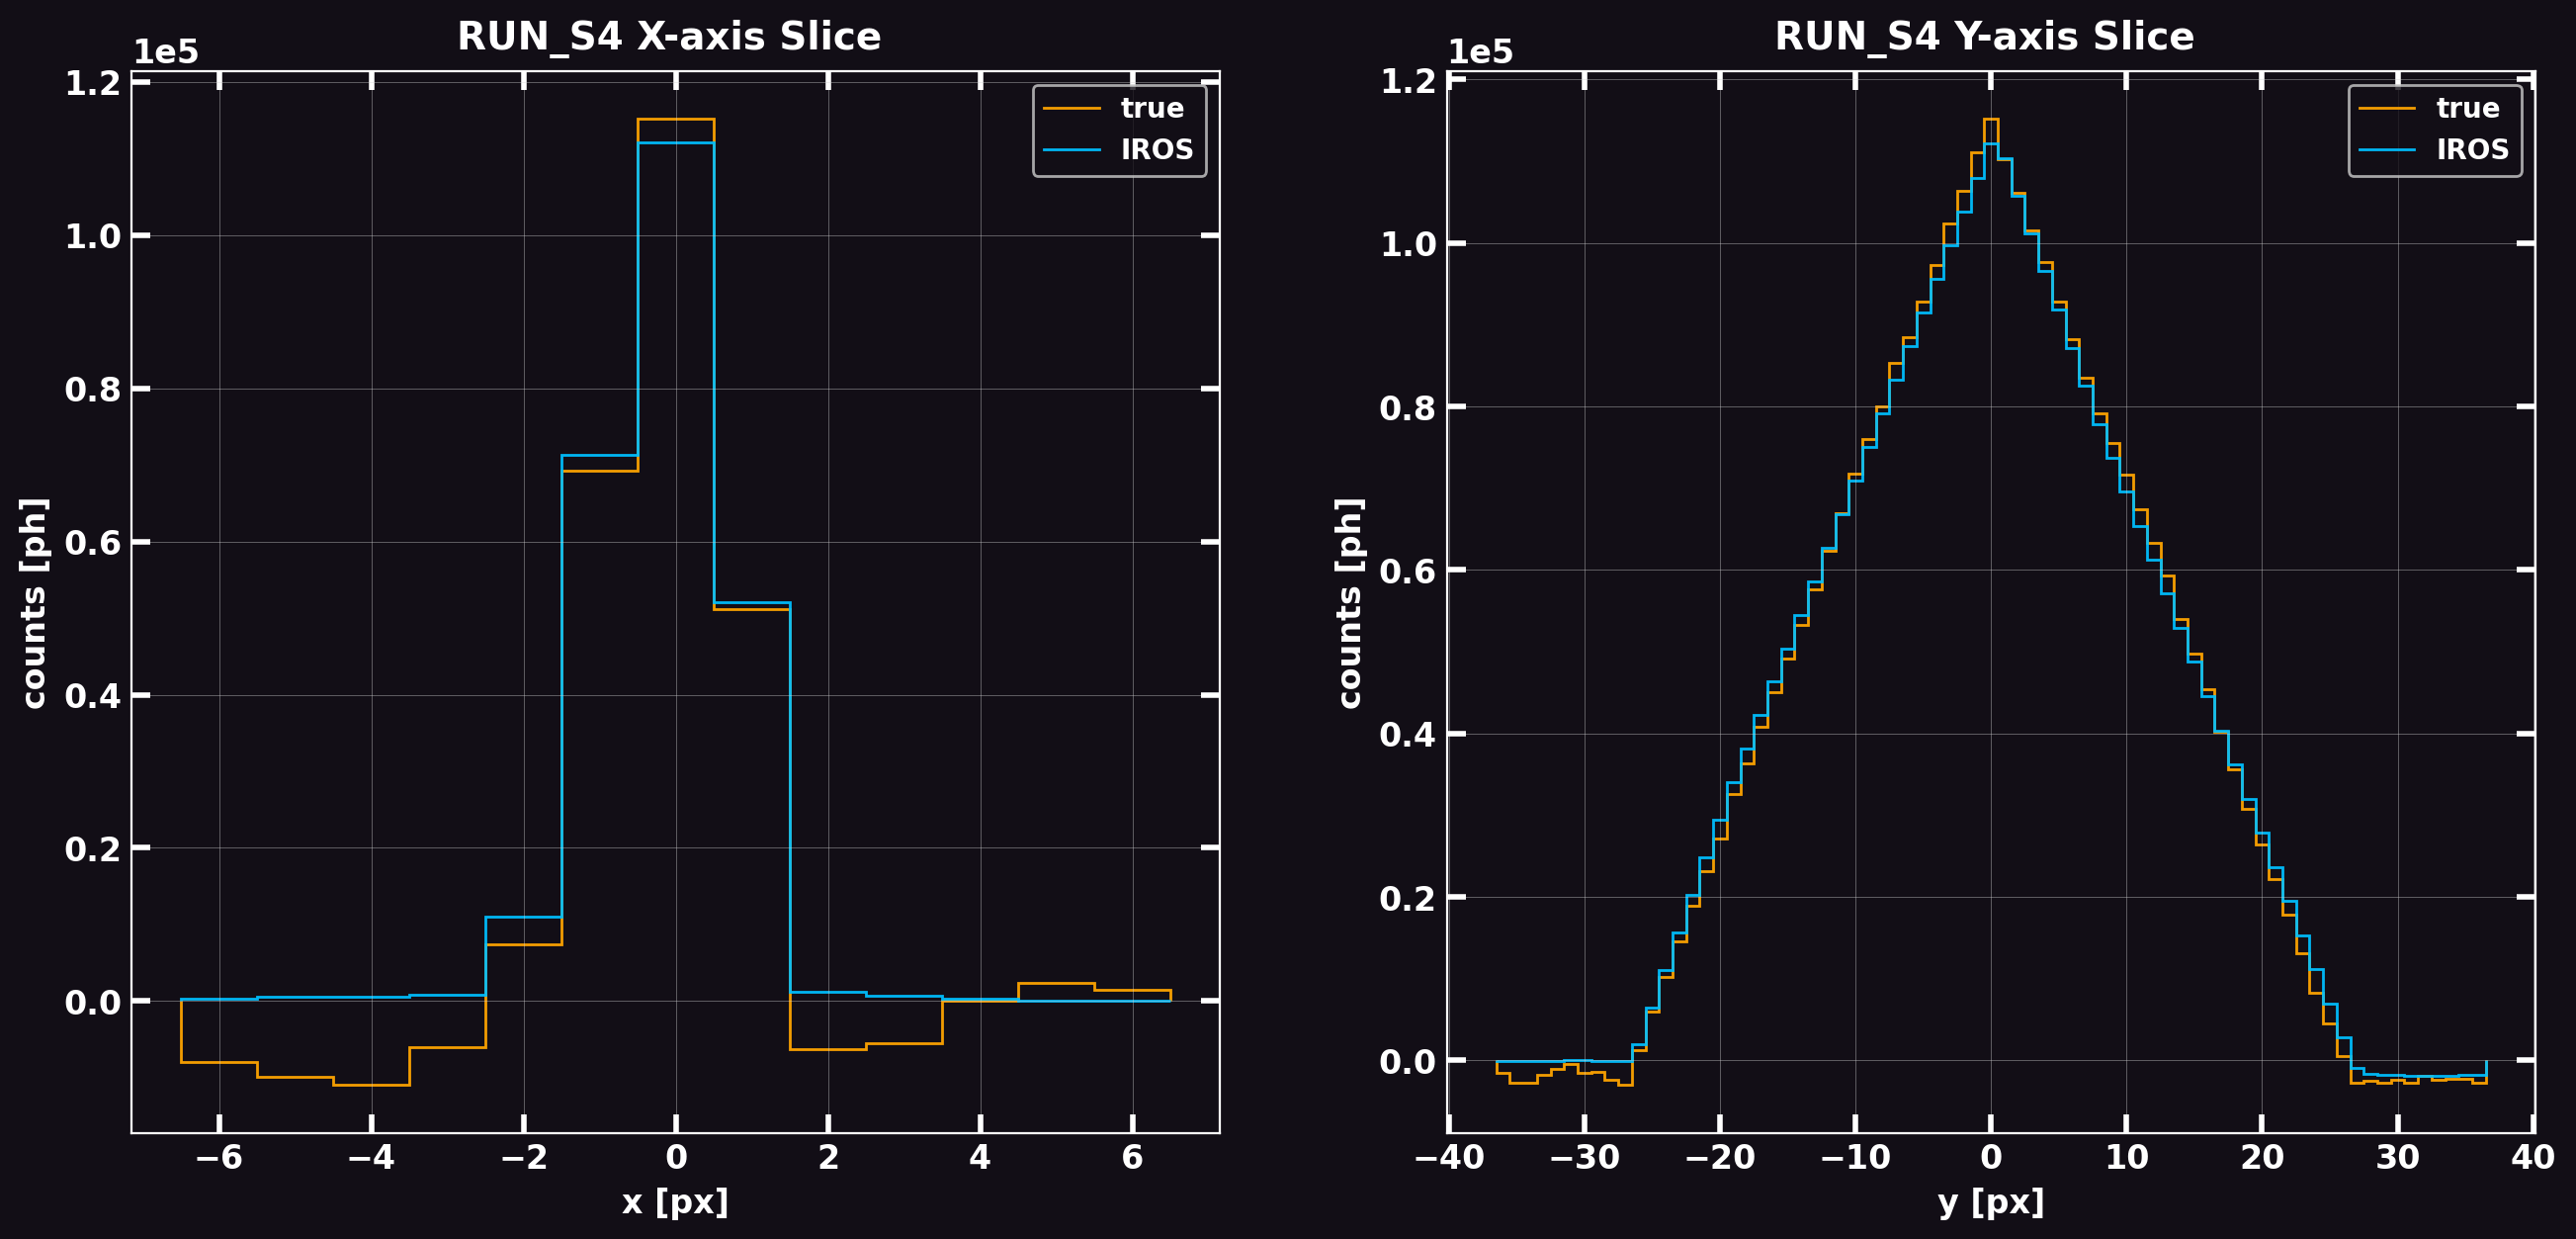

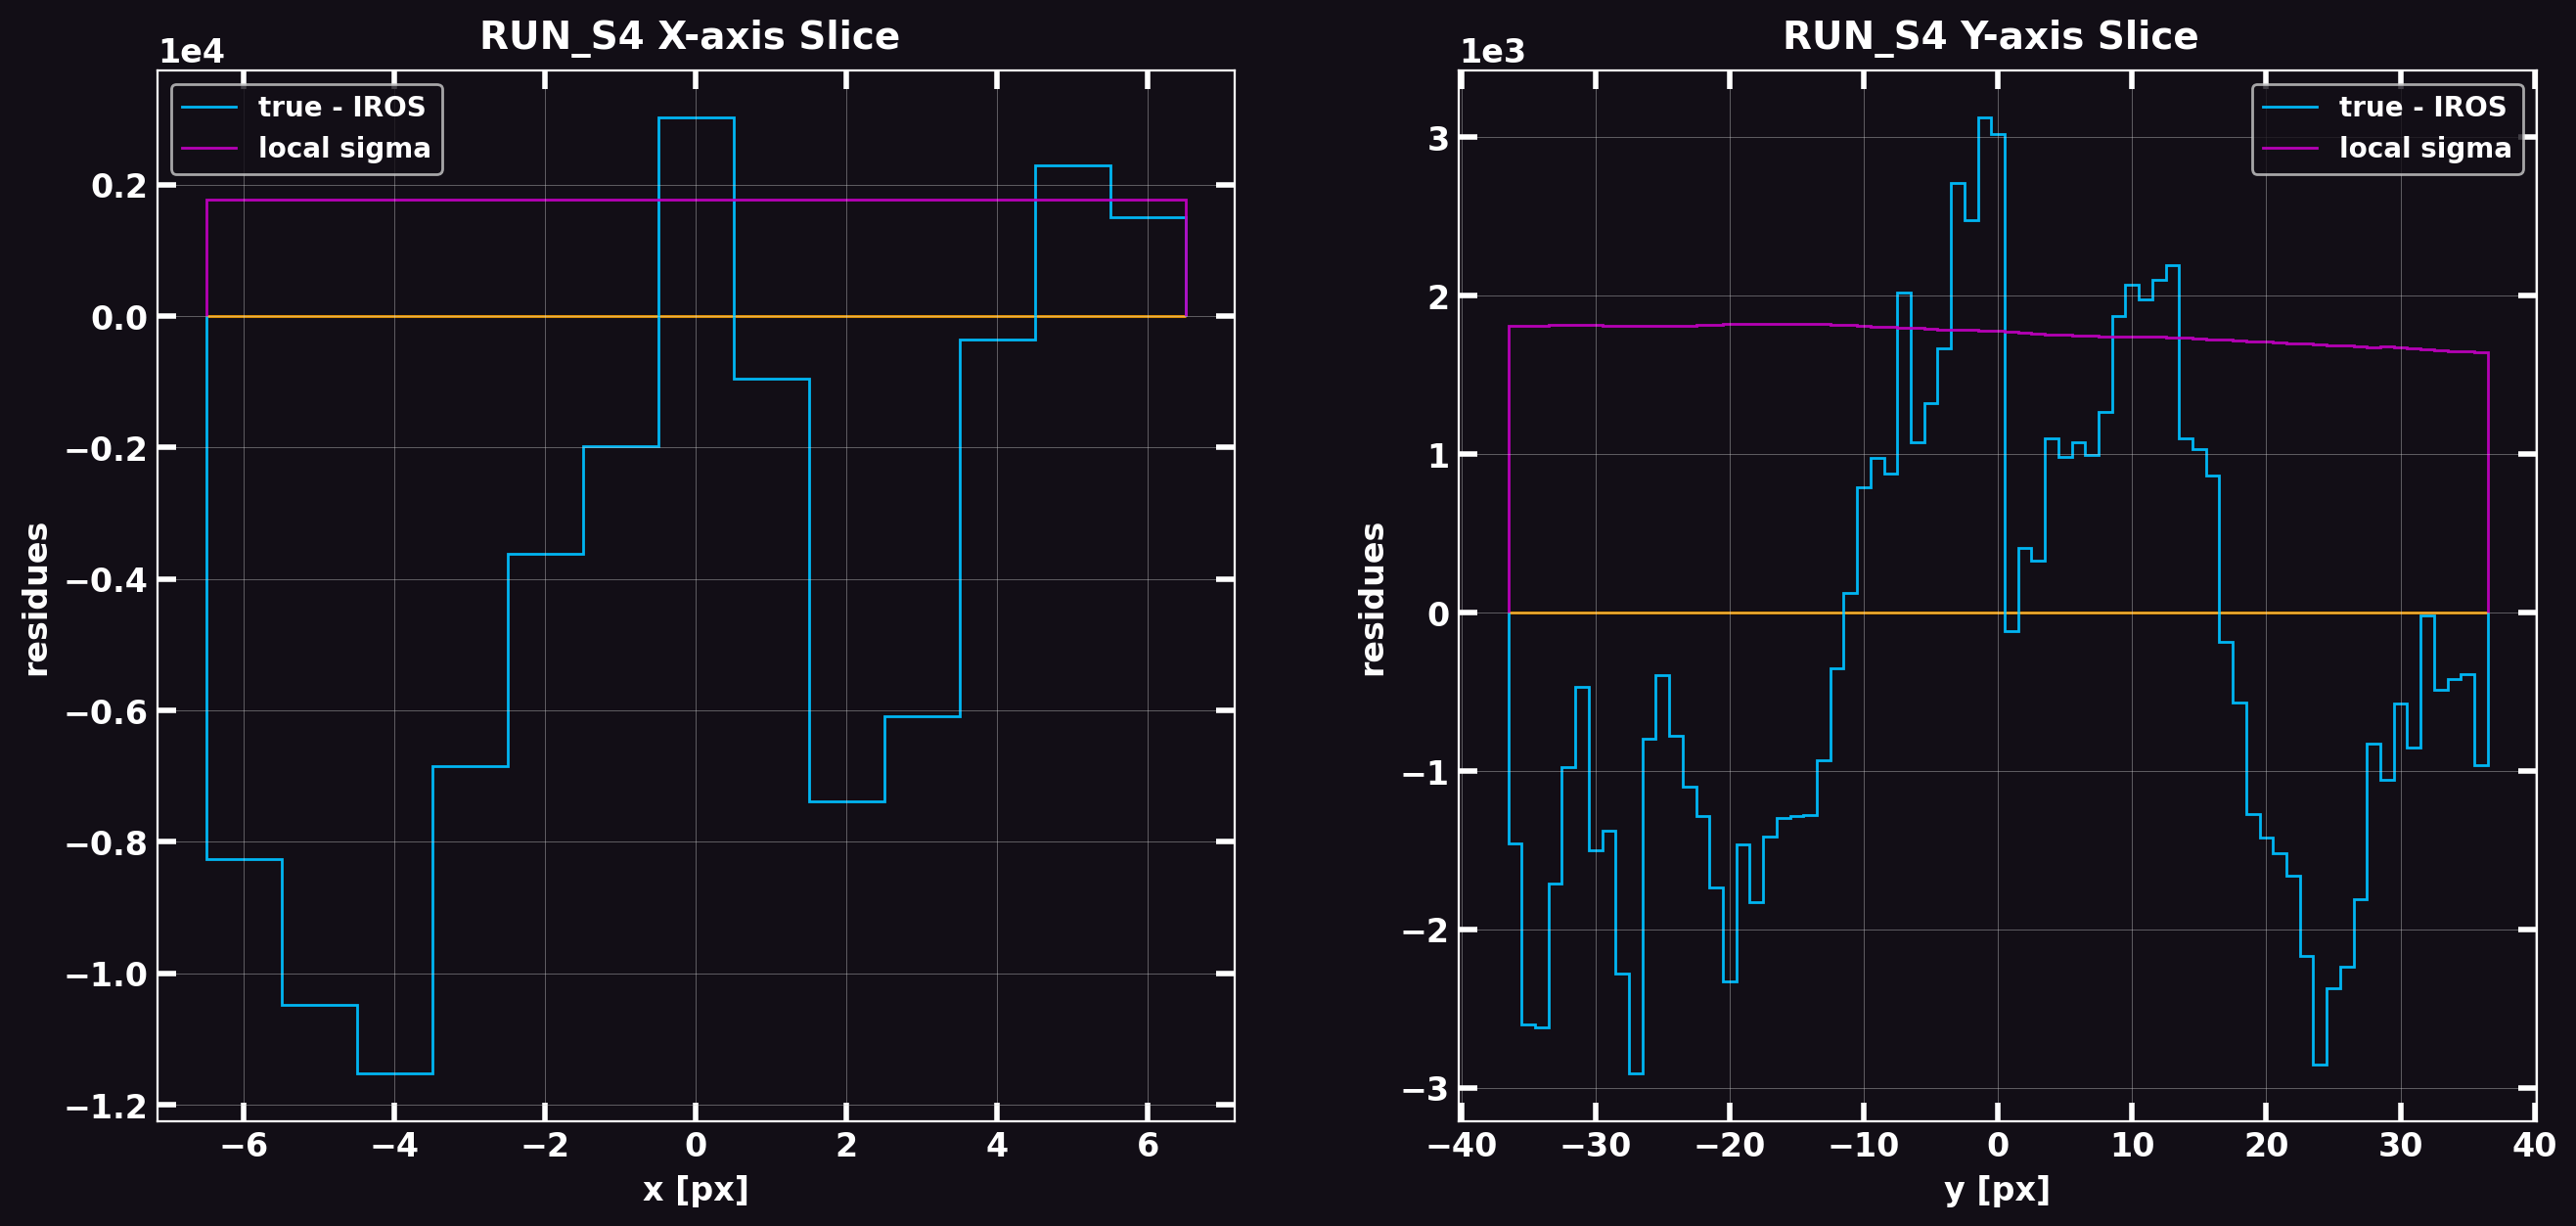

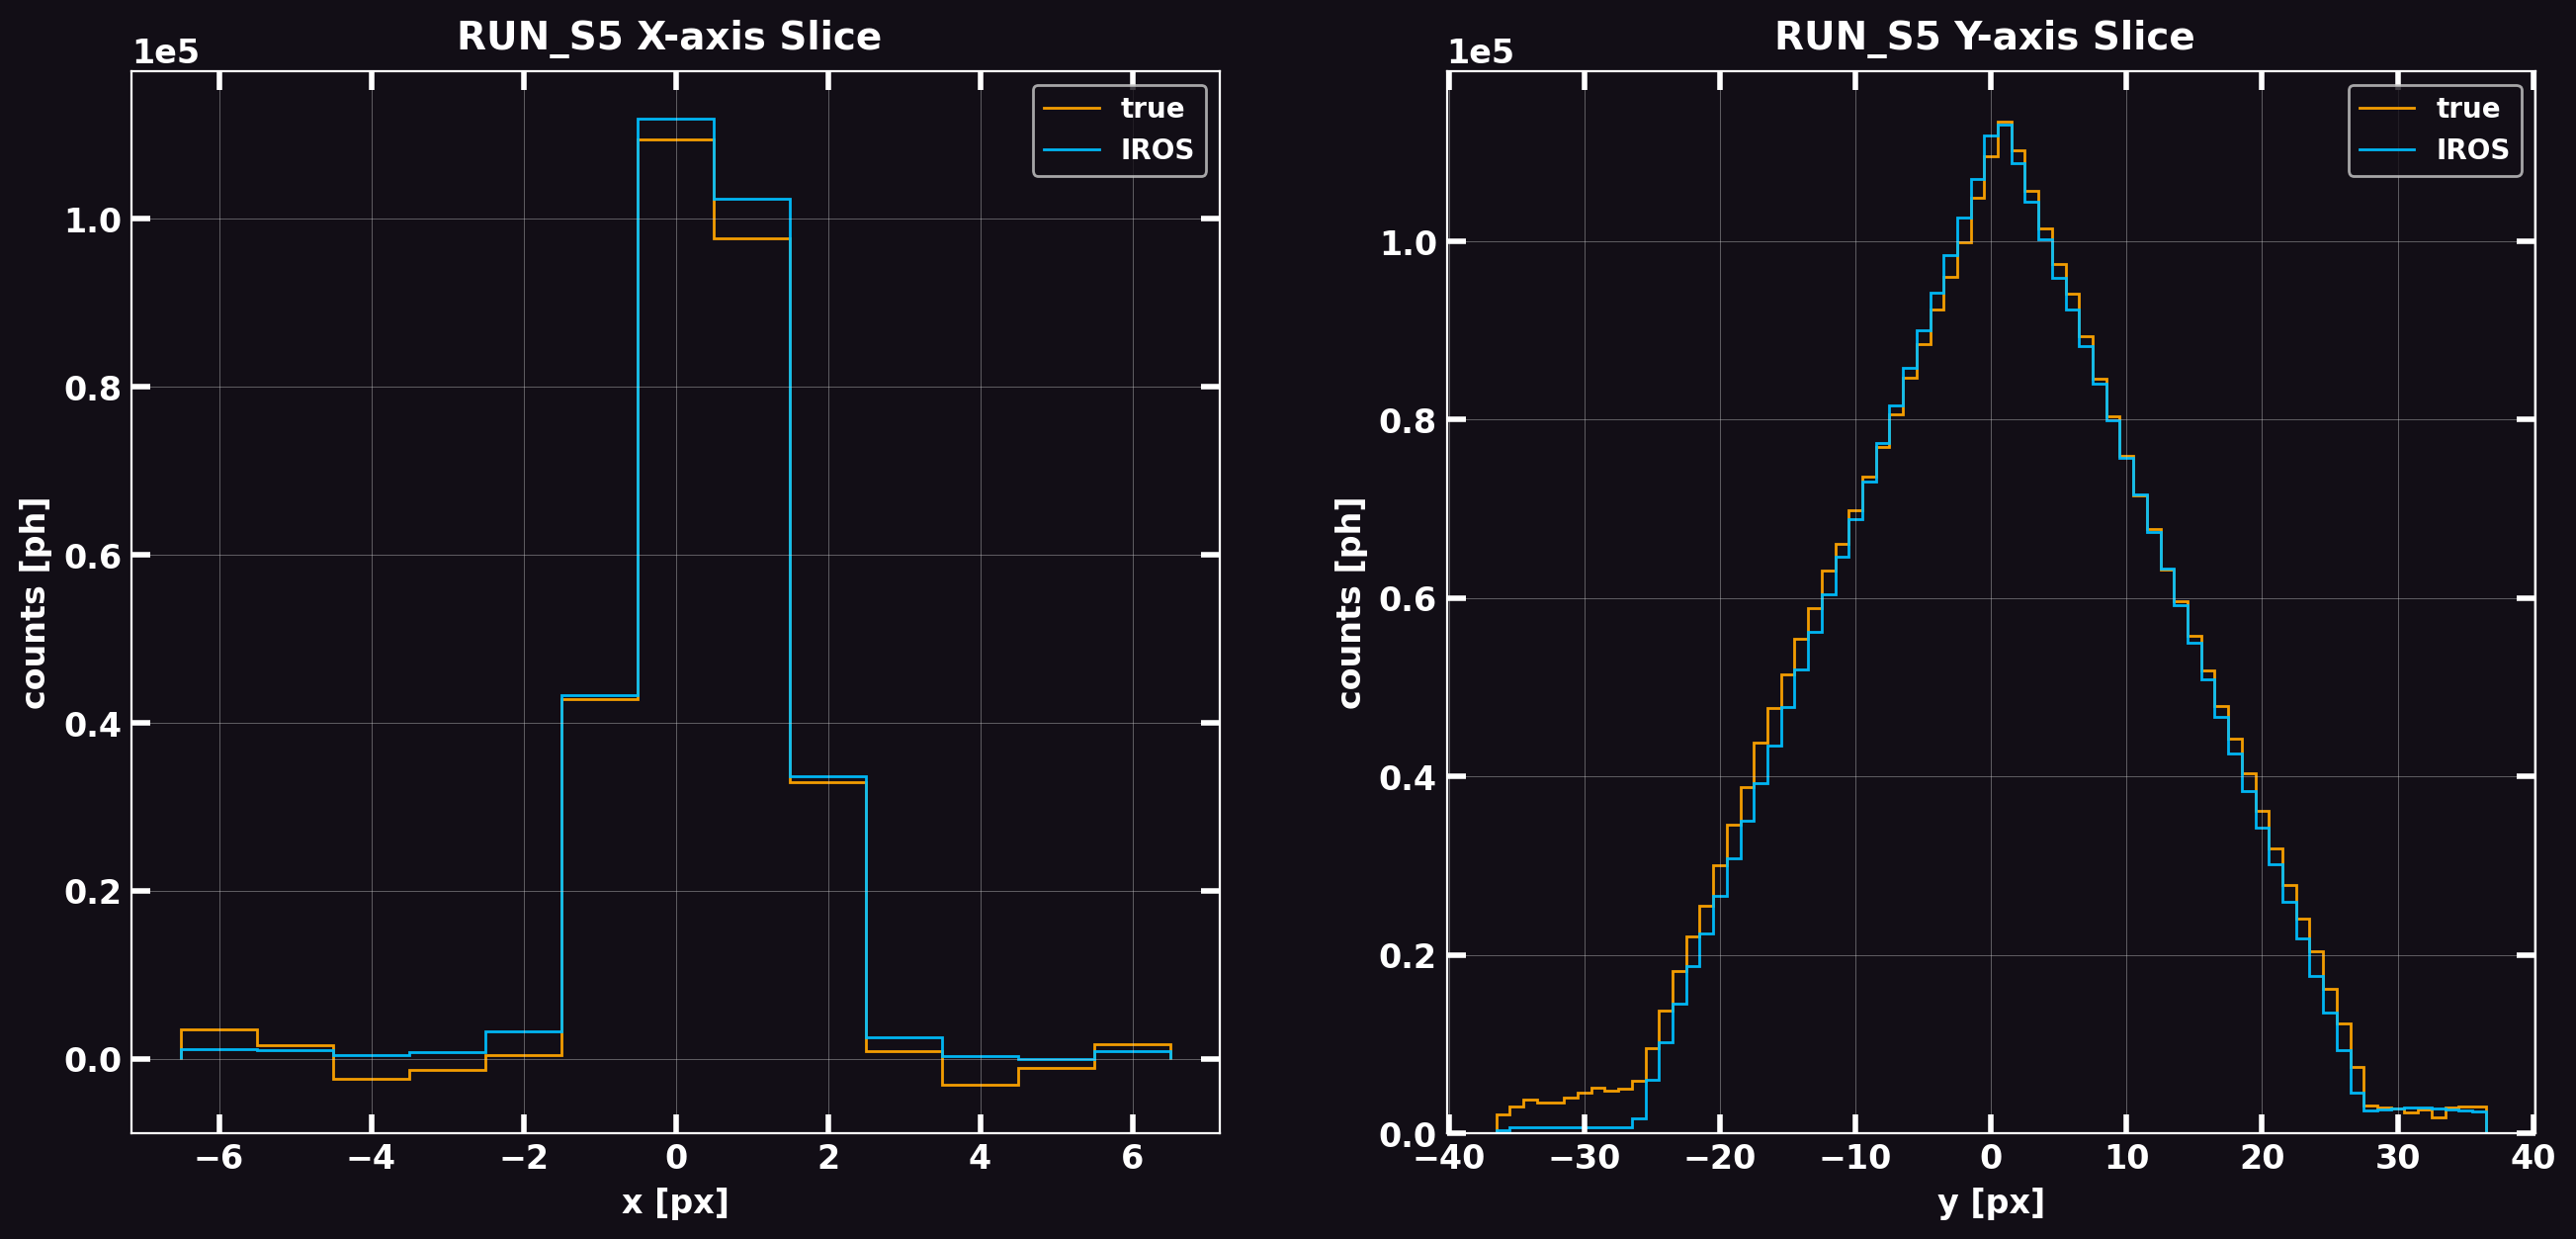

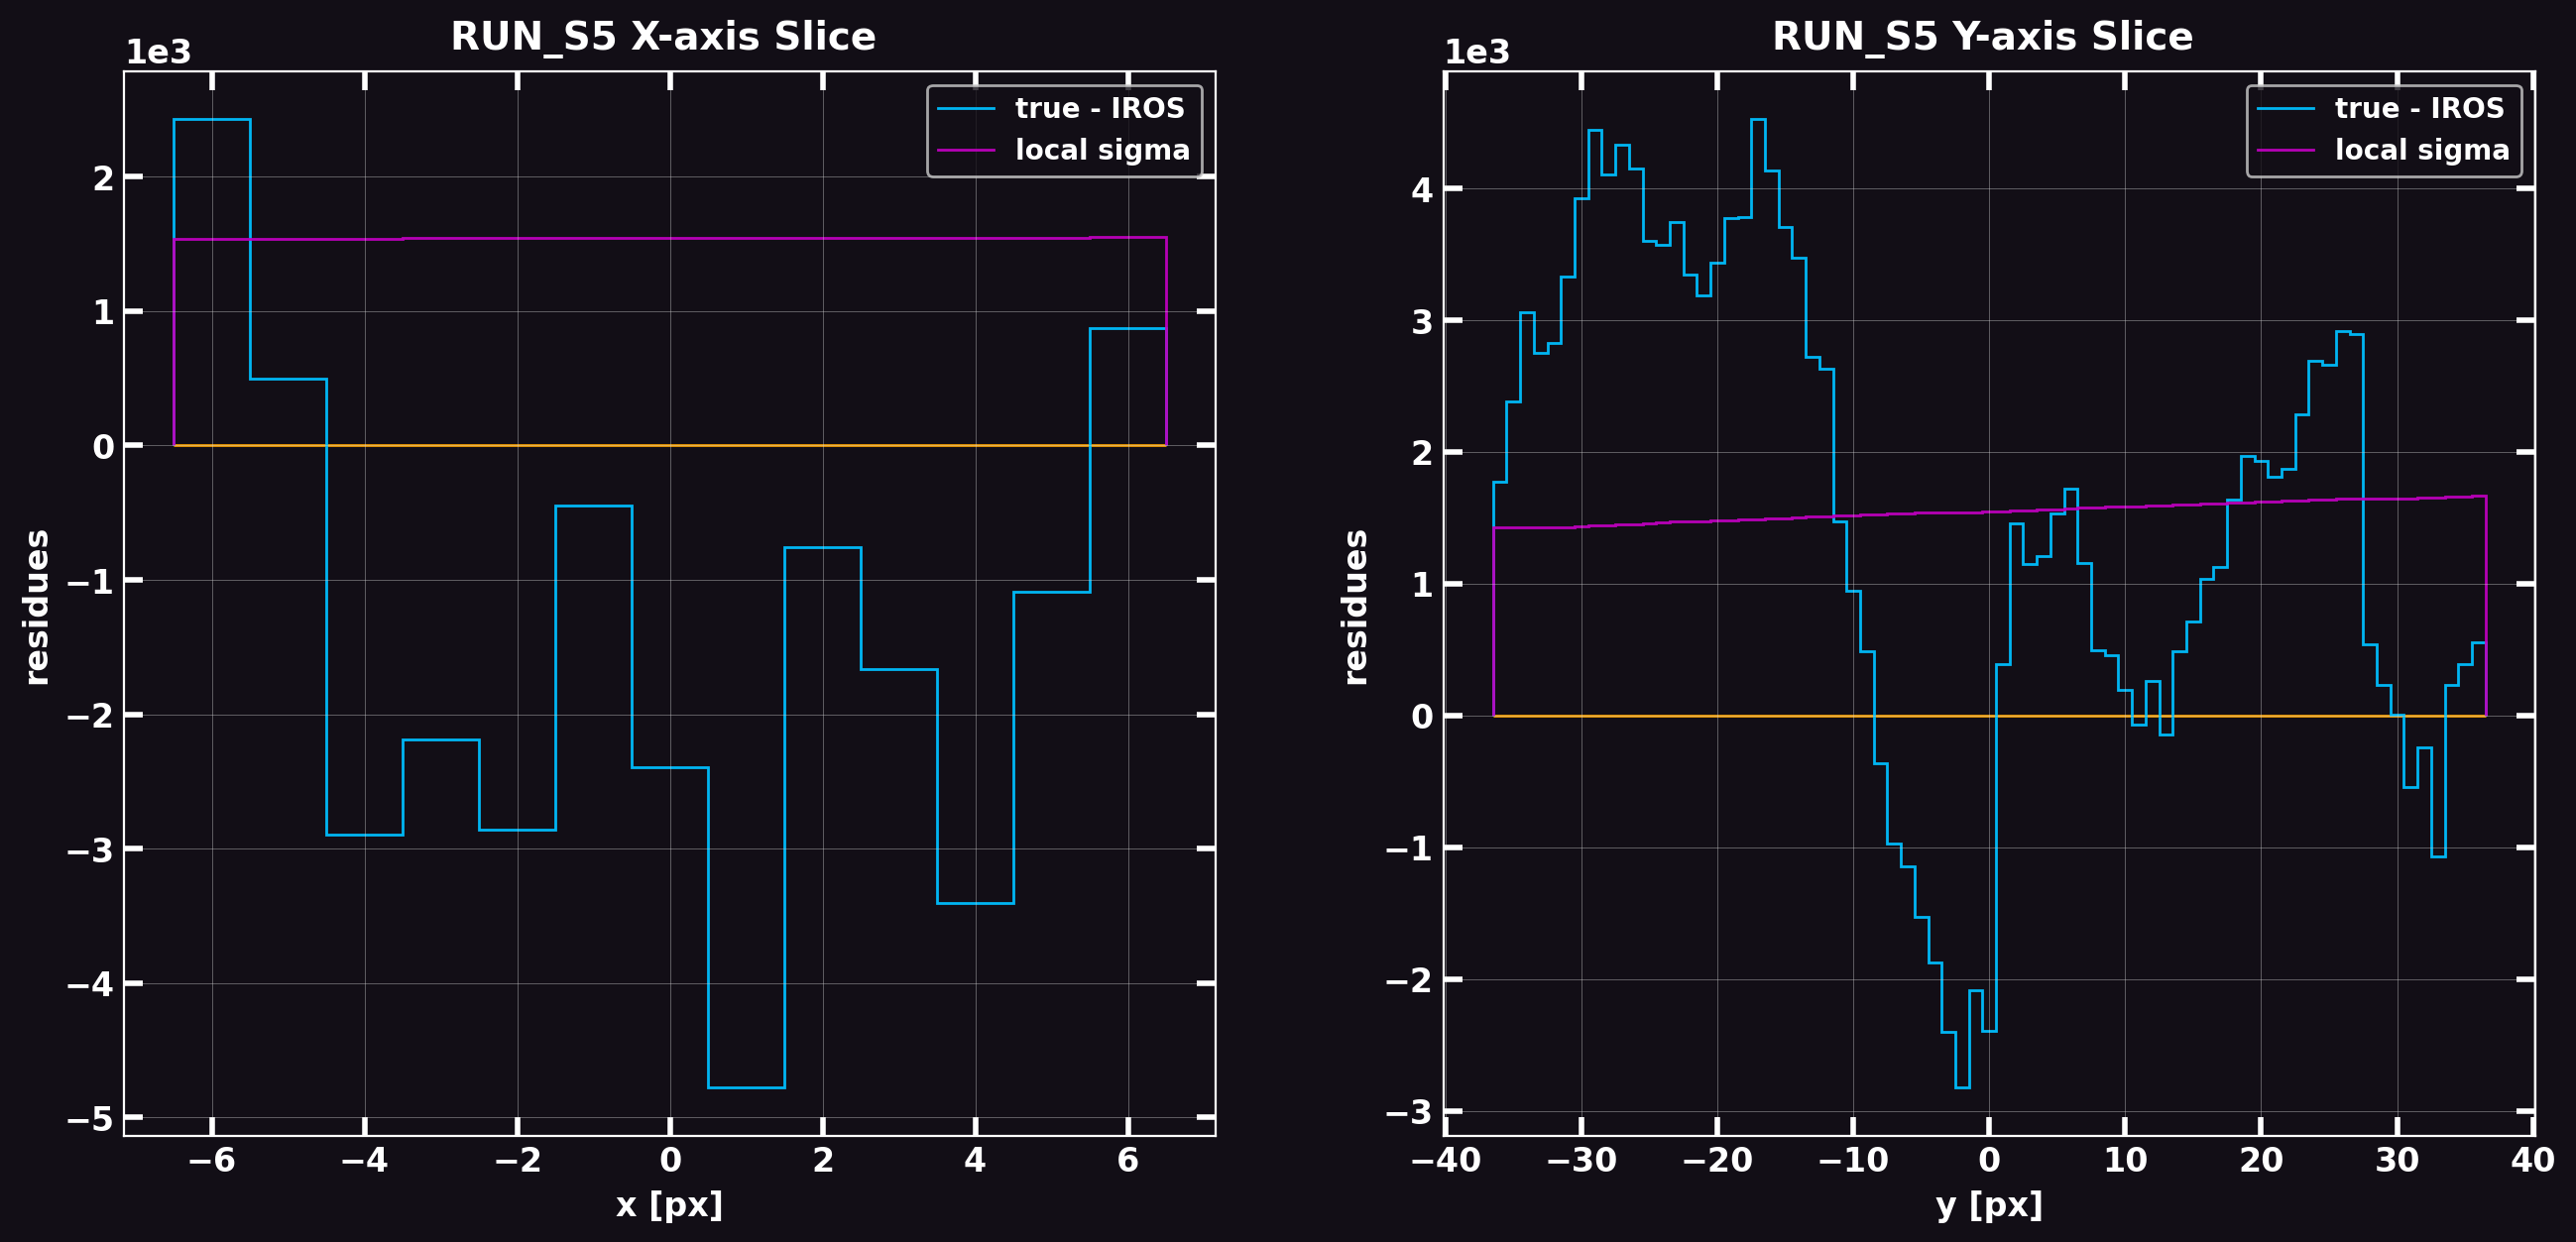

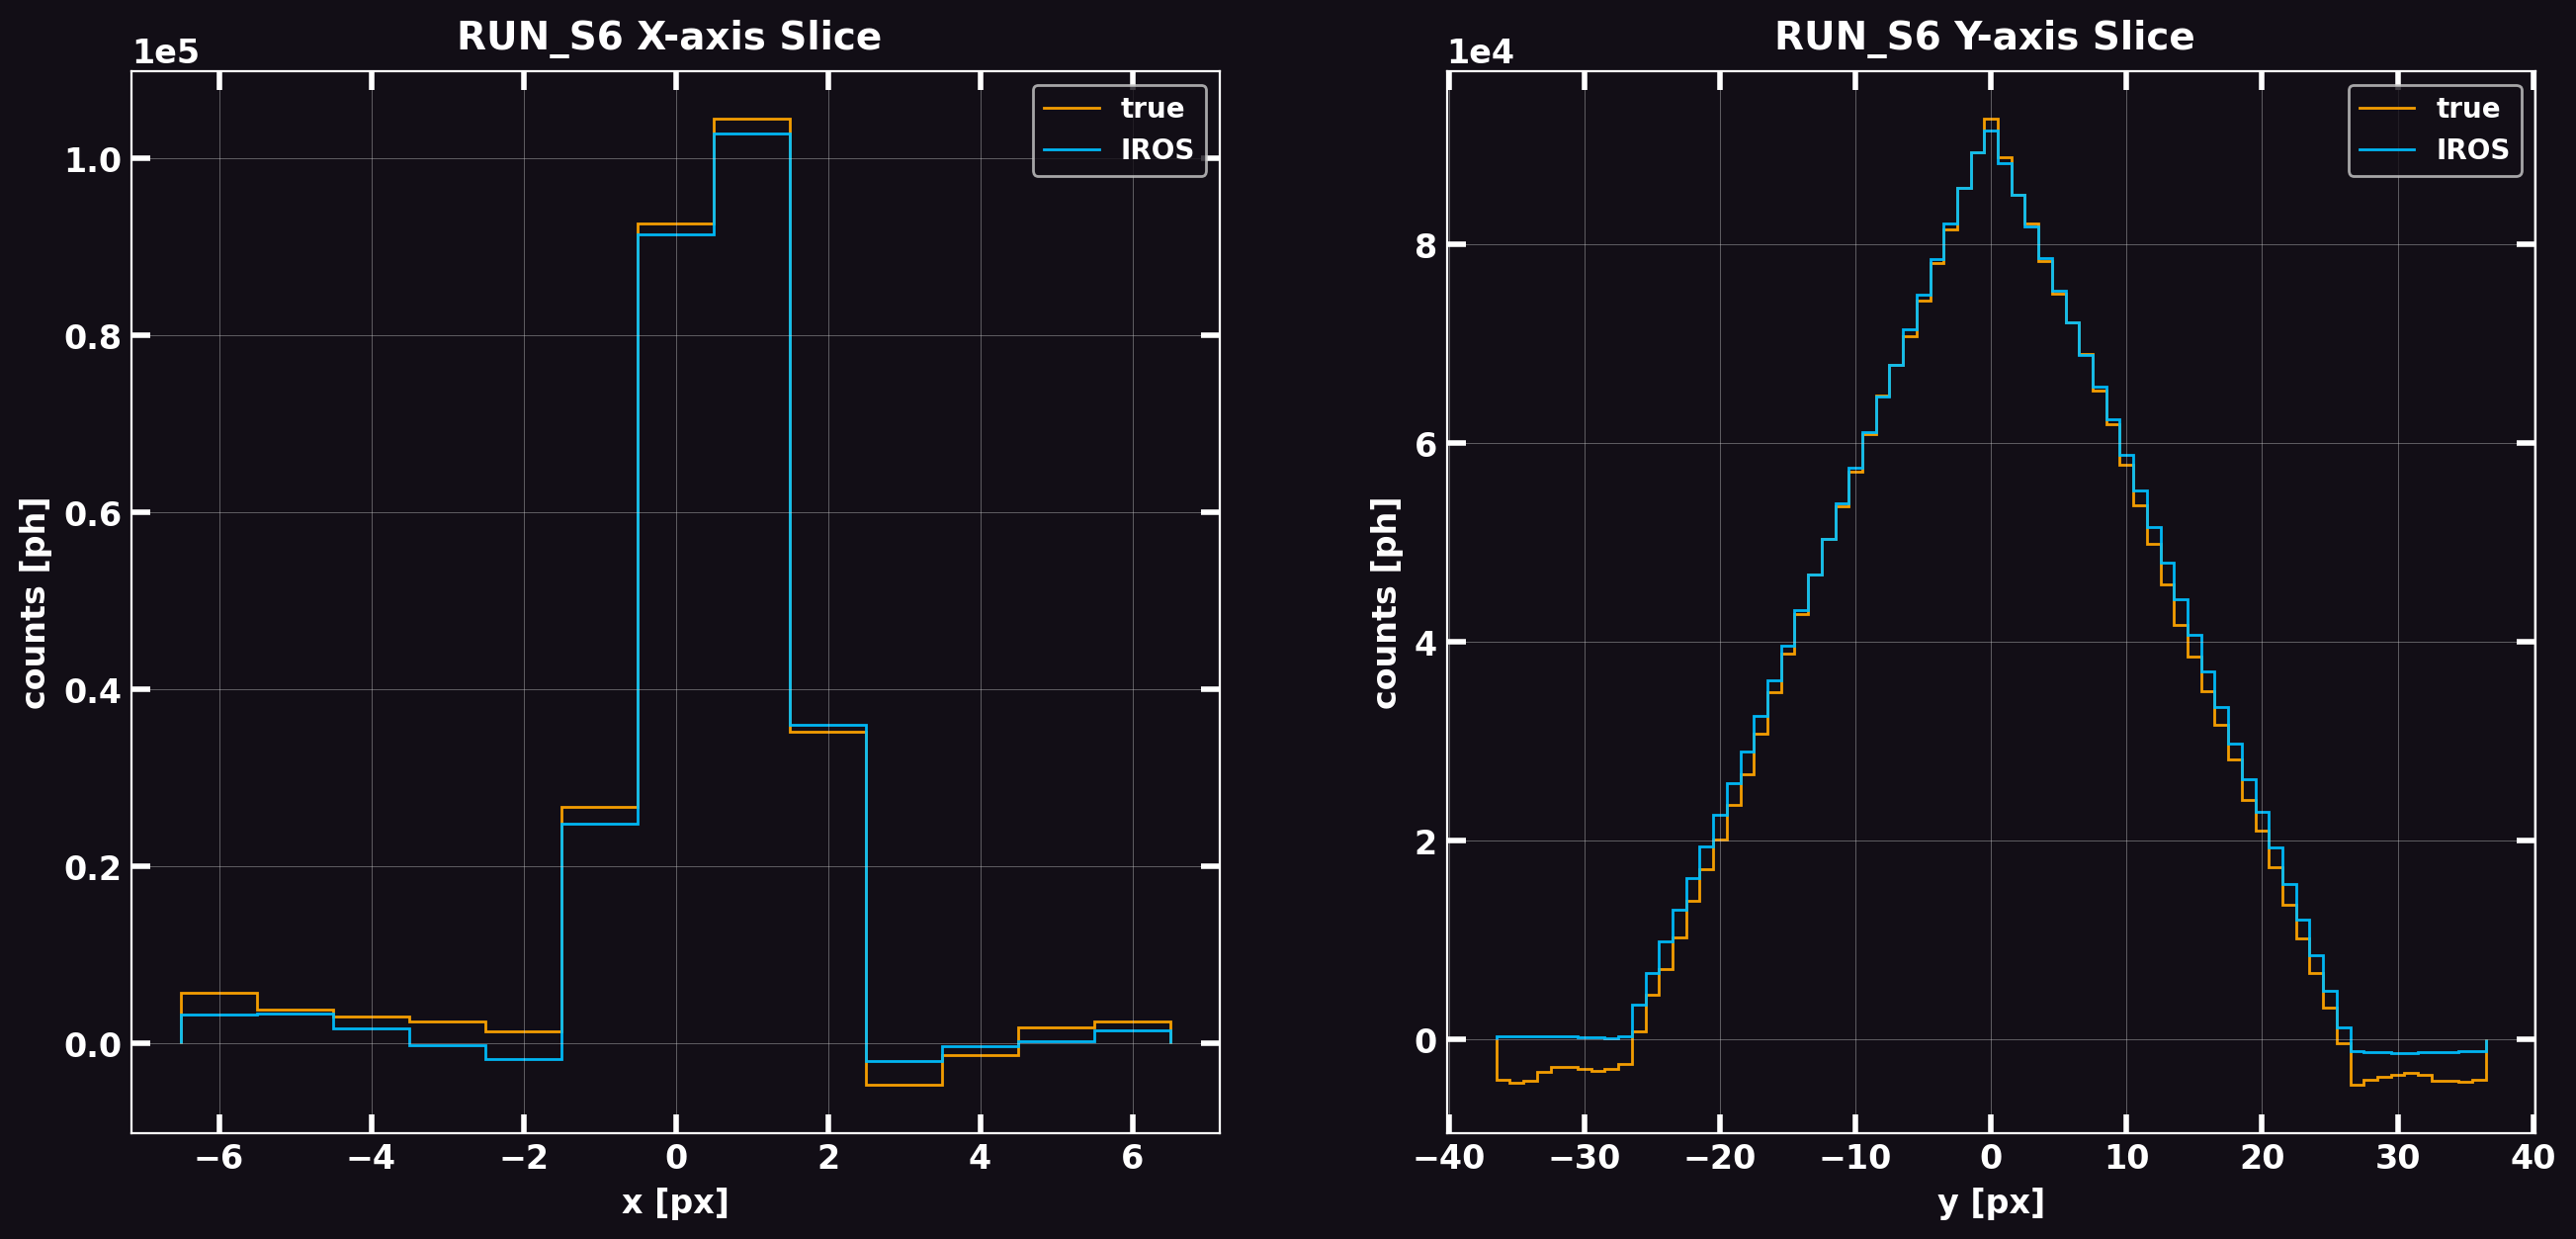

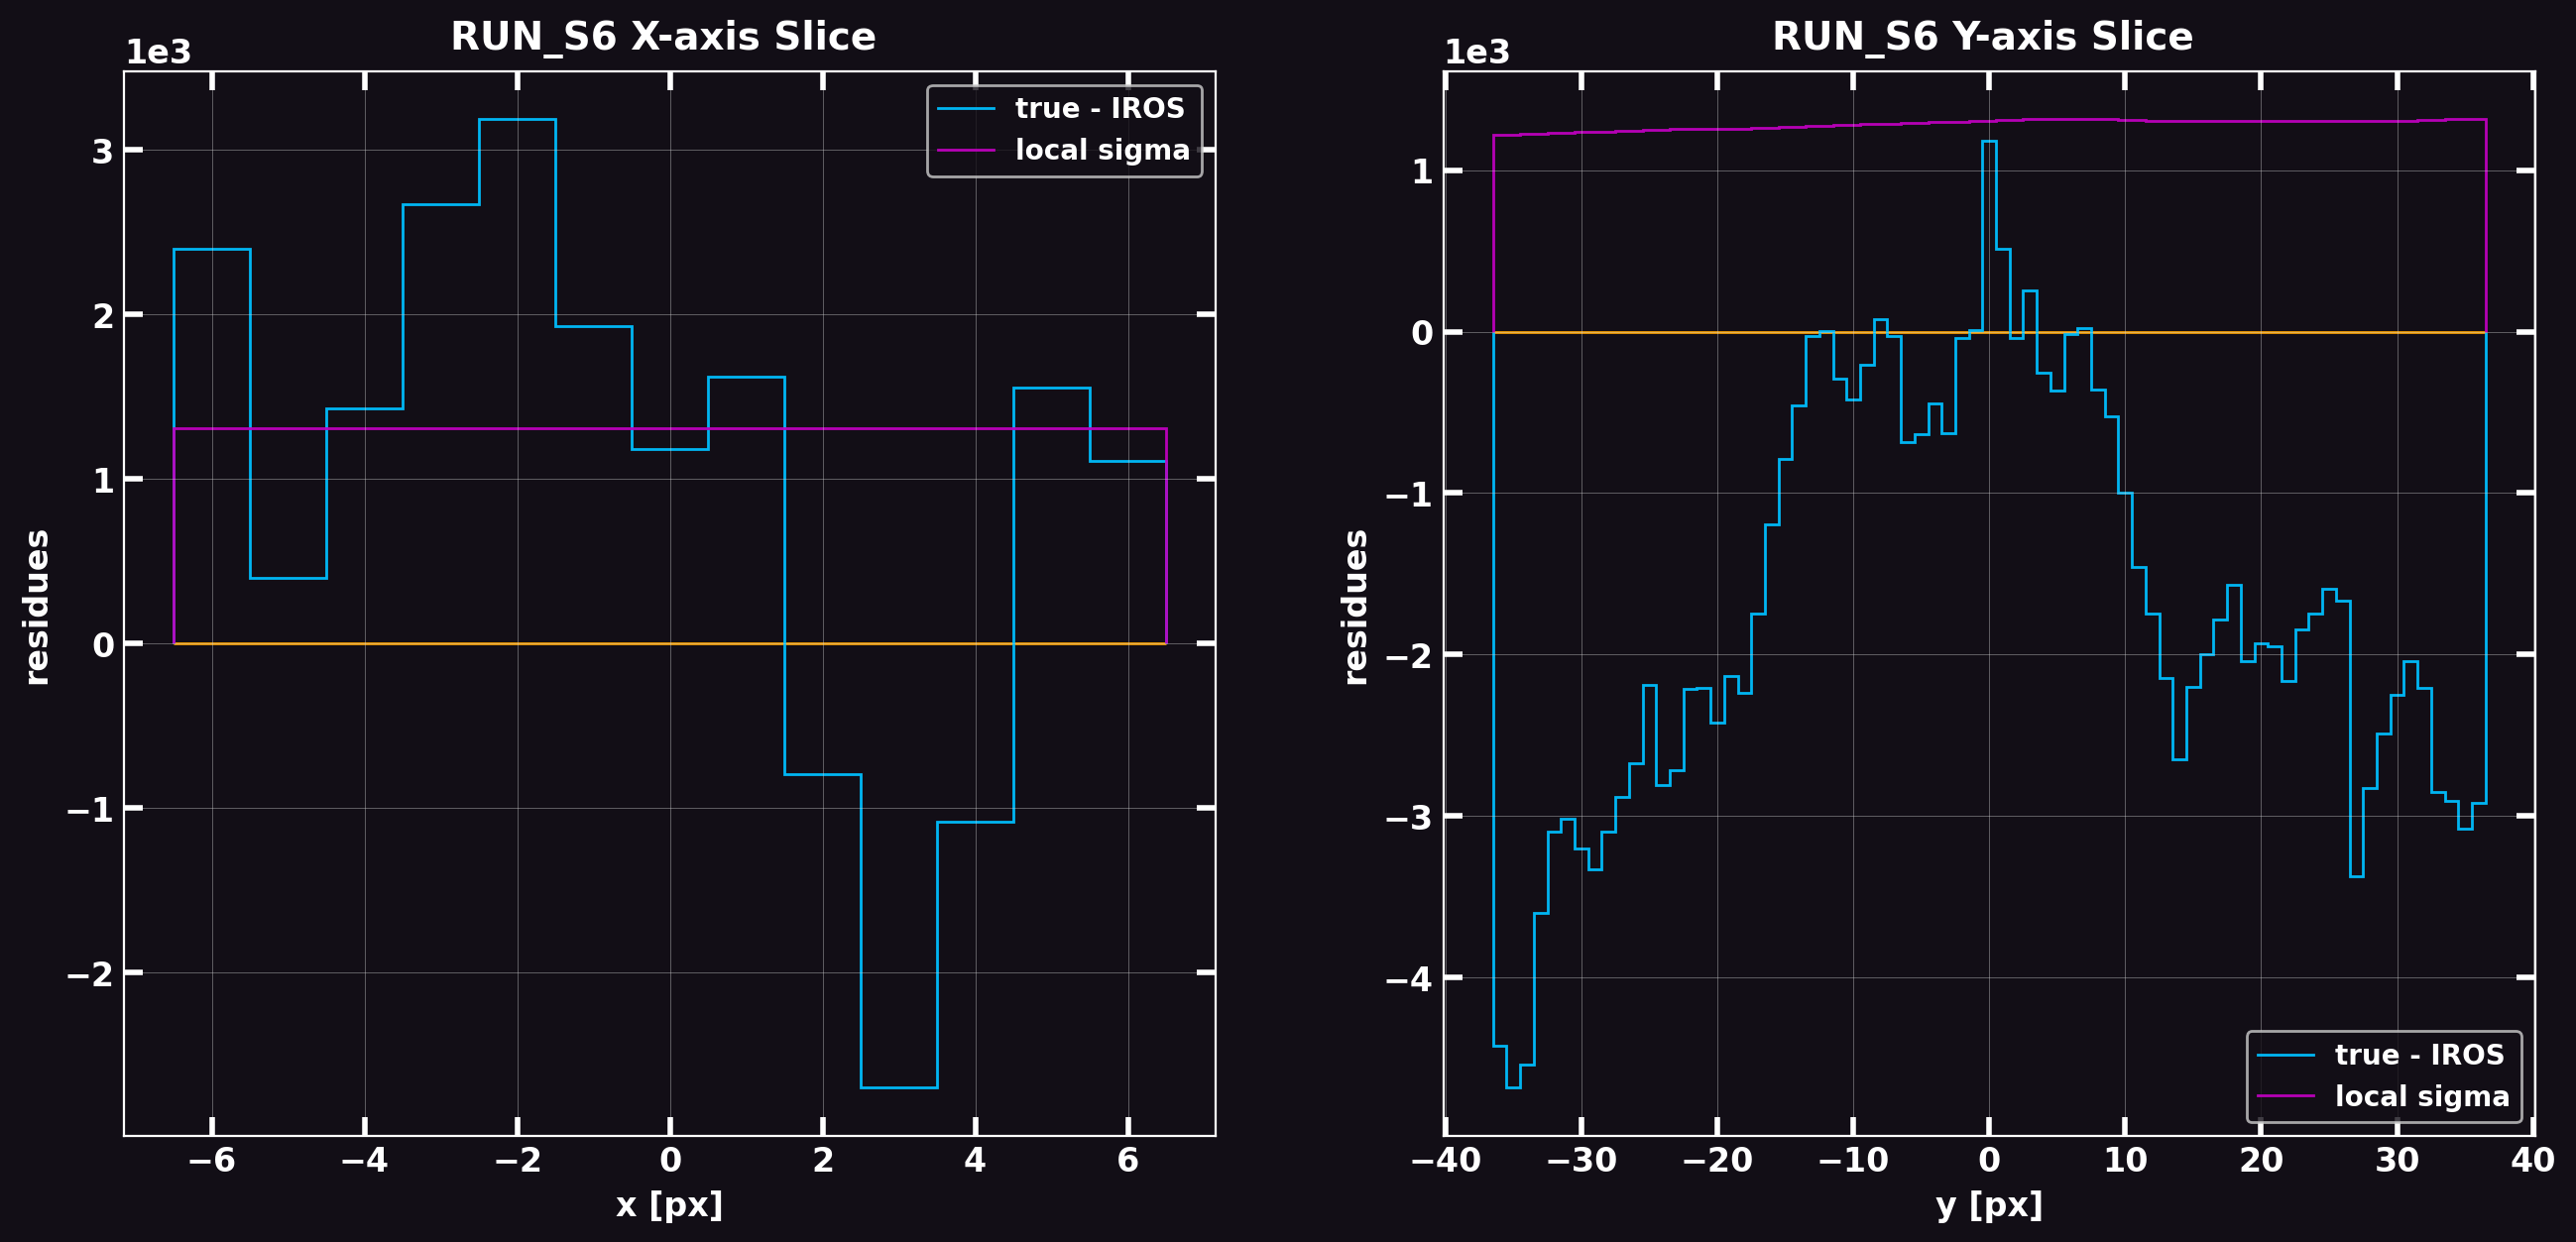

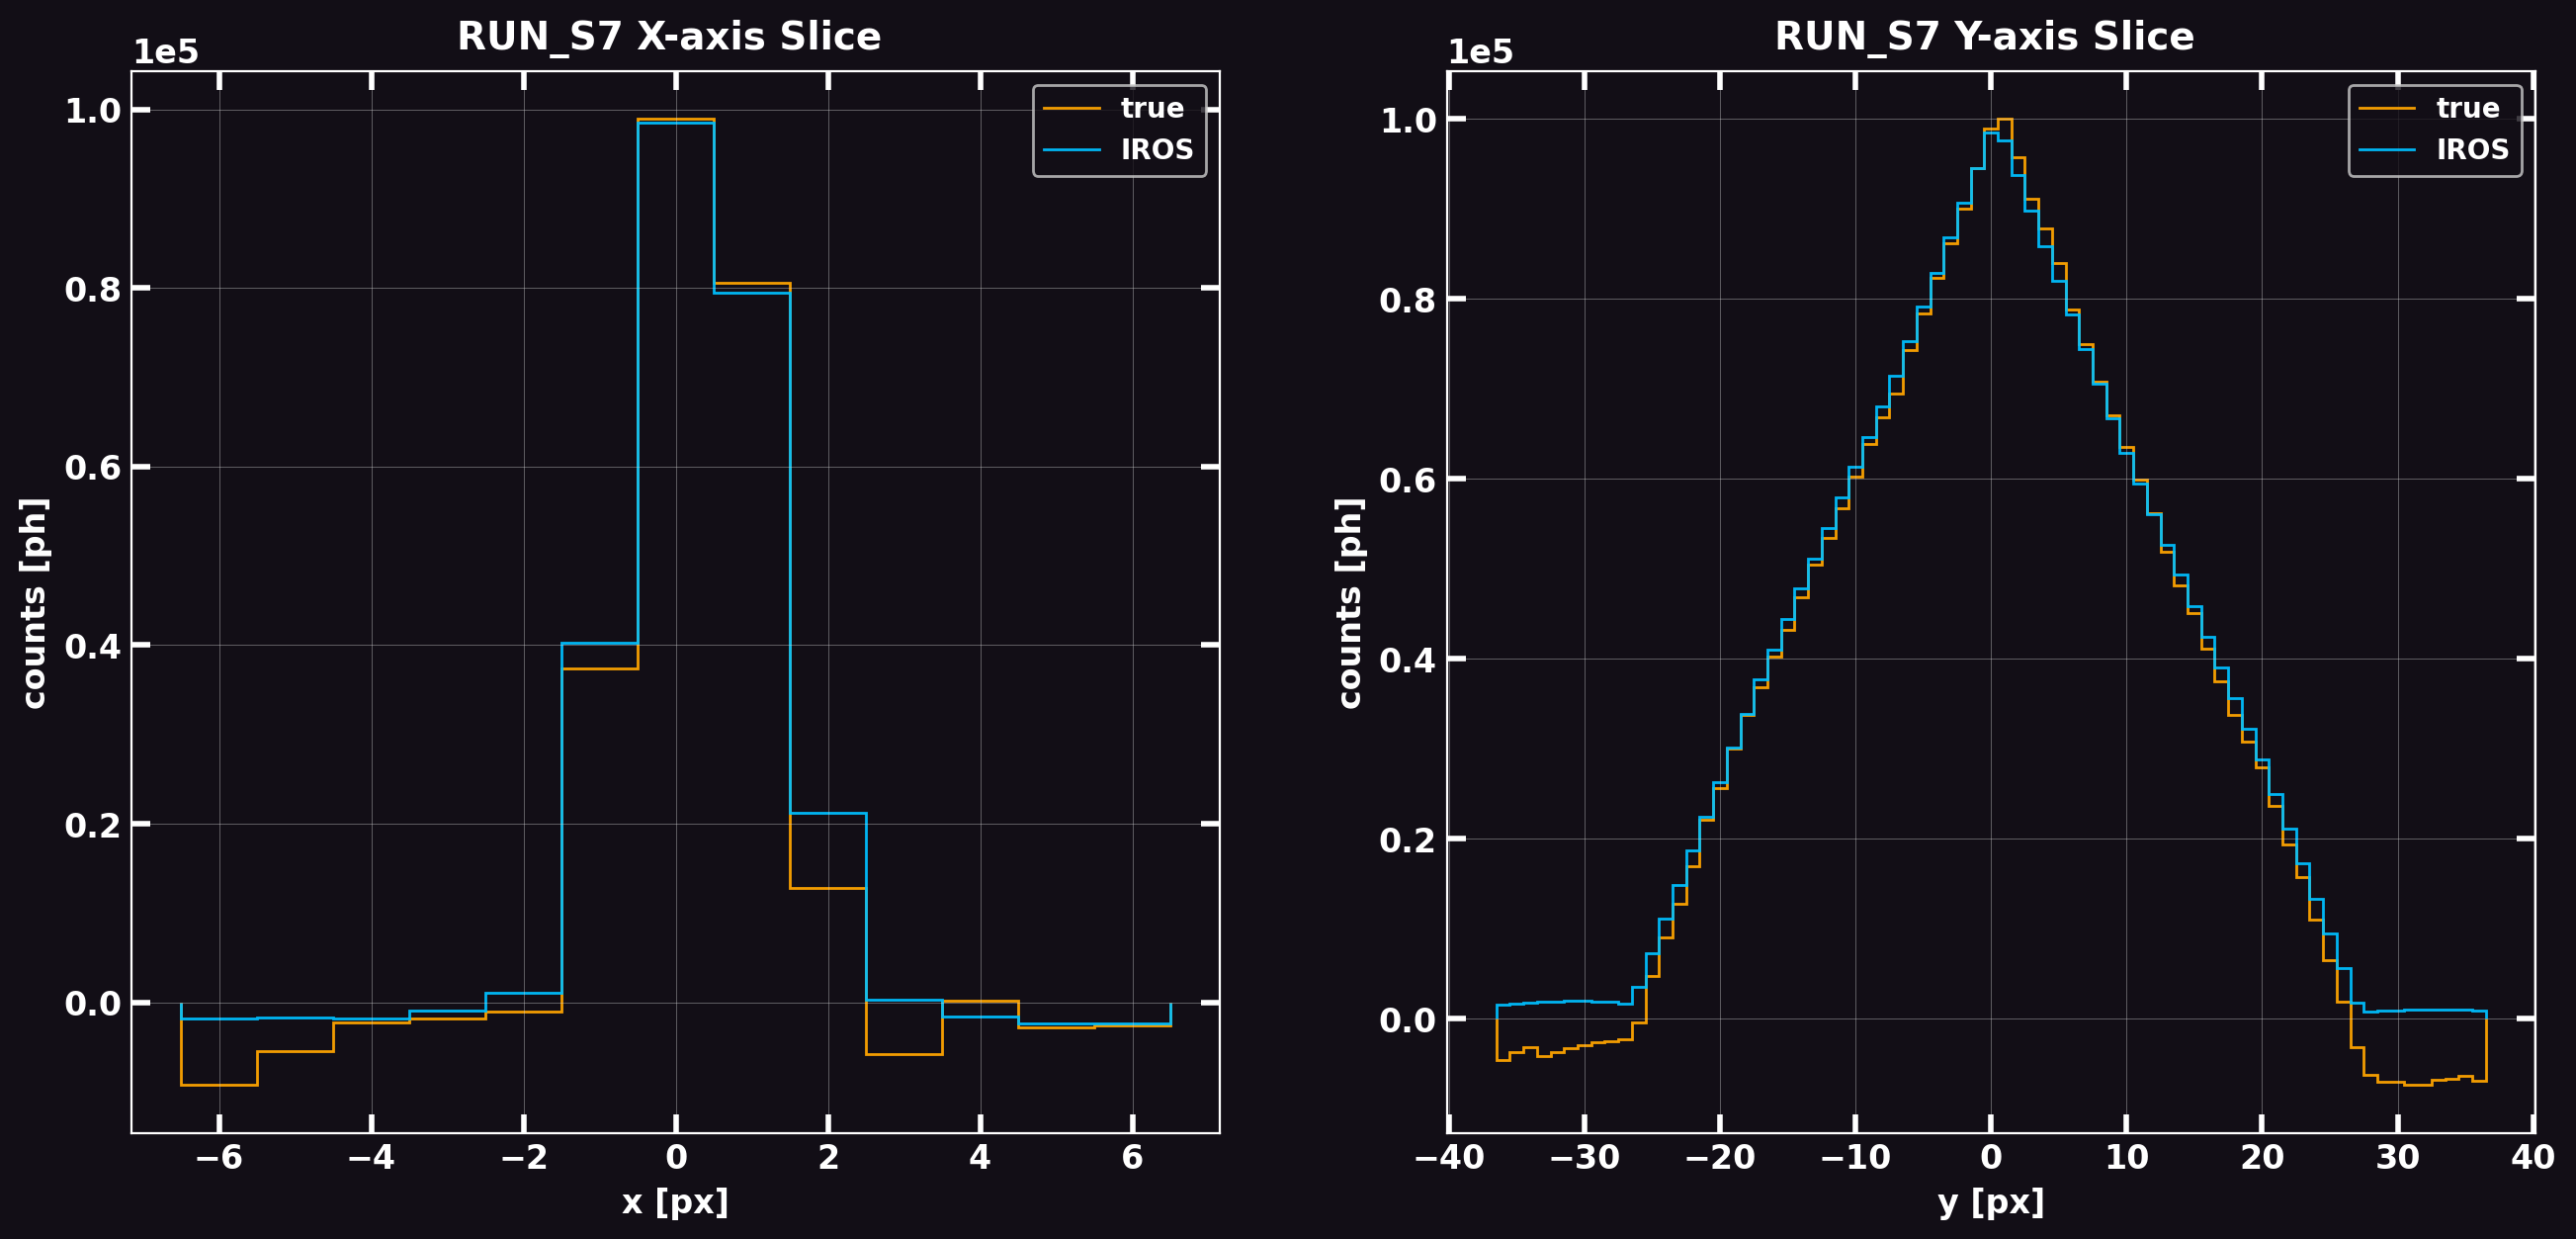

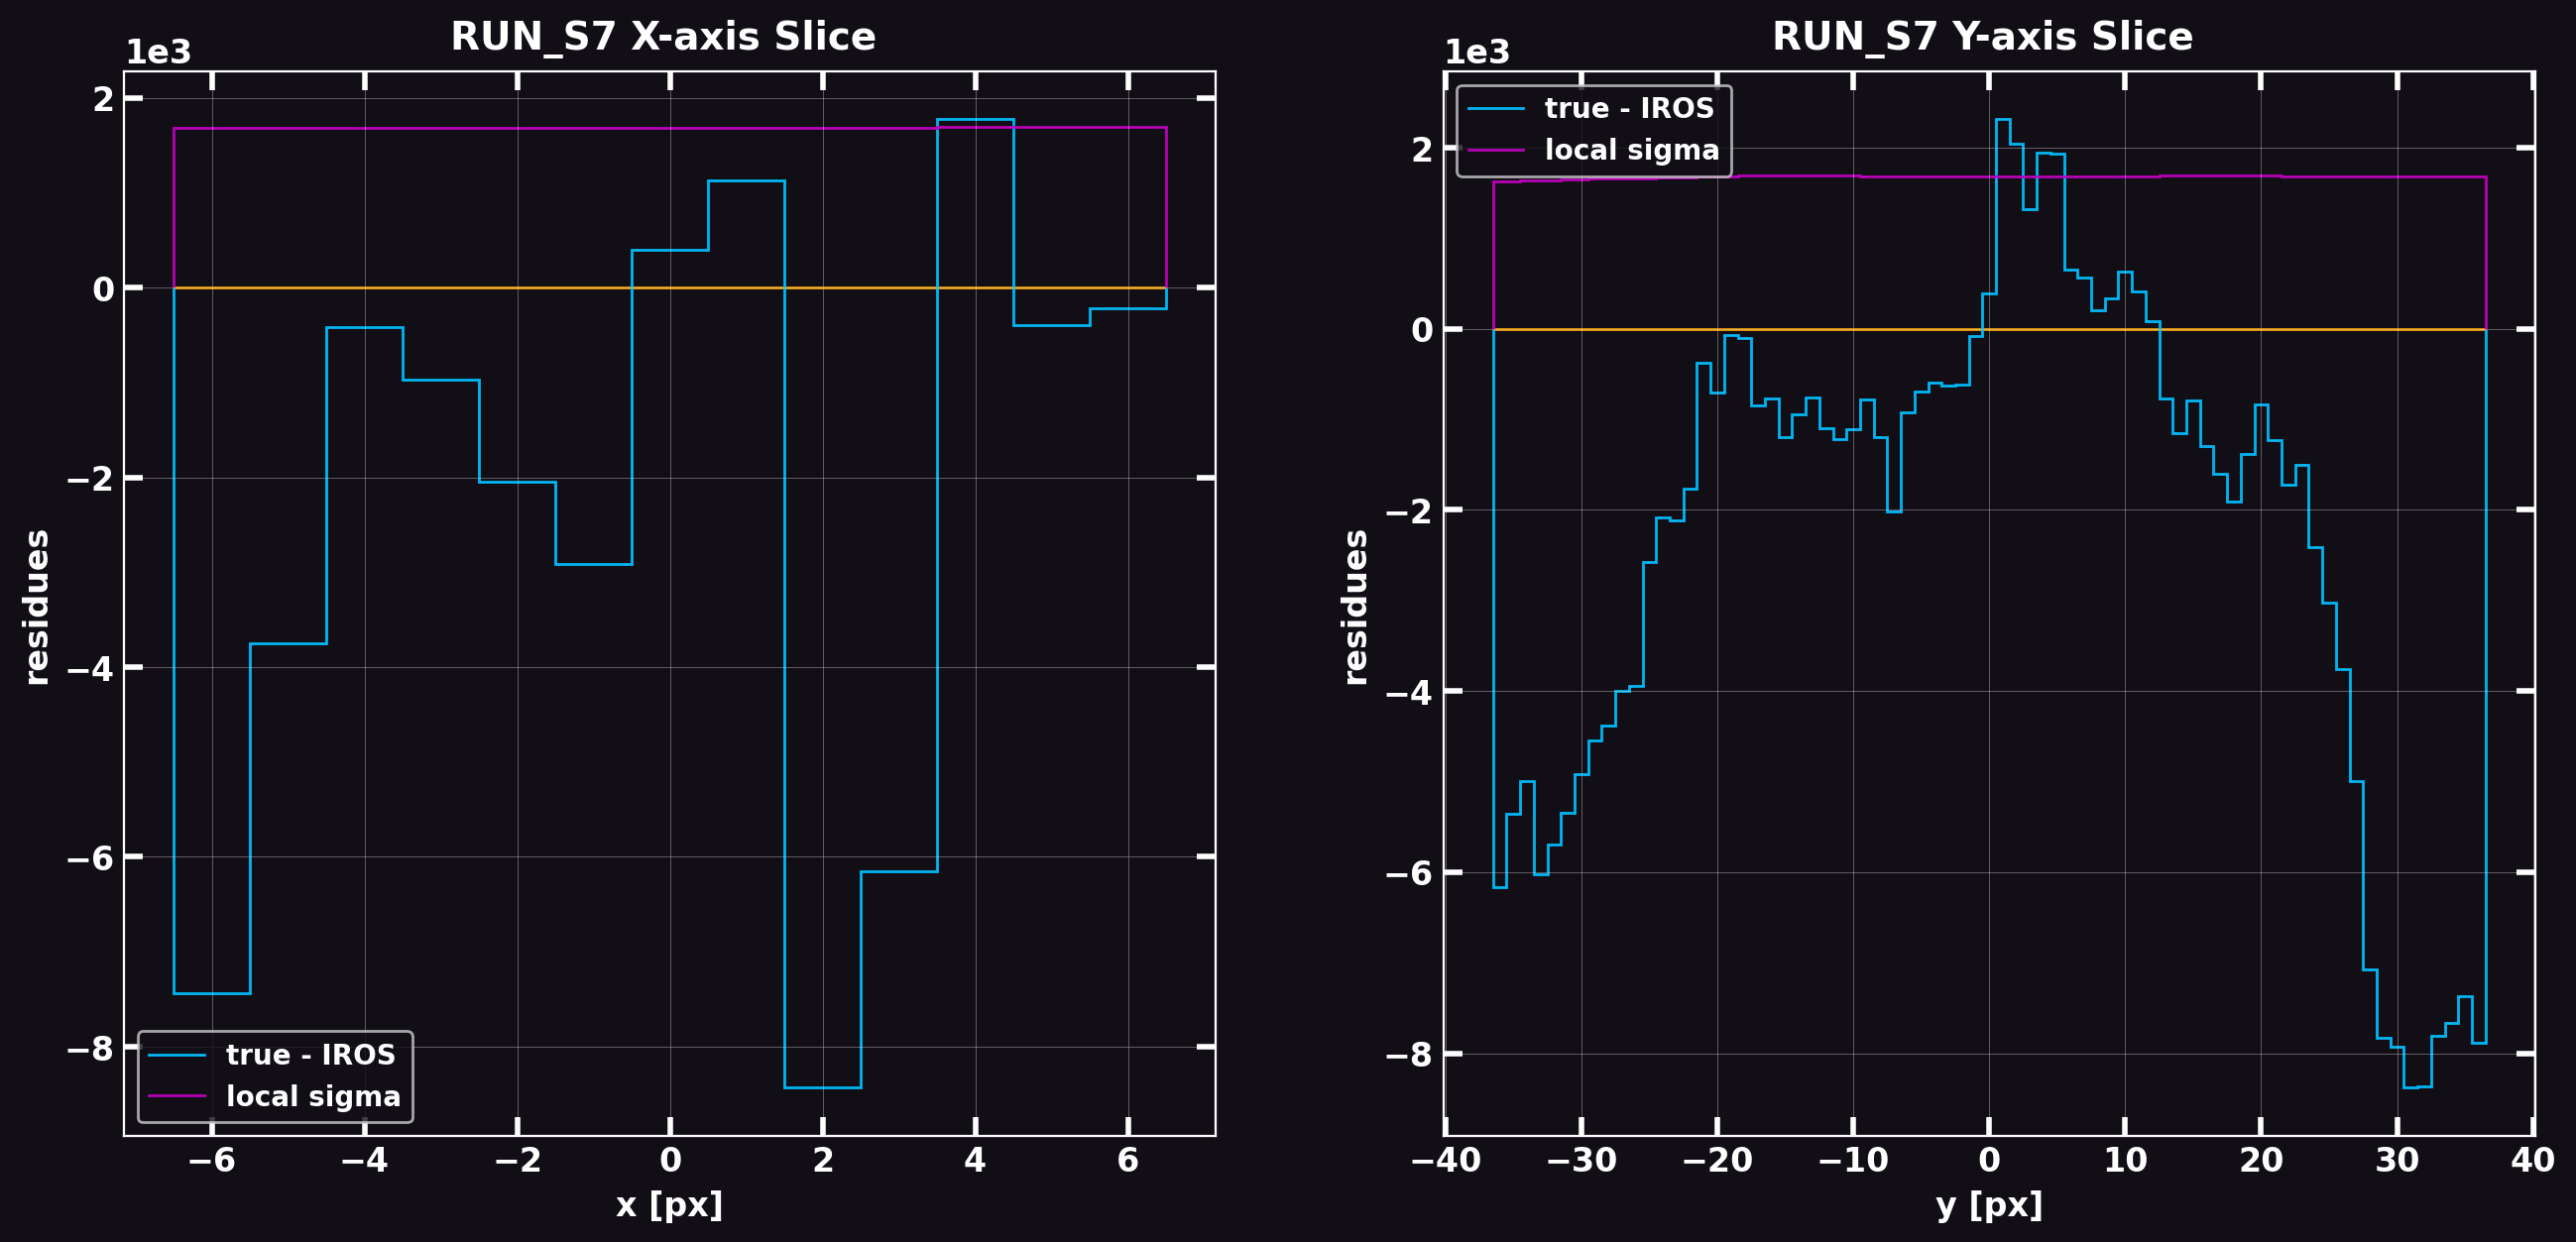

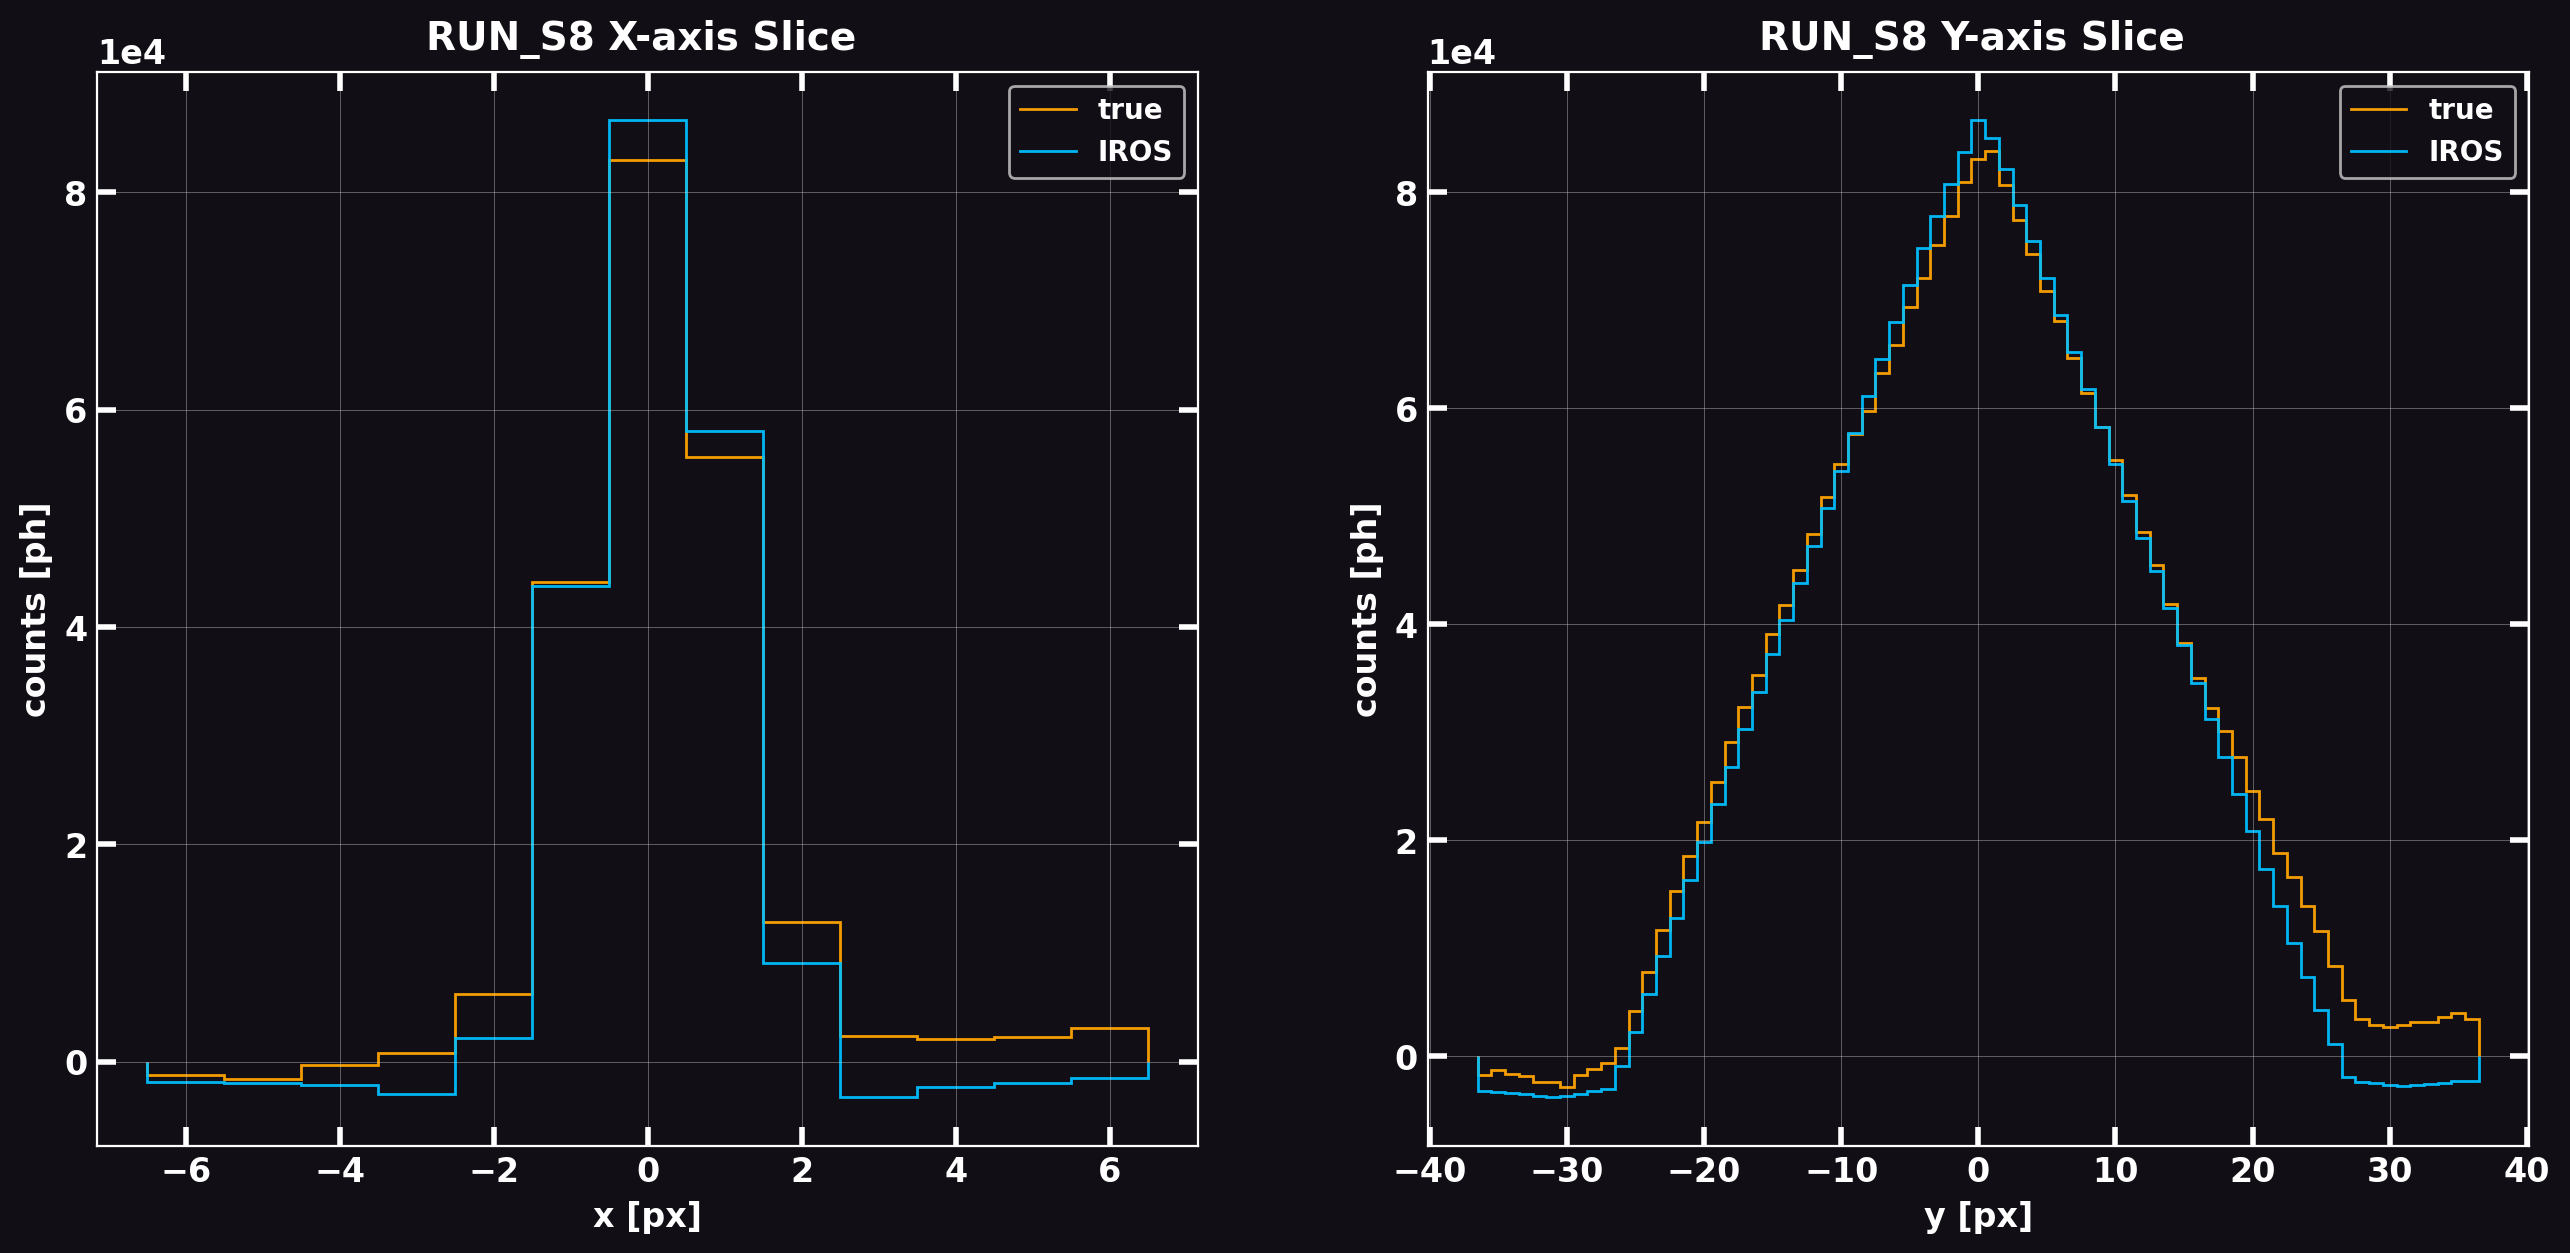

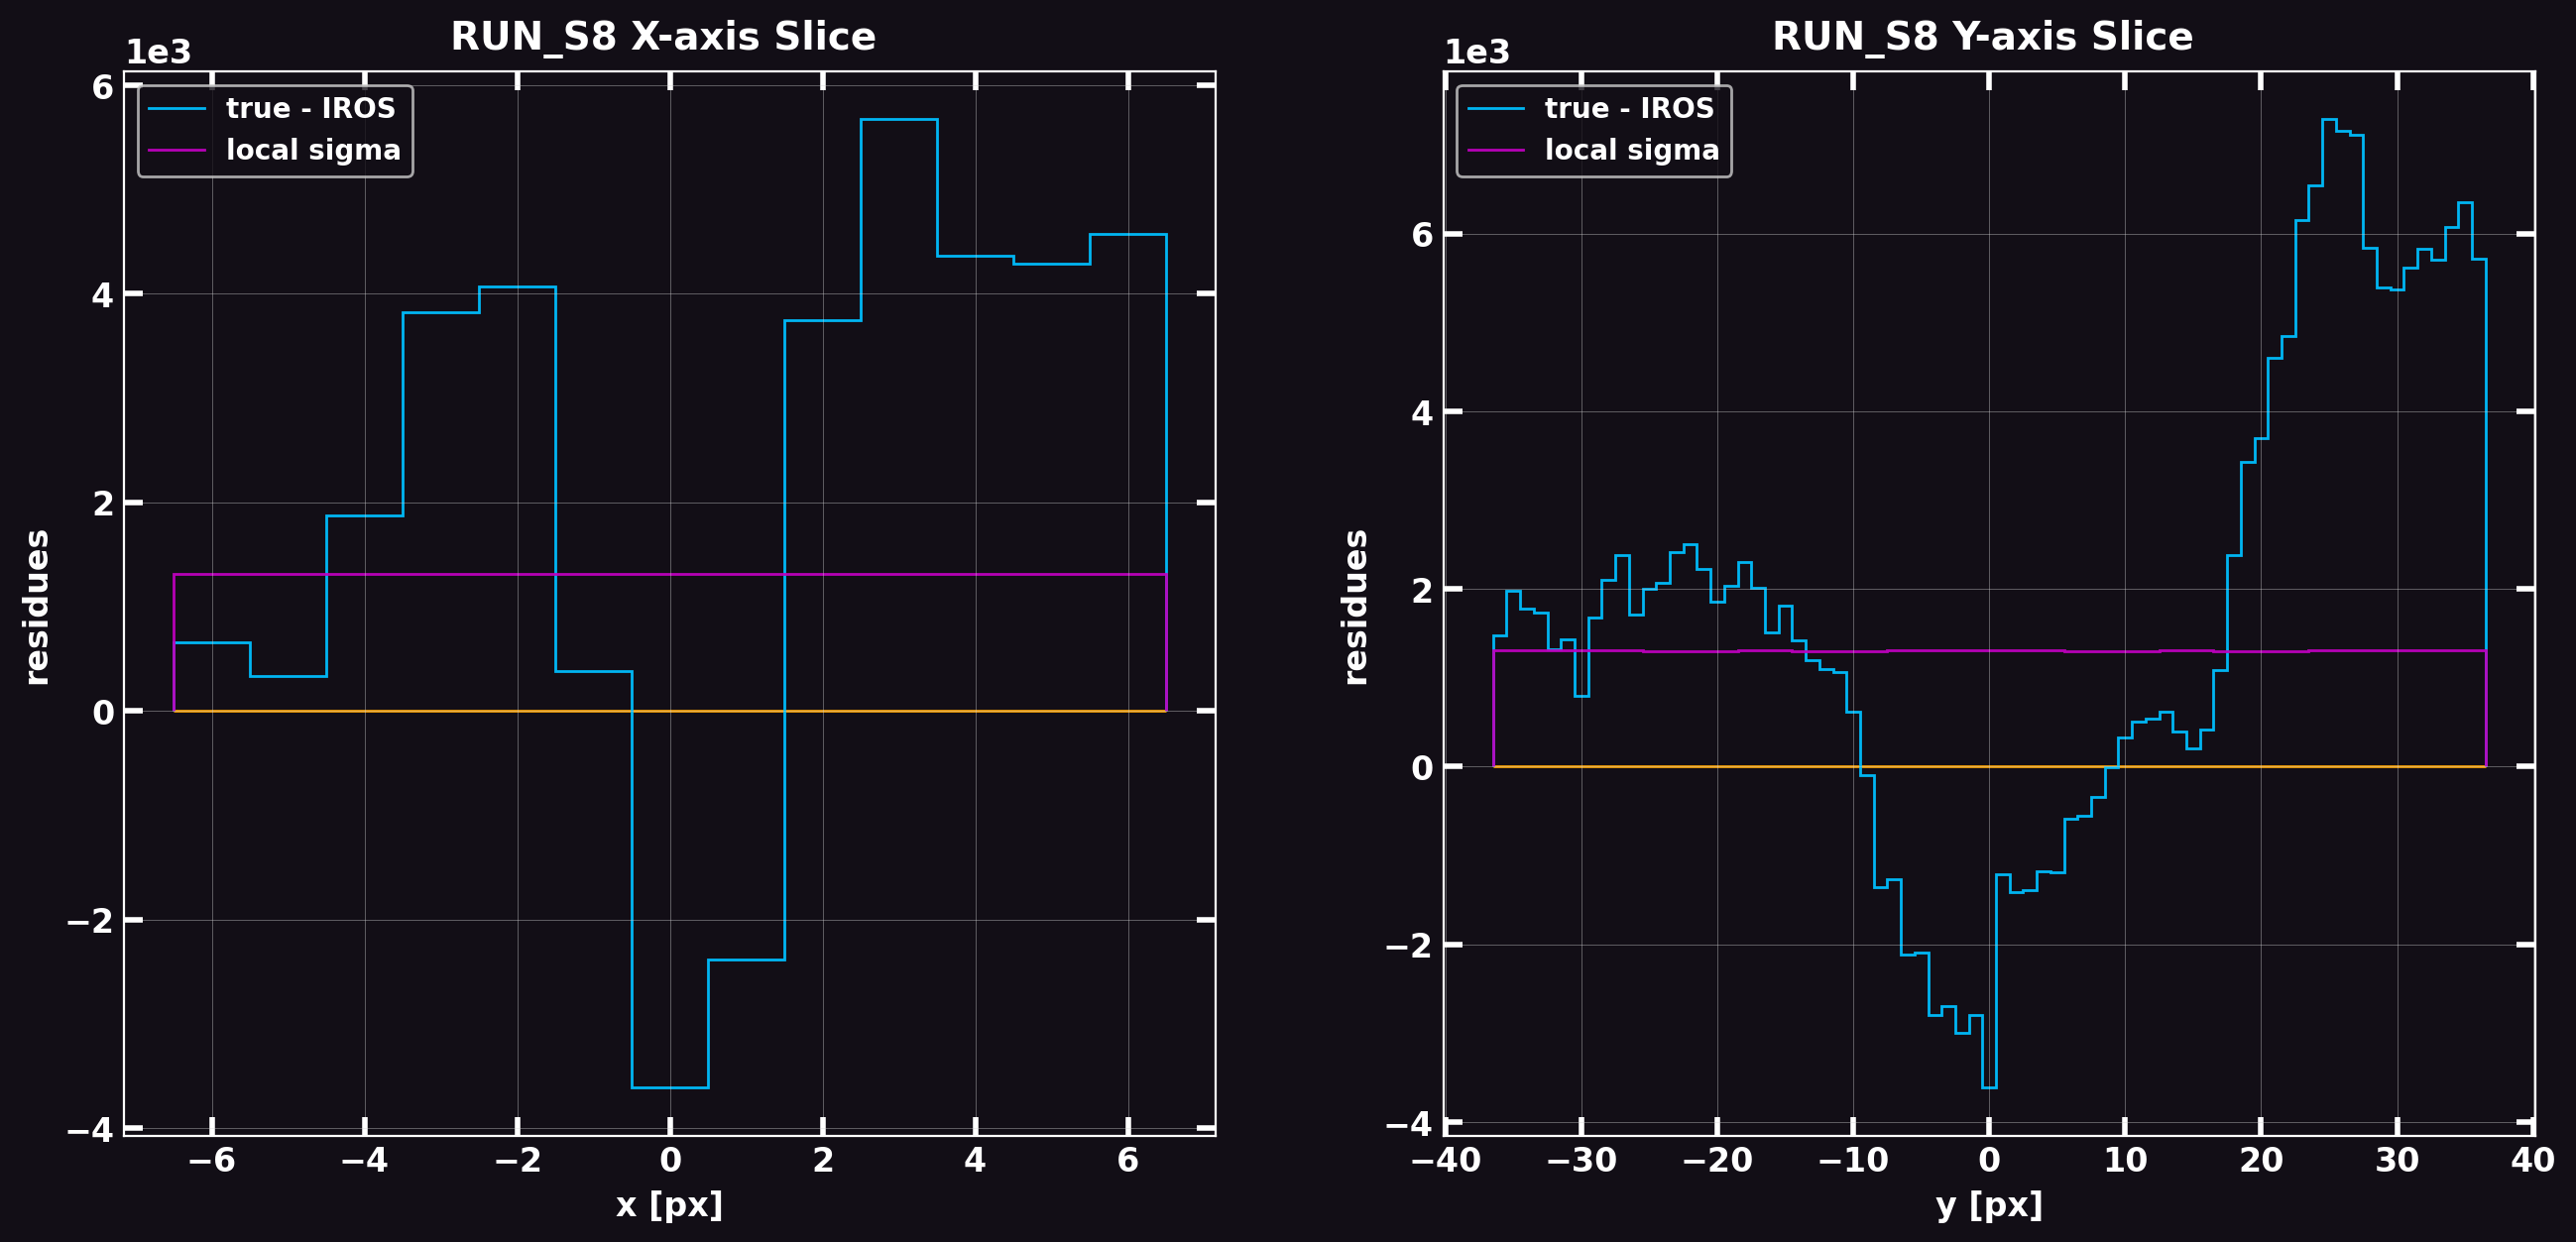

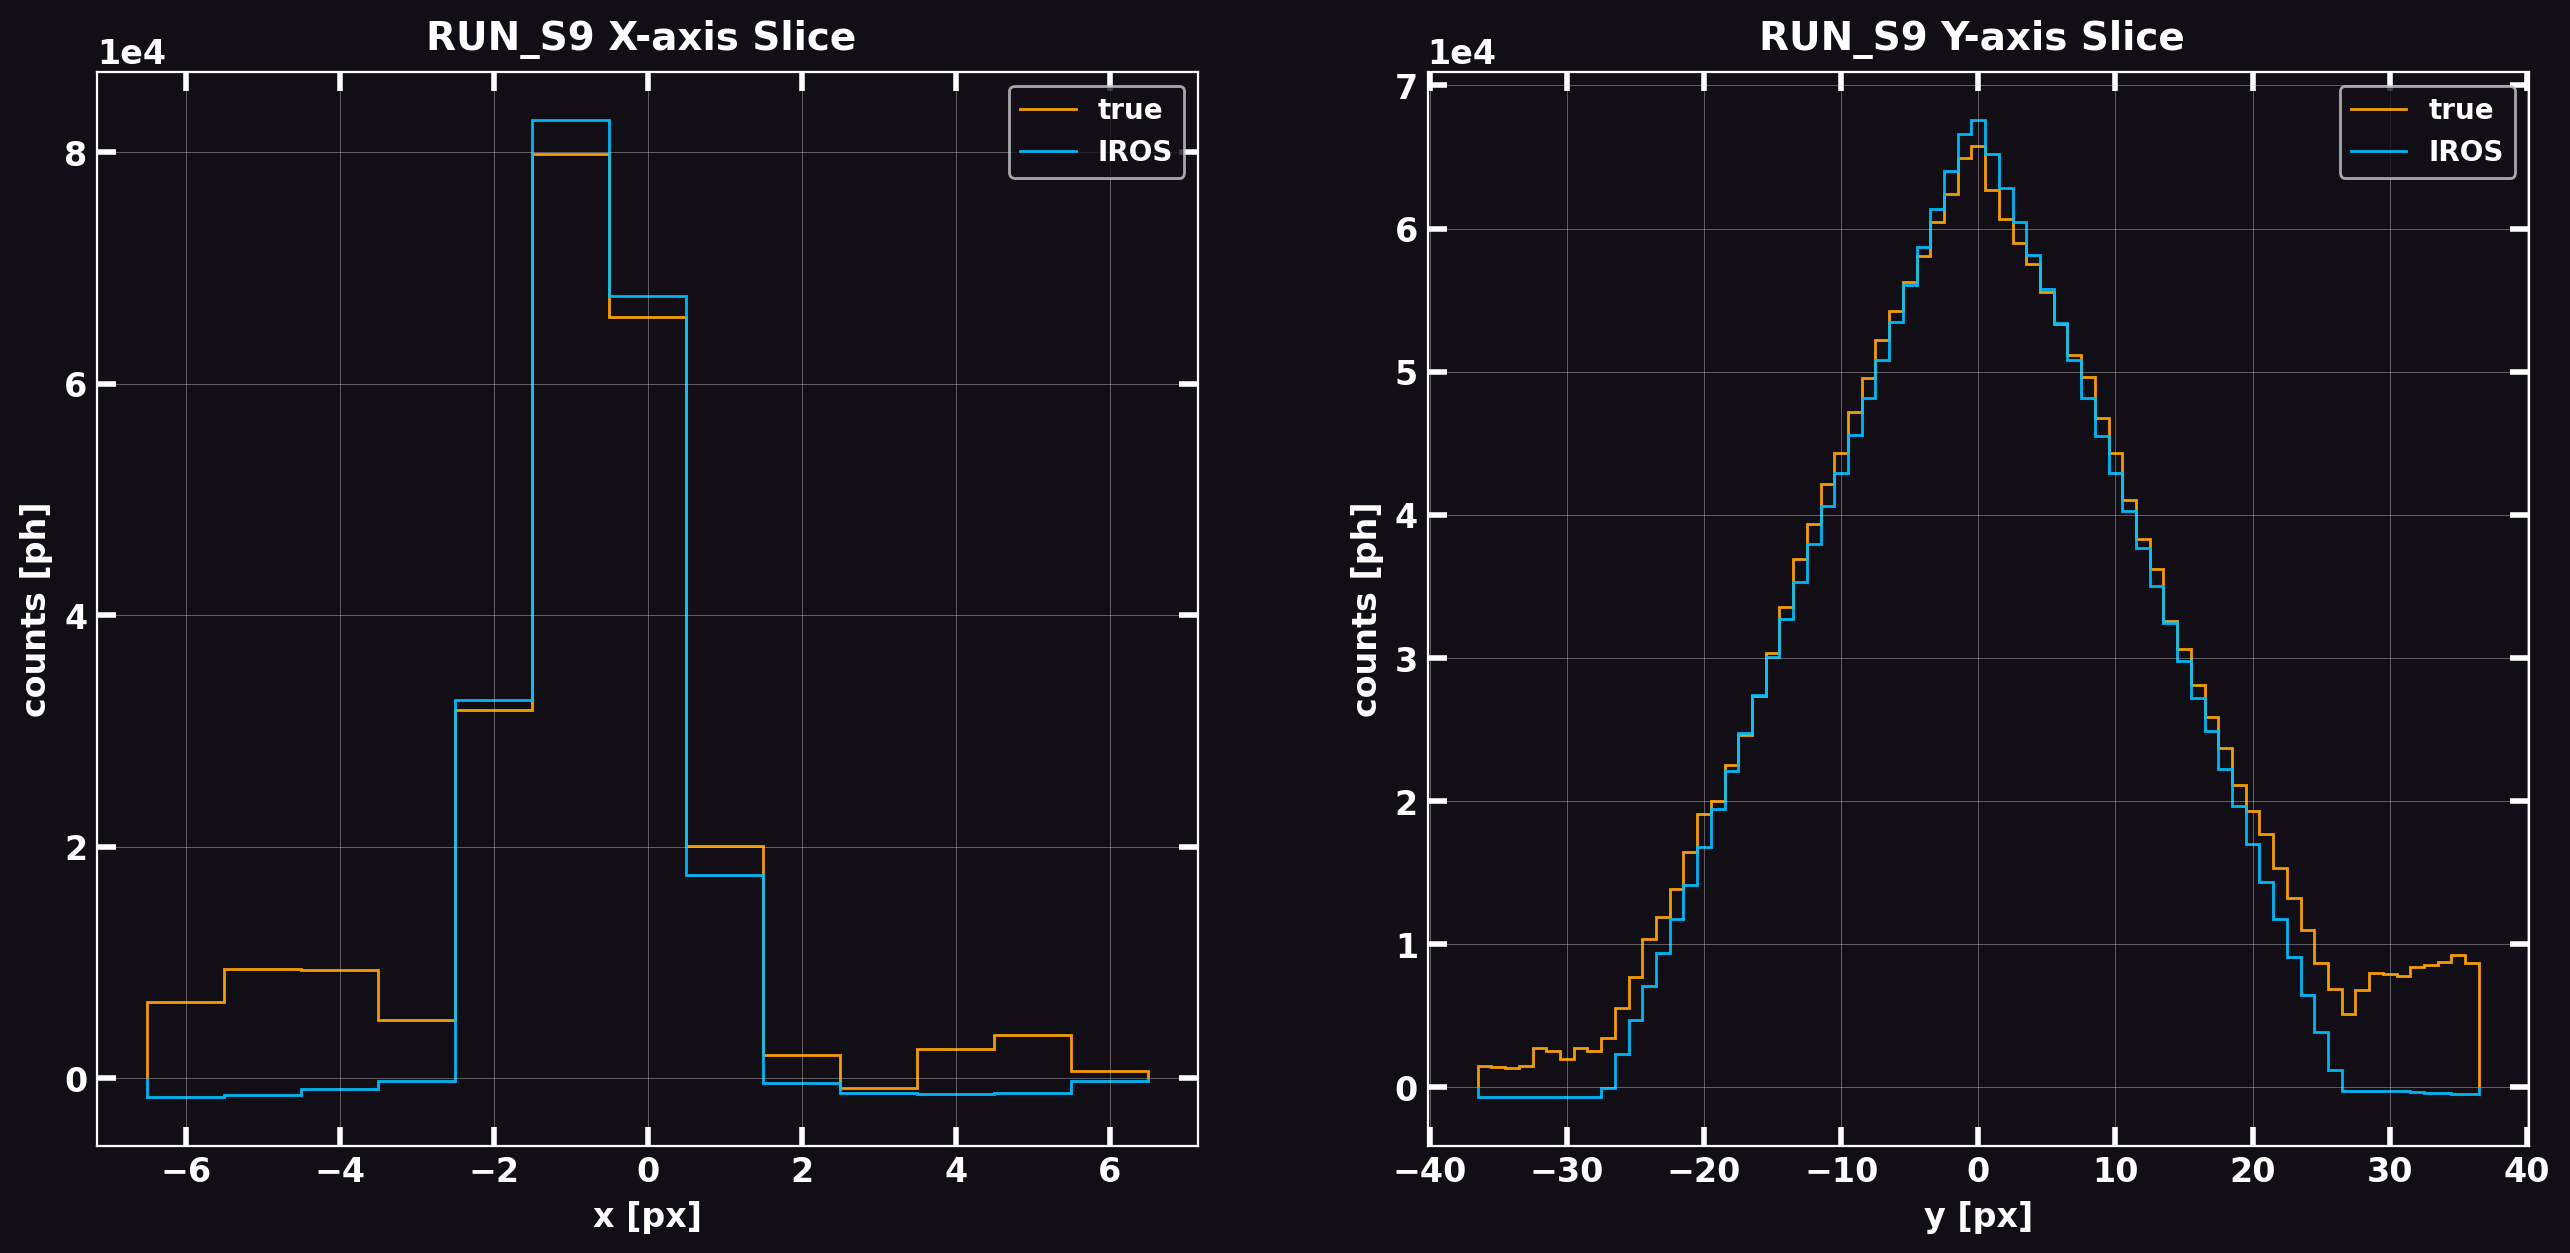

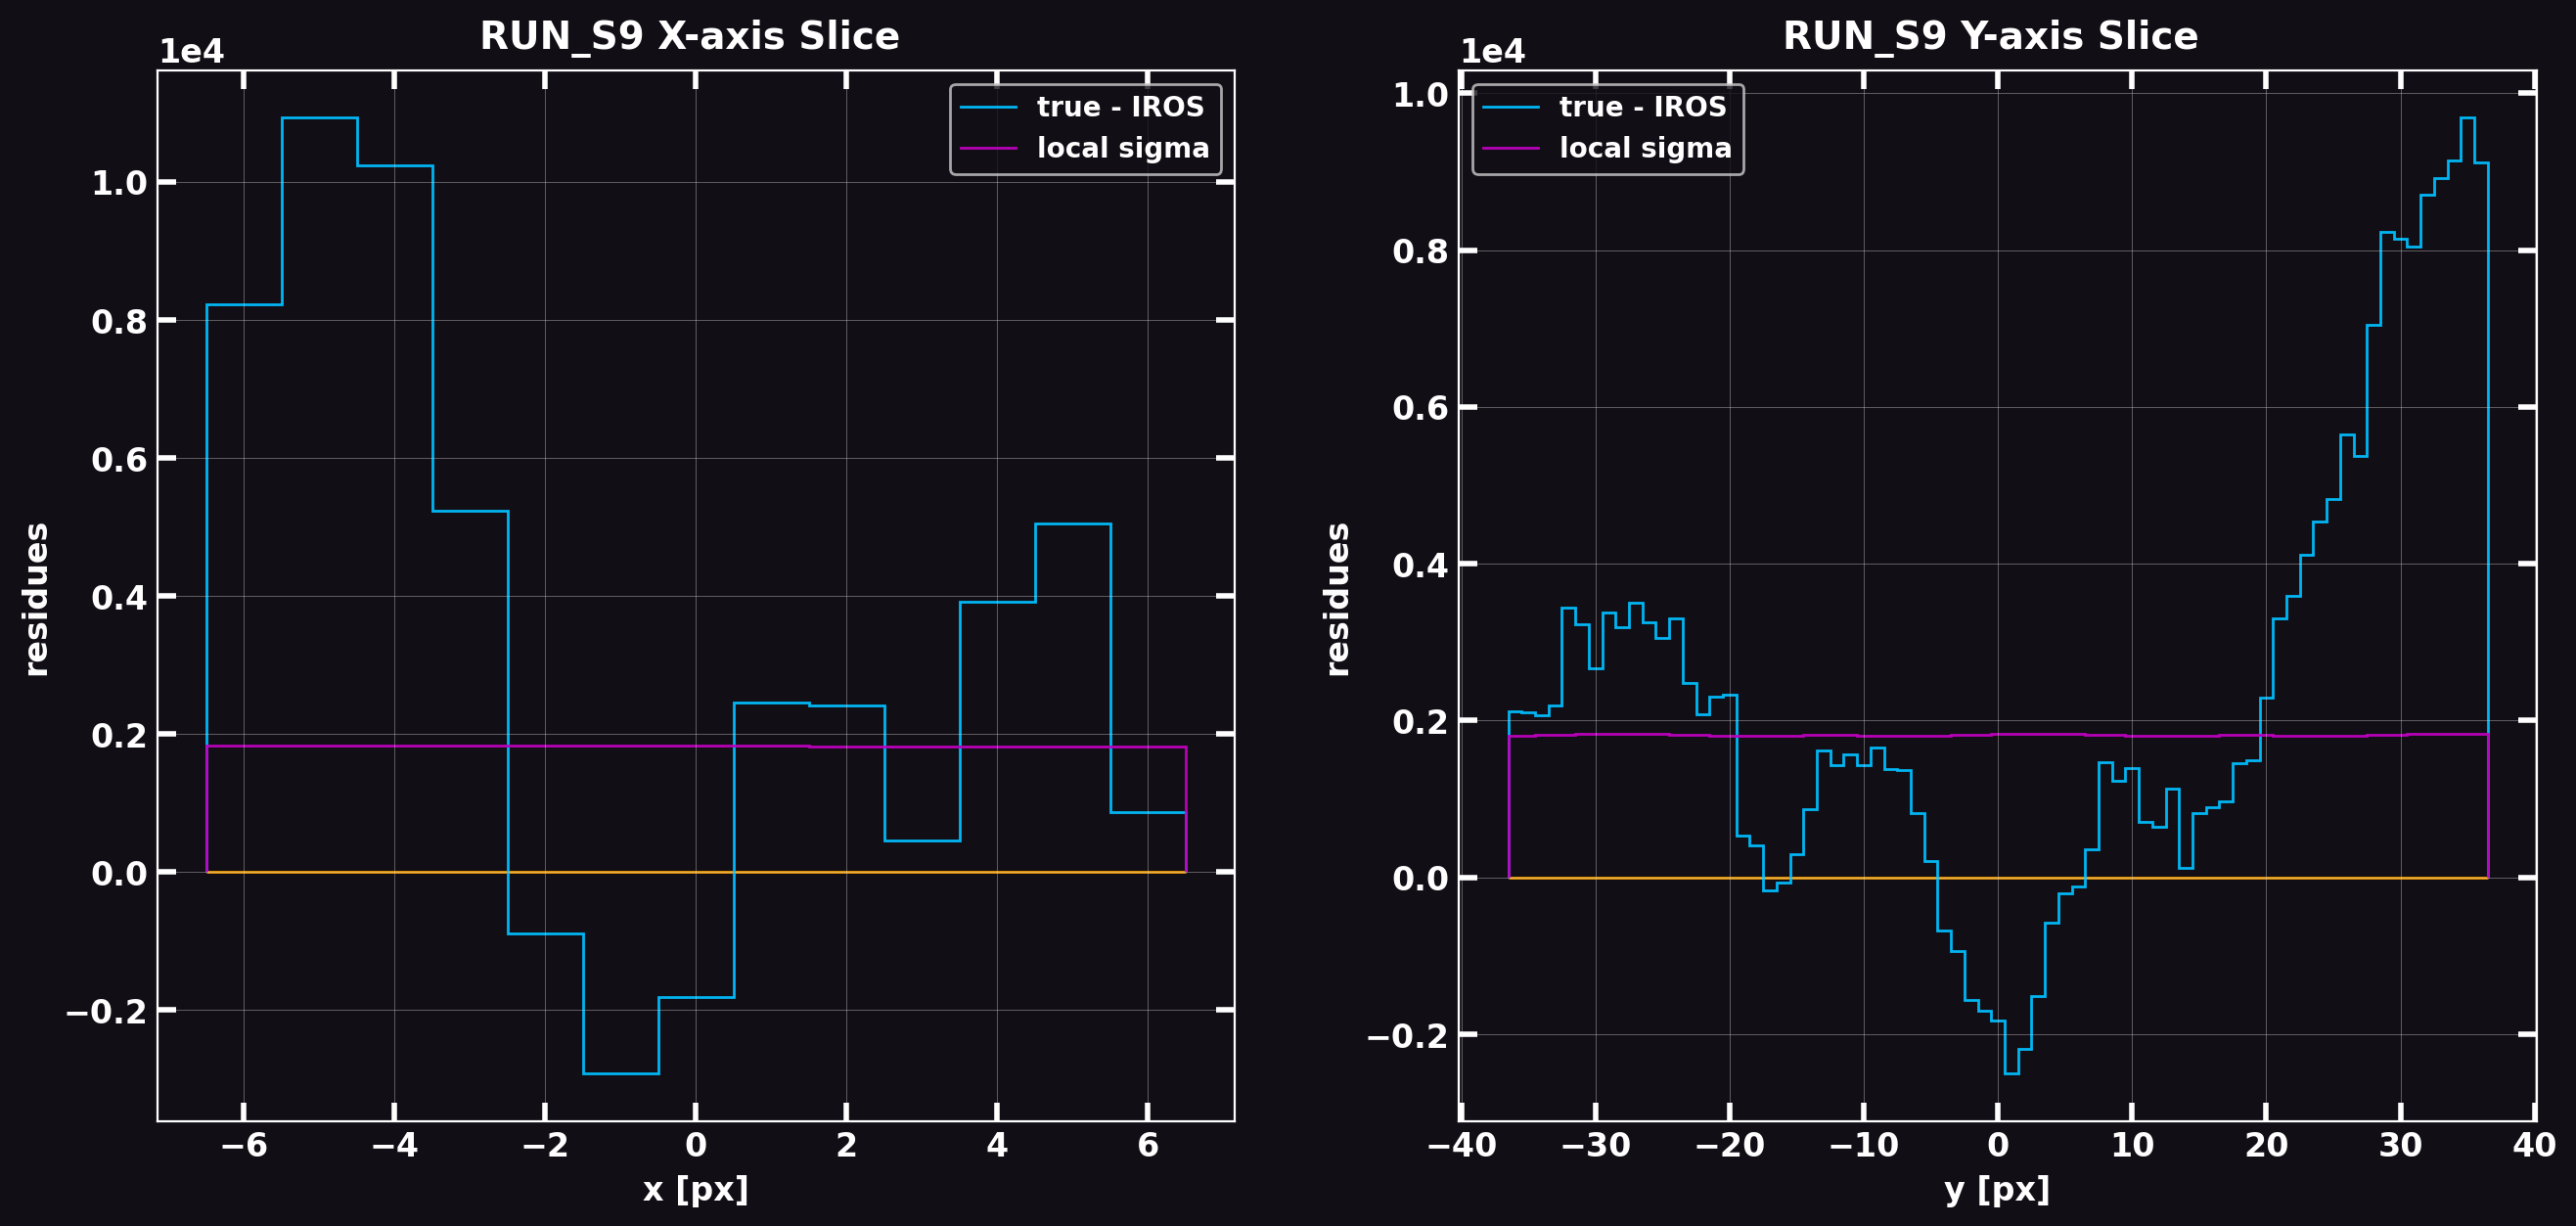

In [6]:
# WITHOUT SIGMA
from bloodmoon.mask import decode
from bloodmoon.mask import variance

true_sky: NDArray = decode(wfm, detector)
varmap: NDArray = variance(wfm, detector)

#save_to = '/home/edoardo/Desktop/ebands_IROS_run'
save_to = '/mnt/d/PhD_AASS/Coding/Images_fits/tests_results/reconstructed_noErrors'
plot_results(true_sky, candidates, wfm, varmap=varmap, save_to=None)

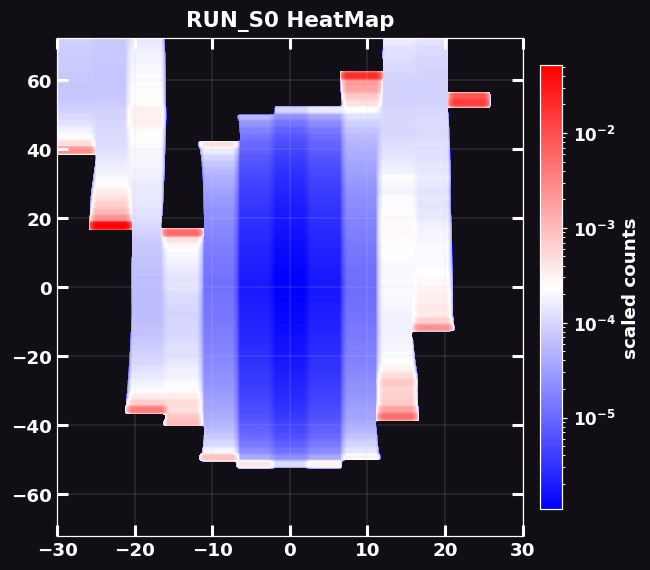

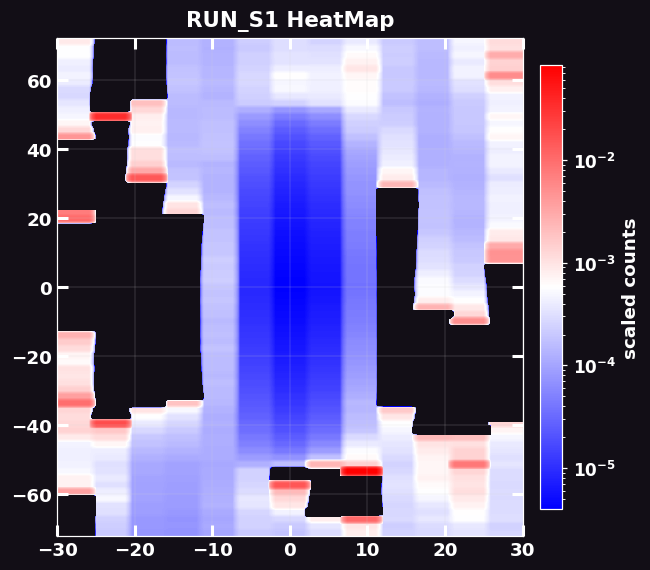

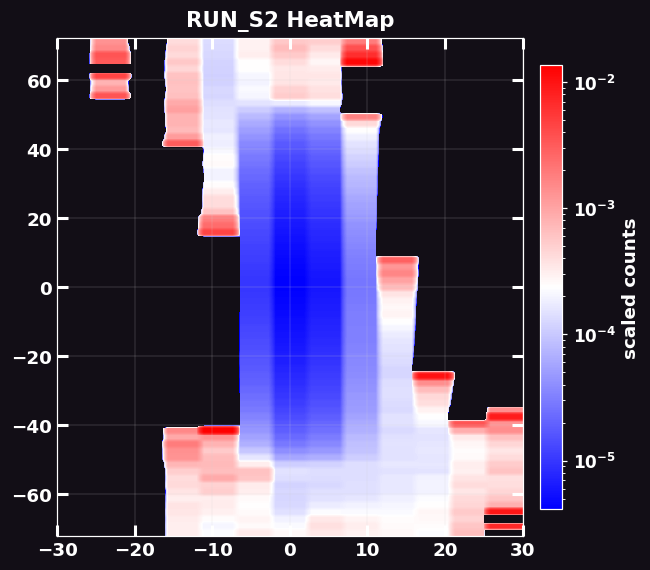

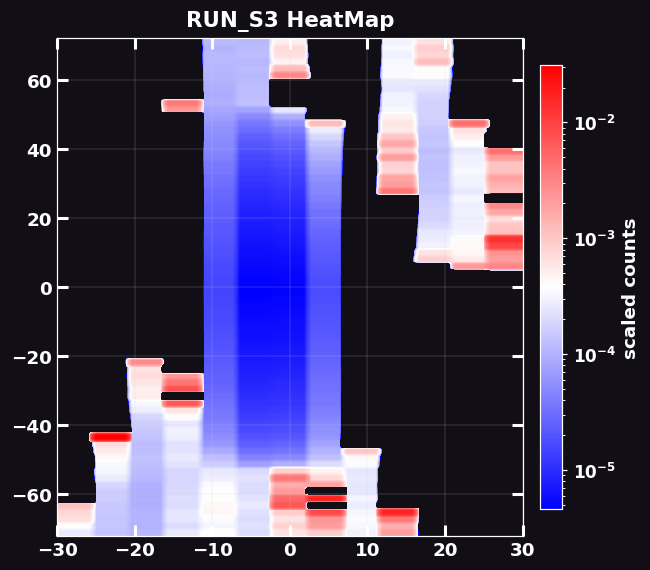

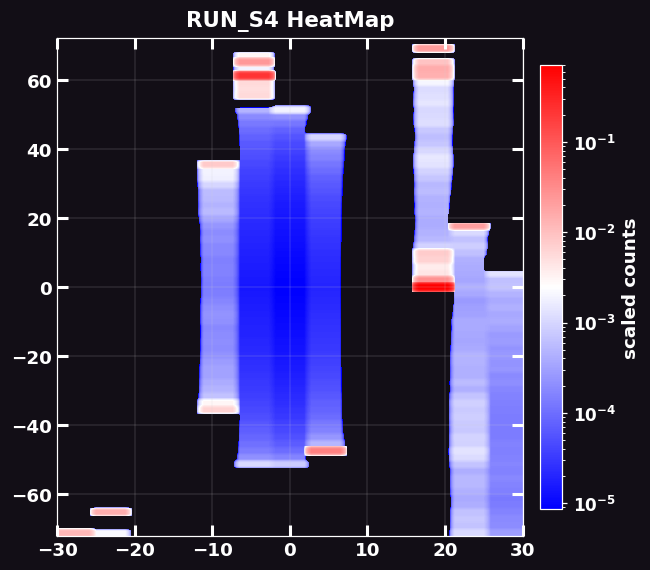

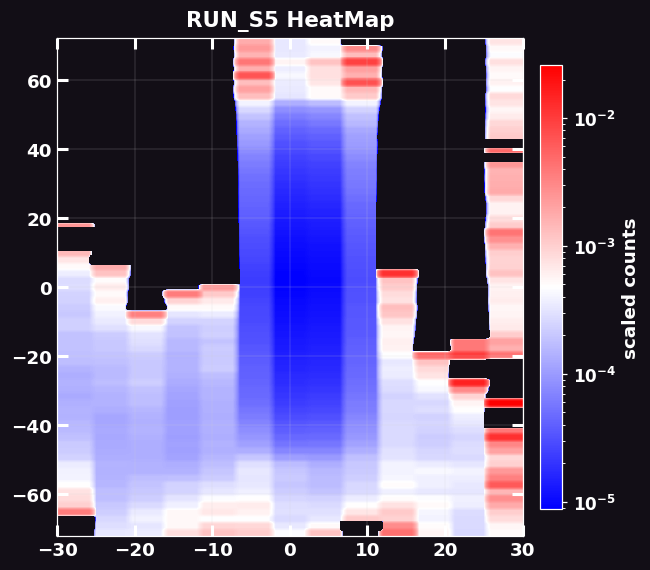

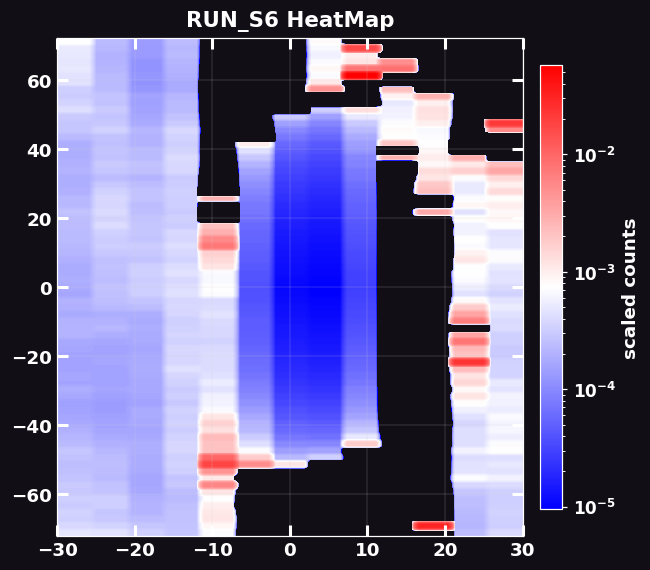

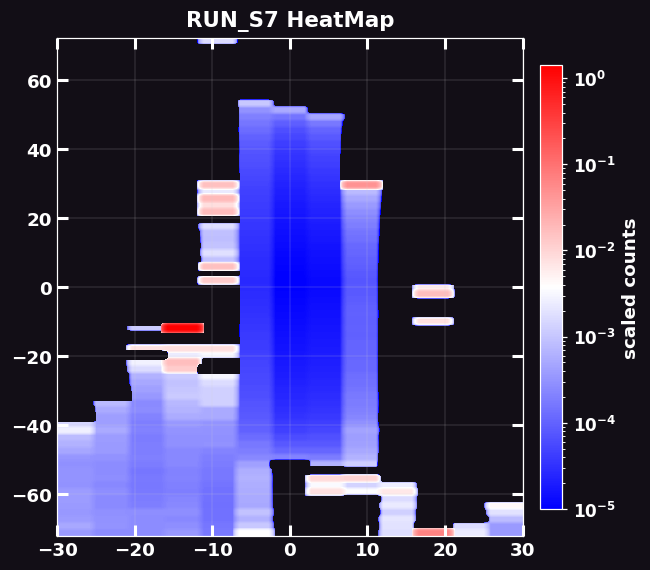

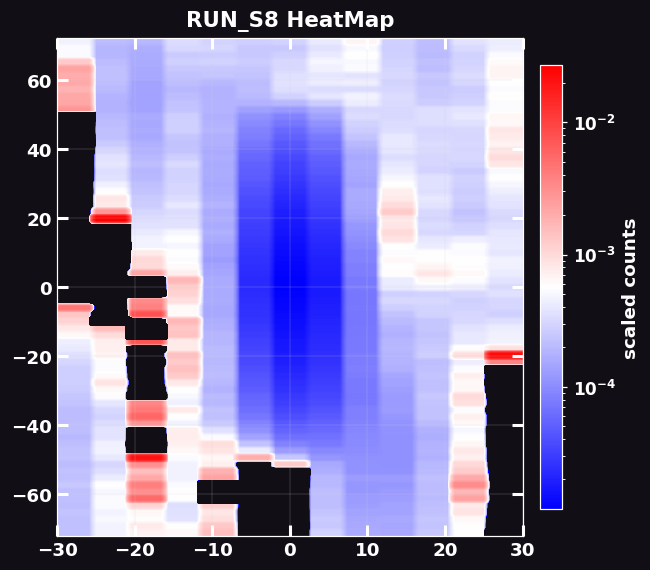

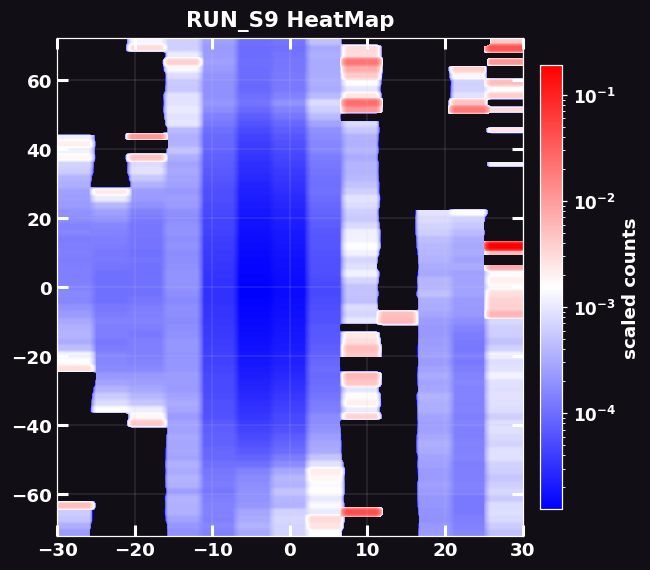

In [7]:
def rescale(arr: NDArray) -> NDArray:
    """Rescales array."""
    base = 1e3 * arr / arr.max()
    #mask = (base > 0)
    #arr_ = np.zeros_like(base)
    #arr_[mask] += np.log(base[mask])
    #arr_[~mask] -= np.log(np.abs(base[~mask]))
    return 1 / arr


def true_srcs_HM_insights(
    true_sky: NDArray,
    candidates: tuple[Source, ...],
    camera: CodedMaskCamera,
    save_to: str | Path | None = None,
) -> None:
    """
    Plots the heatmaps of the sources from the true sky BEFORE the IROS subtraction,
    to inspect for artefacts that may introduce biases in the optimisation procedure.
    """
    true_sky_ = true_sky.copy()
    for idx, cand in enumerate(candidates):
        pos: tuple[int, int] = shift2pos(camera, cand.shift_x, cand.shift_y)
        sourceID: str = f'run_s{idx}'

        F_UPY, F_UPX = 2, 5
        cropped = ds.crop(true_sky_, pos, PSF_CRP, strict=False)
        scaled = rescale(cropped)
        #vlim = np.max(np.abs(scaled))
        upsampled = ds.upscale(scaled, F_UPY, F_UPX) * np.prod((F_UPY, F_UPX))
        ds.image_plot(
            dmaps=ds.map4image(
                img=upsampled,
                title=f'{sourceID.upper()} HeatMap',
                cbarlabel='scaled counts',
                img_kwargs={
                    #'vmin': -vlim,
                    #'vmax': vlim,
                    'cmap': 'bwr',
                    'extent': (-PSF_CRP[1] * F_UPX, PSF_CRP[1] * F_UPX, -PSF_CRP[0] * F_UPY, PSF_CRP[0] * F_UPY),
                    'aspect': upsampled.shape[1] / upsampled.shape[0],
                    'interpolation': 'bilinear',
                    'norm': 'log',
                },
            ),
            save_to=(
                ds.savefile_to(save_to, f'{sourceID.upper()}_src_HM')
                if save_to is not None else None
            ),
        )
        modeled: NDArray = model_sky(
            camera, cand.shift_x, cand.shift_y, cand.cts, VIGNETTING, PSFY,
        )
        true_sky_ -= modeled

    return None


true_srcs_HM_insights(true_sky, candidates, wfm, save_to=None)

In [ ]:
from typing import Any
import warnings

from bloodmoon.coords import pos2shift
from bloodmoon.mask import snratio

from flexible_IROS_rec_procedure import OptResult, solver


def default_finder(
    camera: CodedMaskCamera,
    snr_threshold: float,
    batch: int = 1000,
) -> Callable[[NDArray, NDArray], tuple[int, int] | bool]:
    """
    Defines default IROS source candidates finder.
    """
    SETUP: dict[str, Any] = {
        'slit_mask_fine': int(
            camera.specs.slit_deltax * camera.upscale_f.x / camera.specs.mask_deltax
        ),
        'slit_mask_coarse': int(
            camera.specs.slit_deltay * camera.upscale_f.y / camera.specs.mask_deltay
        ),
        'skymap_mask': np.ones(camera.shape_sky, dtype=int),
    }

    def _update_skymap_mask(arg_sky: tuple[int, int]) -> None:
        """
        Updates the skymap mask with the new candidate position by covering the candidate
        half-PSF profile (to account for the camera angular resolution of a source).
        """
        rows = slice(
            arg_sky[0] - SETUP['slit_mask_coarse'] // 2, arg_sky[0] + SETUP['slit_mask_coarse'] // 2 + 1,
        )
        cols = slice(
            arg_sky[1] - SETUP['slit_mask_fine'] // 2, arg_sky[1] + SETUP['slit_mask_fine'] // 2 + 1,
        )
        SETUP['skymap_mask'][rows, cols] = 0
        return None
    
    def finder(
        sky: NDArray,
        snr: NDArray,
    ) -> tuple[int, int] | bool:
        """
        Returns the position of a valid IROS candidate inside the sky image.
        """
        reservoir = np.array(
            [np.unravel_index(id_, sky.shape) for id_ in np.argsort(sky, axis=None)[-batch:]]
        )
        for arg_sky in reservoir[::-1]:
            if (snr[*arg_sky] > snr_threshold) and SETUP['skymap_mask'][*arg_sky]:
                _update_skymap_mask(arg_sky)
                return tuple(arg_sky)
        return False
    
    return finder

In [ ]:
def default_optimiser(
    camera: CodedMaskCamera,
    vignetting: bool | Callable[[CodedMaskCamera, NDArray, float, float], NDArray],
    psfy: bool | Callable[[CodedMaskCamera, NDArray], NDArray],
    fit_weights: NDArray | Callable[[NDArray], NDArray] | None = None,
    camera_coding_power: float = 0.85,
) -> Callable[[NDArray, tuple[int, int], bool], OptResult]:
    """
    Configures the IROS optimiser for source parameters fitting.
    """
    def process_skyimg(
        sky: NDArray,
        pos: tuple[int, int],
    ) -> NDArray:
        """
        Processes the sky image for optimisation.
        """
        # here we crop the source PSF slit plus an offset to account for
        # shifts and to accomodate the `curve_fit` optimisation:
        #   - along y (coarse dir) we insert an offset of `5 * upscaling`, which
        #     is ~ 1/6 of the upsampled PSF slit dimension;
        #   - along x (fine dir) we insert an offset of `2 + upscaling`, to
        #     avoid the bkg contributes from the surrounding pixels;
        # NOTE: if the offset is smaller than at least the shifts bounds in
        # `optimize()`, the optimisation procedure may fail for some sources
        psf_slit_px_y, psf_slit_px_x = (
            int(camera.specs.slit_deltay * camera.upscale_f.y / camera.specs.mask_deltay),
            int(camera.specs.slit_deltax * camera.upscale_f.x / camera.specs.mask_deltax),
        )
        offset_y, offset_x = (
            5 * camera.upscale_f.y, 2 + camera.upscale_f.x,
        )

        i, j = pos
        crop_y, crop_x = (
            psf_slit_px_y + offset_y, psf_slit_px_x + offset_x,
        )
        slice_y, slice_x = (
            slice(i - crop_y, i + crop_y + 1), slice(j - crop_x, j + crop_x + 1),
        )
        cropped = sky[slice_y, slice_x]
        return cropped.flatten()

    def _ModelShiftFluence(
        arg_sky: tuple[int, int],
    ) -> Callable[[NDArray, float, float, float], NDArray]:
        """
        Initialises the source model.
        """
        def f(x: NDArray, shift_x: float, shift_y: float, fluence: float) -> NDArray:
            """Models the source sky image."""
            modeled = model_sky(camera, shift_x, shift_y, fluence, vignetting, psfy)
            return process_skyimg(camera, modeled, arg_sky)
        
        return f

    def optimiser(
        sky: NDArray,
        arg_sky: tuple[int, int],
        verbose: bool = False,
    ) -> OptResult:
        """
        Performs the optimization to fit a point source model to sky image data.
        """
        model_func = _ModelShiftFluence(arg_sky)
        sky_peak = sky[*arg_sky]

        # setup solver params
        # * setup source data + std
        sky_ydata = process_skyimg(camera, sky, arg_sky)
        if fit_weights is not None:
            weights = (
                fit_weights if isinstance(fit_weights, np.ndarray)
                else fit_weights(sky_ydata)
            )
        else:
            weights = np.ones_like(sky_ydata)
        # * extract source coords and counts starting values
        sx_start, sy_start = pos2shift(camera, *arg_sky)
        cts_start = sky_peak / camera_coding_power
        start_params_vals = np.array([sx_start, sy_start, cts_start])
        # * setup fit params boundaries
        #    - the shifts are allowed to fluctuate in a small pixel box since
        #      the extracted position is close enough to the true source pos
        #      A small box also account for superimposed or close sources,
        #      which may introduce biases in the source fit procedure
        #    - the box is built from the digital upsampling since in the worst
        #      case (source at 45 deg wrt optical axis) the high energy detected
        #      photons median absorption distance is 225um. The projection of this
        #      distance on the camera plane is always smaller than `px_size / ups`  
        #    - the fluence cannot be smaller than the one observed at the peak,
        #      and we insert a lower value just for precaution (if simulating
        #      for example an infinite detector spatial resolution)
        px_dim_x, px_dim_y = (
            camera.specs.mask_deltax / camera.upscale_f.x,
            camera.specs.mask_deltay / camera.upscale_f.y,
        )
        bounds = [
            (
                max(sx_start - camera.upscale_f.x * px_dim_x, camera.bins_sky.x[0]),
                max(sy_start - camera.upscale_f.y * px_dim_y, camera.bins_sky.y[0]),
                0.95 * sky_peak,
            ),
            (
                min(sx_start + camera.upscale_f.x * px_dim_x, camera.bins_sky.x[-1]),
                min(sy_start + camera.upscale_f.y * px_dim_y, camera.bins_sky.y[-1]),
                1.25 * sky_peak,
            ),
        ]
        # perform optimisation
        slvr_kwargs = {
            # - solver kwargs
            'p0': start_params_vals,
            'sigma': weights,
            'bounds': bounds,
            'method': 'trf',
            # - least square kwargs
            'jac': '3-point',
            'ftol': 1e-8,
            'xtol': 1e-8,
            'x_scale': 'jac',
            'loss': 'linear',
        }
        result = solver(
            func=model_func,
            xdata=np.arange(len(sky_ydata)),
            ydata=sky_ydata,
            verbose=verbose,
            **slvr_kwargs,
        )

        return result
    
    return optimiser


def default_fitter(
    camera: CodedMaskCamera,
    vignetting: bool | Callable[[CodedMaskCamera, NDArray, float, float], NDArray],
    psfy: bool | Callable[[CodedMaskCamera, NDArray], NDArray],
    fit_weights: NDArray | Callable[[NDArray], NDArray] | None,
) -> Callable[[tuple[int, int], NDArray, NDArray], Source]:
    """
    Defines default IROS source candidates parameters fitter.
    """
    optimiser = default_optimiser(camera, vignetting, psfy, fit_weights)

    def fitter(
        arg_sky: tuple[int, int],
        sky: NDArray,
        snr: NDArray,
    ) -> Source:
        """Performs the optimisation of the source candidate params."""
        try:
            params: OptResult = optimiser(
                sky=sky,
                arg_sky=arg_sky,
                verbose=True,
            )
        except Exception as e:
            raise RuntimeError(f"Optimization failed: {str(e)}") from e
        
        significance = float(snr[*arg_sky])
        return Source(*params.params, significance)
    
    return fitter

In [10]:
def default_subtractor(
    camera: CodedMaskCamera,
    vignetting: bool | Callable[[CodedMaskCamera, NDArray, float, float], NDArray],
    psfy: bool | Callable[[CodedMaskCamera, NDArray], NDArray],
) -> Callable[[Source, NDArray], NDArray]:
    """
    Defines default IROS source shadowgram subtractor.
    """
    def subtractor(
        candidate: Source,
        detector: NDArray,
    ) -> NDArray:
        """Subtracts candidate from detector image."""
        sg_model: NDArray = model_shadowgram(
            camera=camera,
            shift_x=candidate.shift_x,
            shift_y=candidate.shift_y,
            vignetting=vignetting,
            psfy=psfy,
        )
        residual = detector - candidate.cts * sg_model
        return residual
    
    return subtractor

In [11]:
def iros_singleCAM(
    detector: NDArray,
    camera: CodedMaskCamera,
    max_iterations: int,
    snr_threshold: float = 5.0,
    vignetting: bool | Callable[[CodedMaskCamera, NDArray, float, float], NDArray] = True,
    psfy: bool | Callable[[CodedMaskCamera, NDArray], NDArray] = True,
    fit_weights: NDArray | Callable[[NDArray], NDArray] | None = None,
    finder: Callable[[NDArray, NDArray], tuple[int, int] | bool] | None = None,
    fitter: Callable[[tuple[int, int], NDArray, NDArray], Source] | None = None,
    subtractor: Callable[[Source, NDArray], NDArray] | None = None,
    varmap: NDArray | None = None,
) -> Iterable[tuple[Source, NDArray]]:
    """
    Performs the Iterative Removal of Sources (IROS) algorithm for a single coded-mask
    camera of the Wide Field Monitor observations.
    """
    # intern logic setup
    find_candidate = (
        finder if finder is not None
        else default_finder(camera, snr_threshold)
    )
    fit_cand_params = (
        fitter if fitter is not None
        else default_fitter(camera, vignetting, psfy, fit_weights)
    )
    subtract_cand_sg = (
        subtractor if subtractor is not None
        else default_subtractor(camera, vignetting, psfy)
    )
    # arrs setup
    detector_ = detector.copy()
    skymap = decode(camera, detector)
    varmap = (
        varmap if varmap is not None else variance(camera, detector)
    )
    # looping as there's no tomorrow
    for i in range(max_iterations):
        snrmap = snratio(skymap, varmap)
        candidate_pos = find_candidate(skymap, snrmap)

        if not candidate_pos:
            print("\nNo candidates left...")
            break
        try:
            source = fit_cand_params(candidate_pos, skymap, snrmap)
        except RuntimeError as e:
            warnings.warn(f"Optimizer failed at iteration {i}:\n\n{e}")
            continue

        detector_ = subtract_cand_sg(source, detector_)
        skymap = decode(camera, detector_)
        yield (source, skymap)